<div style="background-color:#E8F0FE; border-left:6px solid #1A73E8; border-radius:4px; padding:20px 15px 5px 30px; margin:8px 10px 8px 0; color:#1F3A5F; box-sizing:border-box; max-width:calc(100% - 10px); overflow-wrap:anywhere; white-space:normal;">

#### 판정: ⚠️ 조건부

이번 수정만 반영하면 완료 처리해도 될 것 같습니다.

다음중 한 가지 경우를 선택하여 진행하면 됩니다.

1. jupyter 상태로 포트폴리오를 마무리 하는 경우 : 이 노트북의 첨삭 내용을 수정한 후 최종본을 보내주세요.
2. ppt 형태로 포트폴리오를 업그래이드 하는 경우 : 이 노트북의 첨삭 내용을 반영하여 ppt 초안을 작업해 보내주세요.

</div>

# 구매 패턴 기반 고객 페르소나 도출 후 채널 오분류 고객 마케팅 전략

**작성자:** 김정우, 안재원 &nbsp;&nbsp;|&nbsp;&nbsp; **작성일:** 2026-10-02

## 분석 개요

**분석 주제**

> 도매업체 고객의 품목별 구매 데이터를 활용하여 고객 유형을 군집화하고, 채널분류모형을 구축하여 페르소나별 채널 확인 후 채널 오분류 고객에 대한 마케팅 제안

**분석 질문**
  - 1단계(군집) : 이 도매업체 고객은 몇 종류인가?
  - 2단계(분류) : 채널 정보 없이도 구분할 수 있는가?
  - 3단계(연결) : 각 페르소나가 어느 채널에 몰려있는지 확인 후,  오분류의 고객에 대한 마케팅 제안

**종속변수:** `Channel` (명목형, 고객채널 / 1:Horeca, 2:Retail)

# **Wholesale customers 분석 파이프라인**

## #0. 라이브러리 불러오기

In [1]:
from helper import *
import pandas as pd
import numpy as np
from IPython.display import Markdown, display

## #1. 데이터 품질 점검 및 데이터 전처리

### **1)** 데이터 구조 점검 <br>
#### **1-1** 데이터 불러오기 & 크기확인

In [2]:
# 데이터 불러오기
origin = pd.read_csv(r'./Wholesale customers data.csv', encoding='utf-8')
display(origin.head())

# 데이터 크기 확인
print('데이터 크기 : ', origin.shape)

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


데이터 크기 :  (440, 8)


#### **1-2** 데이터타입 점검

In [3]:
origin.info()

<class 'pandas.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


#### 출처와 분석 단위
- 출처 : `Cardoso, M. (2013) Wholesale customers` Kaggle 재배포용
- 데이터 크기 : 440 행 x 8 열
- 분석 단위 : 1행 = 고객 1명 (도매업체 거래처)

#### 변수 정의

|변수명| 의미 | 역할 | 척도 | 단위 | Y와 관련 있다고 보는 이유 |
|---|---|---|---|---|---|
| `Channel` | 고객 채널 | 종속변수 | 명목형 (2집단) | 1 : Horeca(호텔/레스토랑/카페), 2 : Retail(소매유통) | - |
| `Region` | 고객 지역 | 독립변수 | 명목형 (3집단) | 1: Lisbon, 2 : Oporto, 3 : Other | - |
| `Fresh` | 신선식품 연간 구매액 | 독립변수 | 연속형 | monetary unit| 신선도 유지 및 요리를 이유로, <br>Retail 보다는 Horeca에서 더 많이 쓰임 |
| `Milk` | 유제품 연간 구매액 | 독립변수 | 연속형 |monetary unit | Horeca와 Retail 양측 다 많이 쓰임|
| `Grocery` | 식료품 연간 구매액 | 독립변수 | 연속형 |monetary unit | Horeca에서는 필요한 양만 구매하므로, <br>Retail 에서 더 많이 쓰임 |
| `Frozen` | 냉동식품 연간 구매액 | 독립변수 | 연속형 |monetary unit | 조리 원재료로 대량 비축하므로, <br>Retail 보다는 Horeca에서 더 많이 쓰일 것으로 예상 |
| `Detergents_Paper` | 세제 및 종이류 연간 구매액 | 독립변수 | 연속형 |monetary unit | Horeca에서 소비가 있긴 하지만, <br> Retail은 판매 상품으로 더 많이 쓰임 |
| `Delicassen` | 즉석/가공식품 연간 구매액 |독립변수 |  연속형 |monetary unit | Horeca보다 Retail에서 더 많이 쓰임 |


#### 초기 가설
- 1단계(군집) : 이 도매업체 고객은 몇 종류인가?
    - 가설1. 품목별 구매 비중에 따라 고객은 최소 2개 이상의 뚜렷한 소비 패턴 그룹으로 나뉠 것이다.
    - 가설2. Horeca 고객은 `Fresh`,`Frozen` 구매 비중이 높고, Retail 고객은 `Grocery`,`Milk`,`Detergents_Paper` 비중이 높을 것이다.
- 2단계(분류) : 채널 정보 없이도 구분할 수 있는가?
    - 가설3. 분류 모델의 오차는 무작위로 분포하지 않고, 특정 소비 패턴에 집중적으로 나타날 것이다.
- 3단계(연결) : 각 페르소나가 어느 채널에 몰려있는지 확인 후,  오분류의 고객에 대한 마케팅 제안
    - 가설4. 오분류 고객은 단순한 모델 오차가 아니라, 실제로 채널과 다른 소비 패턴을 보이는 "채널 전이/혼합형" 고객일 것이다.
    - 가설5. 오분류 고객군은 평균 구매액이 정분류 고객군과 유의하게 다를 것이다.

#### 데이터의 한계
- 수집 기간 불명 : 구매액이 특정 연도의 구매액인지 알 수 없다.(계절성 및 트렌드 반영 불가)
- 화폐 단위 불명확 : 실제 통화값인지 정규화 지수인지 명시되지 않아 카테고리 간 상대적 비중 위주로 해석해야 한다.
> **따라서 본 분석은 "실제 마케팅 의사결정에 바로 적용 가능한 결과"가 아니라, '구매 패턴으로 채널 오분류 고객을 식별하고 대응 전략을 설계하는 방법론'을 검증하기 위한 사례로 설계**한다.

#### **1-3** 데이터 타입 변환
- `Channel`, `Region` 컬럼은 정수형(`int64`)으로 읽혔으나, 1·2·3은 크기가 아니라 이름표이므로 명목형으로 변환
- `Channel` : 1 = **Horeca**, 2 = **Retail**
- `Region` : 1 = **Lisbon**, 2 = **Oporto**, 3 = **Other Region**

In [4]:
df = my_qtcheck.set_type(origin, as_category=['Channel', 'Region'])

<class 'pandas.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   Channel           440 non-null    category
 1   Region            440 non-null    category
 2   Fresh             440 non-null    int64   
 3   Milk              440 non-null    int64   
 4   Grocery           440 non-null    int64   
 5   Frozen            440 non-null    int64   
 6   Detergents_Paper  440 non-null    int64   
 7   Delicassen        440 non-null    int64   
dtypes: category(2), int64(6)
memory usage: 21.7 KB


#### **1-4** 데이터 중복 확인
- 중복된 행의 수는 0건

In [5]:
my_qtcheck.check_duplicates(df)

중복된 행의 수: 0


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185
...,...,...,...,...,...,...,...,...
435,1,3,29703,12051,16027,13135,182,2204
436,1,3,39228,1431,764,4510,93,2346
437,2,3,14531,15488,30243,437,14841,1867
438,1,3,10290,1981,2232,1038,168,2125


#### 1-5 형식, 표기, 단위, 점검 (1) - 연속형 변수

In [6]:
# 연속형 변수 목록 리스트 정의
num_cols = my_qtcheck.get_number_column_names(df)

minmax = []     # 최소값, 최대값을 저장할 리스트

for i in num_cols:          # 연속형 변수 반복문
    min_value= df[i].min()  # 최소값
    max_value = df[i].max() # 최대값
    # 반복문에 대한 최소값, 최대값 리스트 추가
    minmax.append({'min' : min_value, 'max' : max_value})   
    
# 최소값과 최대값을 데이터프레임으로 출력
minmax_df = pd.DataFrame(minmax, index=num_cols)
minmax_df

,min,max
Fresh,3,112151
Milk,55,73498
Grocery,3,92780
Frozen,25,60869
Detergents_Paper,3,40827
Delicassen,3,47943


In [7]:
# 절단의심(min = 3) 주변 값 확인
for i in num_cols:
    print('연속형 변수 : ', i)
    min_df = df[[i]].sort_values(i)
    display(pd.DataFrame(min_df.head()))

연속형 변수 :  Fresh


,Fresh
338,3
95,3
66,9
218,18
96,23


연속형 변수 :  Milk


,Milk
154,55
98,112
356,134
122,201
97,254


연속형 변수 :  Grocery


...

,Frozen
420,25
38,33
65,36
57,38
145,42


연속형 변수 :  Detergents_Paper


,Detergents_Paper
75,3
161,3
204,5
154,7
356,9


연속형 변수 :  Delicassen


,Delicassen
128,3
142,3
109,3
187,3
233,7


#### 1-6 형식, 표기, 단위, 점검 (2) - 명목형 변수

In [8]:
# 명목형 변수 컬럼 리스트 목록
cat_cols = my_qtcheck.get_categorical_column_names(df)

# 명목형 변수에 대한 반복문
for c in cat_cols:
    count = df[c].value_counts()    # 명목형 컬럼 카운트
    percent = round(df[c].value_counts(normalize=True) * 100, 2)   # 명목형 컬럼 비율
    # display(count)                  # 카운트 출력결과
    # display(percent)                # 비율 출력결과
    table = pd.DataFrame({'개수': count, '비율': percent})   # 카운트와 비율을 데이터프레임으로 합치기
    display(table)

,개수,비율
Channel,,
1,298,67.73
2,142,32.27


,개수,비율
Region,,
3,316,71.82
1,77,17.50
2,47,10.68


#### 🔍해석

- **자료형:** <br>
  - 명목형 : `Channel`, `Region` <br>
  - 연속형 : `Fresh`, `Milk`, `Grocery`, `Frozen` , `Detergents_Paper`, `Delicassen`
- **중복 행:** 
  - **0건** 이므로, 삭제 대상이 없다.
- **형식, 표기, 단위, 점검**
  - 연속형 : 연속형 변수 중, 4개의 최소값이 3인 것으로 확인된다.<br>
  그리고, 연속형 변수의 최소값 3의 주변값은 다음과 같다.<br>
  `Fresh` : 9, `Grocery` : 137, `Detergents_Paper` : 5, `Delicassen` : 7
    - `Detergents_Paper`는 3을 제외한 최소값이 5이므로, 3이라는 값이 실재하는 값임을 추측할 수 있지만, <br> 4개의 변수가 동일하게 최소값이 3인 것을 생각하면, 하한 절단값으로 3을 사용한 것이라면 하한 왜곡이 발생할 수 있다는 것을 인지해야 한다.
    - 값이 3인 행의 개수 : `Fresh` 2개, `Grocery` 1개, `Detergents_Paper` 2개, `Delicassen` 4개
  - 명목형 : 표기 오류 및 중복값은 없다.

### **2)** 데이터 품질 점검

#### **2-1** 데이터 결측치 확인
- 데이터 결측치 0건

In [9]:
my_qtcheck.check_missing_values(df)

,Missing Count,Missing Ratio (%)
Channel,0,0.0
Region,0,0.0
Fresh,0,0.0
Milk,0,0.0
Grocery,0,0.0
Frozen,0,0.0
Detergents_Paper,0,0.0
Delicassen,0,0.0


#### 2-2 품질 점검 데이터셋 저장

In [10]:
df.to_excel('Wholesale customers_qtcheck.xlsx', index=False)

#### 2-3 IQR 기준 이상치 확인

In [11]:
num_desc = my_qtcheck.numerical_summary(df,
                                               save_path='Wholesale customers_numerical_summary.xlsx')
num_desc.T

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.0,440.0,440.0,440.0,440.0,440.0
mean,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,3.0,55.0,3.0,25.0,3.0,3.0
25%,3127.75,1533.0,2153.0,742.25,256.75,408.25
50%,8504.0,3627.0,4755.5,1526.0,816.5,965.5
75%,16933.75,7190.25,10655.75,3554.25,3922.0,1820.25
max,112151.0,73498.0,92780.0,60869.0,40827.0,47943.0
rel_diff,0.411136,0.598088,0.672017,1.013061,2.529079,0.579358
rdiff_flag,diff,large_diff,large_diff,large_diff,large_diff,large_diff


In [12]:
# 상한 이상치 기준값 정의
print('상한 이상치 기준 값')
display(pd.DataFrame(num_desc.loc[:, 'upper_bound']))

# 상한 이상치가 포함된 모든 행을 출력(중복 제외)
upper_bound = num_desc.loc[num_cols, 'upper_bound'].astype(float)
outlier_df = df[(df[num_cols] > upper_bound).any(axis=1)]
print('상한 이상치가 포함된 행의 수:', outlier_df.shape[0], '행')
print('상한 이상치가 포함된 행의 비율:', round(outlier_df.shape[0] / df.shape[0] * 100, 2), '%')

상한 이상치 기준 값


,upper_bound
Fresh,37642.750
Milk,15676.125
Grocery,23409.875
Frozen,7772.250
Detergents_Paper,9419.875
Delicassen,3938.250


상한 이상치가 포함된 행의 수: 108 행
상한 이상치가 포함된 행의 비율: 24.55 %


In [13]:
# 상한 이상치 채널별 분류
Channel_count = outlier_df['Channel'].value_counts()
display(Channel_count)


Channel
1    61
2    47
Name: count, dtype: int64

#### 🔍해석

- **결측치**
  - 결측치 0건으로 삭제행 없음.
- **이상치**
  - IQR 기준 이상치 108행(약 24.6%)이 발견되었으나, 다음 **3) 기술통계량** 해석에서 처리 방법을 명시한다.

### 3) 기술 통계량
#### 3-1 연속형 변수의 기술 통계량

In [14]:
num_desc.T

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.0,440.0,440.0,440.0,440.0,440.0
mean,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,3.0,55.0,3.0,25.0,3.0,3.0
25%,3127.75,1533.0,2153.0,742.25,256.75,408.25
50%,8504.0,3627.0,4755.5,1526.0,816.5,965.5
75%,16933.75,7190.25,10655.75,3554.25,3922.0,1820.25
max,112151.0,73498.0,92780.0,60869.0,40827.0,47943.0
rel_diff,0.411136,0.598088,0.672017,1.013061,2.529079,0.579358
rdiff_flag,diff,large_diff,large_diff,large_diff,large_diff,large_diff


#### 3-2 범주형 변수의 기술 통계량

In [15]:
cat_desc = my_qtcheck.categorical_summary(df)
cat_desc

📊 컬럼 'Channel'의 value_counts():


,count
Channel,
1,298
2,142


📊 컬럼 'Region'의 value_counts():


,count
Region,
1,77
2,47
3,316


,Channel,Region
count,440,440
unique,2,3
top,1,3
freq,298,316


#### 3-3 불필요한 컬럼 삭제 후, 저장

> `Region` (지역 - Lisbon:1, Oporto:2, Other:3) 고객 분포는 **Other 316명(약 71.8%)**, **Lisbon 77명(약 17.5%)**, **Oporto 47명(약 10.7%)** 이다. 아래 카이제곱 독립성 검정에서 `Channel`과 연관이 있다고 볼 근거가 없어(p = 0.114) 분석 대상에서 제거한다.

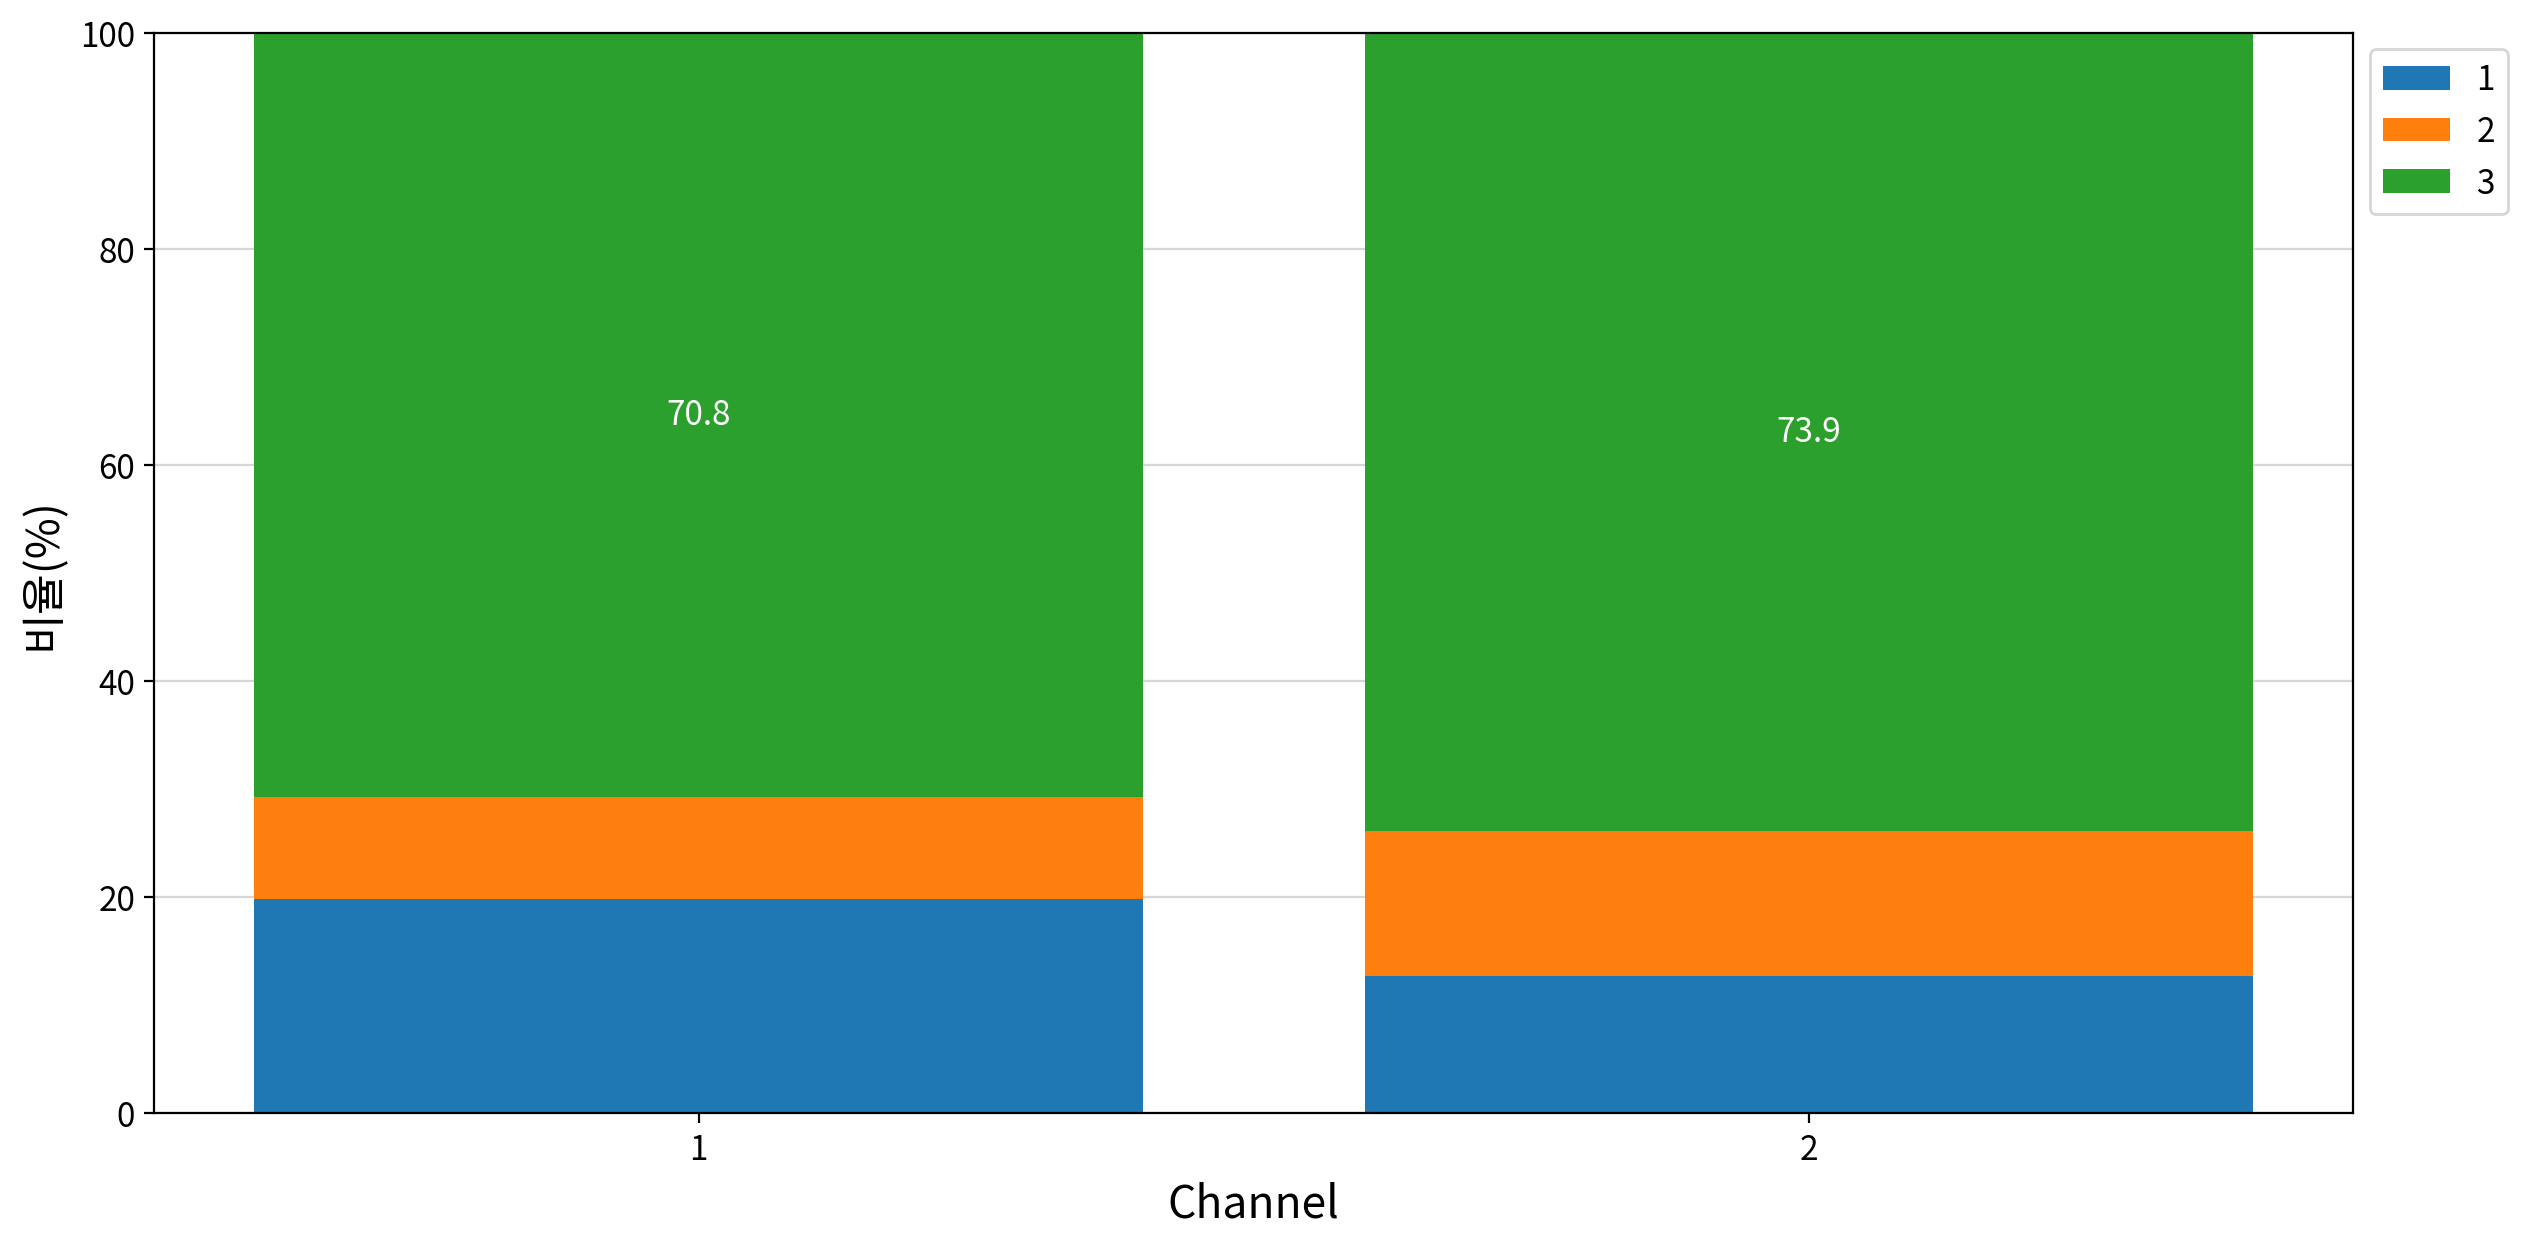

,,test,chi2,dof,p-value,significant,effect(V),strength,min_expected,assumption
row,col,,,,,,,,,
Channel,Region,Chi-square test of independence,4.3491,2,0.113657,False,0.0994,Negligible,15.17,True


In [16]:
# 명목형 변수의 교차표
my_stats._chi2_crosstab(origin, 'Channel', 'Region', "independence")

In [17]:
drop_df = df.drop(columns='Region')

# 최종 명목형 변수 기술통계량 저장
cat_desc = my_qtcheck.categorical_summary(drop_df, 
                               save_path='Wholesale customers_categorical_summary.xlsx')

cat_desc

📊 컬럼 'Channel'의 value_counts():


,count
Channel,
1,298
2,142


,Channel
count,440
unique,2
top,1
freq,298


#### 해석
##### 1. 데이터 중심수준

| 컬럼 | 평균 | 중앙값| 
|---|---|---|
|`Fresh`| 약 12,000 |8,504|
|`Milk`| 약 5,796|3,627|
|`Grocery`| 약 7,951|4,755.5|
|`Frozen` |약 3,072|1526|
|`Detergents_Paper` |약 2,881|816.5|
|`Delicassen` |약 1,525| 965.5|

- 모든 연속형 변수의 평균÷중앙값은 1 이상이므로, 우측쏠림으로 확인된다. 
  - `Fresh` : **1.41배**, `Milk` : **1.60배**, `Grocery` : **1.67배**,`Frozen` : **2.01배**, `Detergents_Paper` : **3.53배**,`Delicassen` : **1.58배**
- 이는 일부 고객의 구매액이 매우 커서 평균이 상승한 결과이다.

##### 2. 데이터 퍼짐과 안정성
- 모든 연속형 독립변수의 표준편차(std)는 각 변수의 평균(mean)보다 큰 값으로 확인되므로, 데이터가 한쪽으로 치우쳐있거나 극단적인 값이 존재한다.
- 추후 군집분석이나 거리 기반 분석을 수행할 때 변수별 규모 차이와 극단값의 영향을 줄이기 위해 로그 변환 및 표준화를 검토할 필요가 있다.
 
##### 3. 이상치 및 분포 형태
- `Delicassen` **왜도11.15/첨도170.69**,  `Frozen` **왜도5.91/첨도54.69**, `Milk` **왜도4.05/첨도24.67**, `Grocery` **왜도3.59/첨도20.91**, `Detergents_Paper` **왜도3.63/첨도19.01**, `Fresh`**왜도2.56/첨도11.54**로
- 모든 연속형 변수에서 왜도가 1이상인 **right tail**로 판정되어, 대부분의 고객은 상대적으로 낮은 구매액에 몰리고 소수의 고객만 매우 높은 구매액을 갖는 **우측 꼬리 분포**이다.
- IQR 기준 상한 이상치는 모든 변수에서 확인되며, 비율은 `Fresh` **4.55%**, `Milk` **6.36%**, `Grocery` **5.45%**, `Frozen` **9.77%**, `Detergents_Paper` **6.82%**, `Delicassen` **6.14%** 이다.
- 하한 이상치는 없고 이상치는 모두 높은 구매액을 가진 고객에서 발생한다. 이 값들은 오류가 아닌 대형 고객(Horeca: 61건, Retail: 47건)의 실제 구매 특성을 반영할 수 있는 실제 데이터로 일괄 삭제하기보다 추후 **#3. 모델링 › 1) 데이터 전처리**에서 변환·스케일링으로 처리한다.

##### 4. 범주형 변수 분포 및 `Region` 제외

||카이제곱|자유도|p-value|Cramér's V|
|---|---|---|---|---|
|값|4.35|2|0.114|0.099(Negligible)|
- 카이제곱 독립성 검정(`Channel` x `Region`) 결과 p = 0.114 > 0.05로, `Channel`과 `Region`이 **연관이 있다고 볼 근거가 없다**.
- 따라서 `Region` 변수는 분석에서 제외한다.

##### 5. 전처리 방향
- 구매액 변수는 모두 양의 왜도와 고액 이상치를 가지므로, 분석 전에 **로그 변환과 표준화** 를 적용하는 것이 적절하다.
  - 로그변환은 연속형 변수 전체가 최소값 0을 초과하므로, **log1p** 가 아닌, **log** 로 변환한다.
  - 하지만 최소값이 3인 4개의 컬럼에 대해 log변환을 했을때 하한왜곡을 만들 수 있으므로 주의한다.
  
> 최종결론 : 데이터 품질 문제는 발견되지 않았지만, 분포의 비대칭성과 변수 간 규모 차이 및 하한왜곡을 주의한다.

## #2. 탐색적 데이터분석 (EDA)

### 1) 준비작업
#### 1-1 변수 유형 분류

In [18]:
target = 'Channel'
target_is_continuous = False

if target_is_continuous:
    num_cols.remove(target)


print('종속 변수 : ', target)
print('종속 변수 유형 : ' + ('연속형' if target_is_continuous else '범주형'))
print('연속형 : ', num_cols)

종속 변수 :  Channel
종속 변수 유형 : 범주형
연속형 :  ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']


#### 1-2 컬럼 의미를 정리한 딕셔너리

In [19]:
column_means = {
    'Channel' : '고객 채널',
    'Fresh' : '신선식품 연간 구매액',
    'Milk' : '유제품 연간 구매액',
    'Grocery' : '식료품 연간 구매액',
    'Frozen' : '냉동식품 연간 구매액',
    'Detergents_Paper' : '세제 및 종이류 연간 구매액',
    'Delicassen' : '즉석/가공식품 연간 구매액'
}

### 2) 단변량 분석
#### 2-1 명목형 종속변수에 대한 단변량 분석 

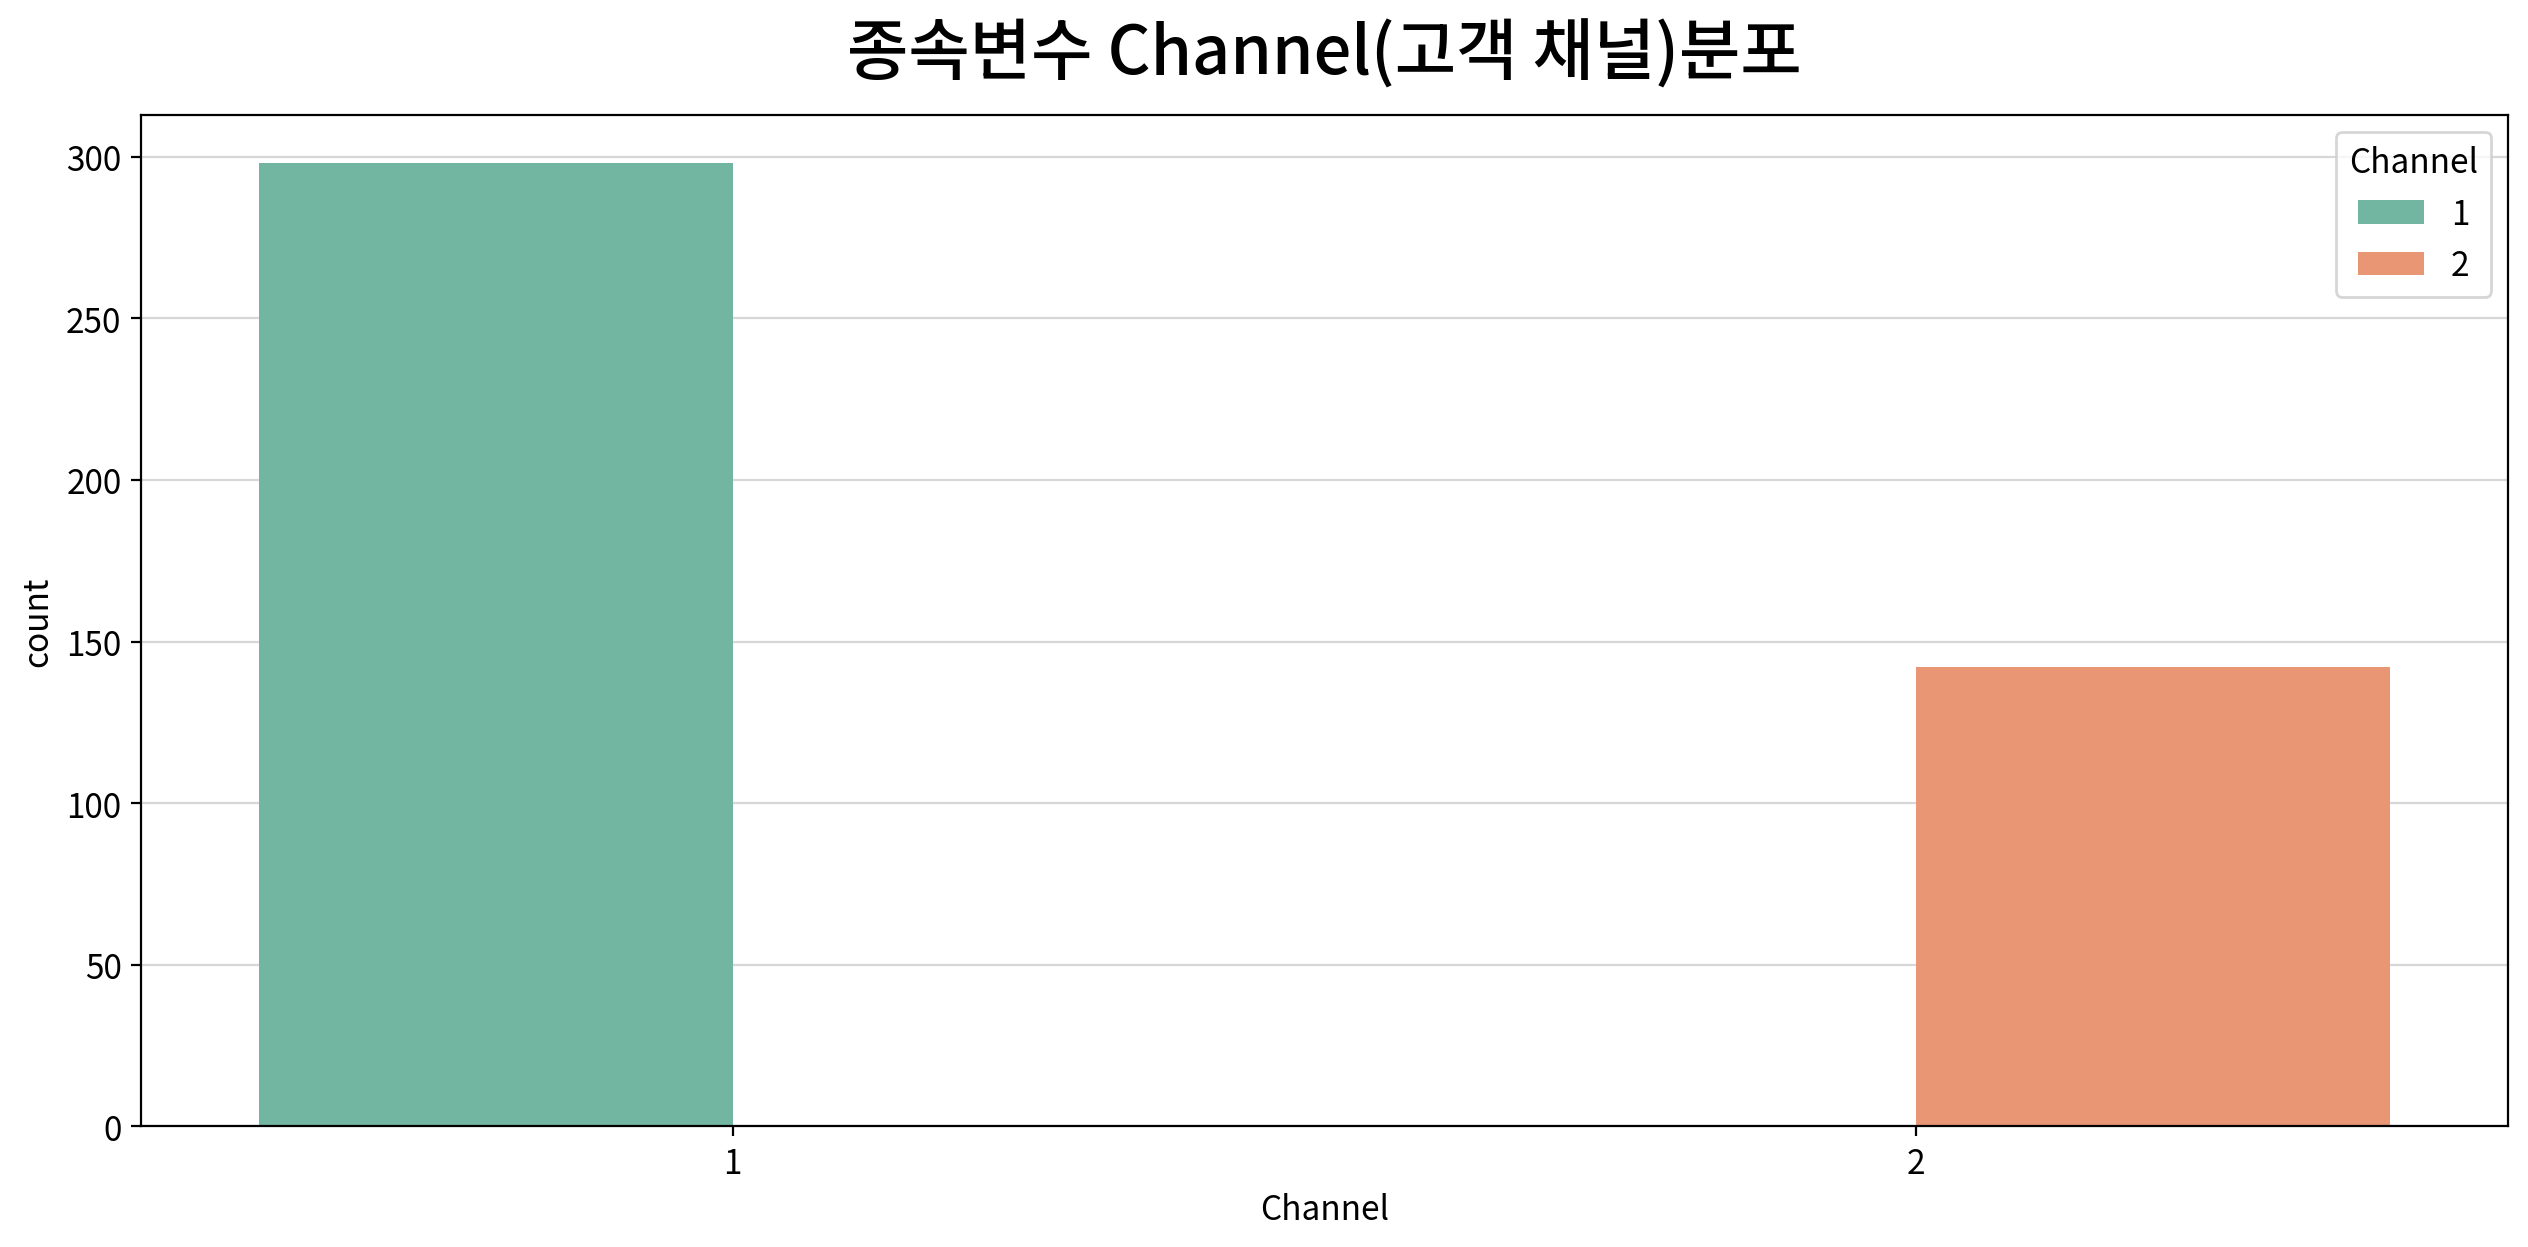

,count,unique,top,freq
Channel,440,2,1,298


,빈도,비율
Channel,,
1,298,0.677273
2,142,0.322727


In [20]:
my_plot.countplot(data=drop_df, x=target, hue=target, palette='Set2',
                  title = f'종속변수 {target}({column_means[target]})분포')

display(cat_desc[[target]].T)

# 빈도표 생성
freq = drop_df[target].value_counts().rename('빈도').to_frame()
freq['비율'] = drop_df[target].value_counts(normalize=True)
display(freq)

### 🔍해석
**종속변수 단변량**
> 채널1 **67.7%** / 채널2 **32.3%** 로 **기대 오분류 규모의 기준선이 약 32.3%** 임을 알 수 있다.

#### 2-2 연속형 독립변수에 대한 단변량 분석 

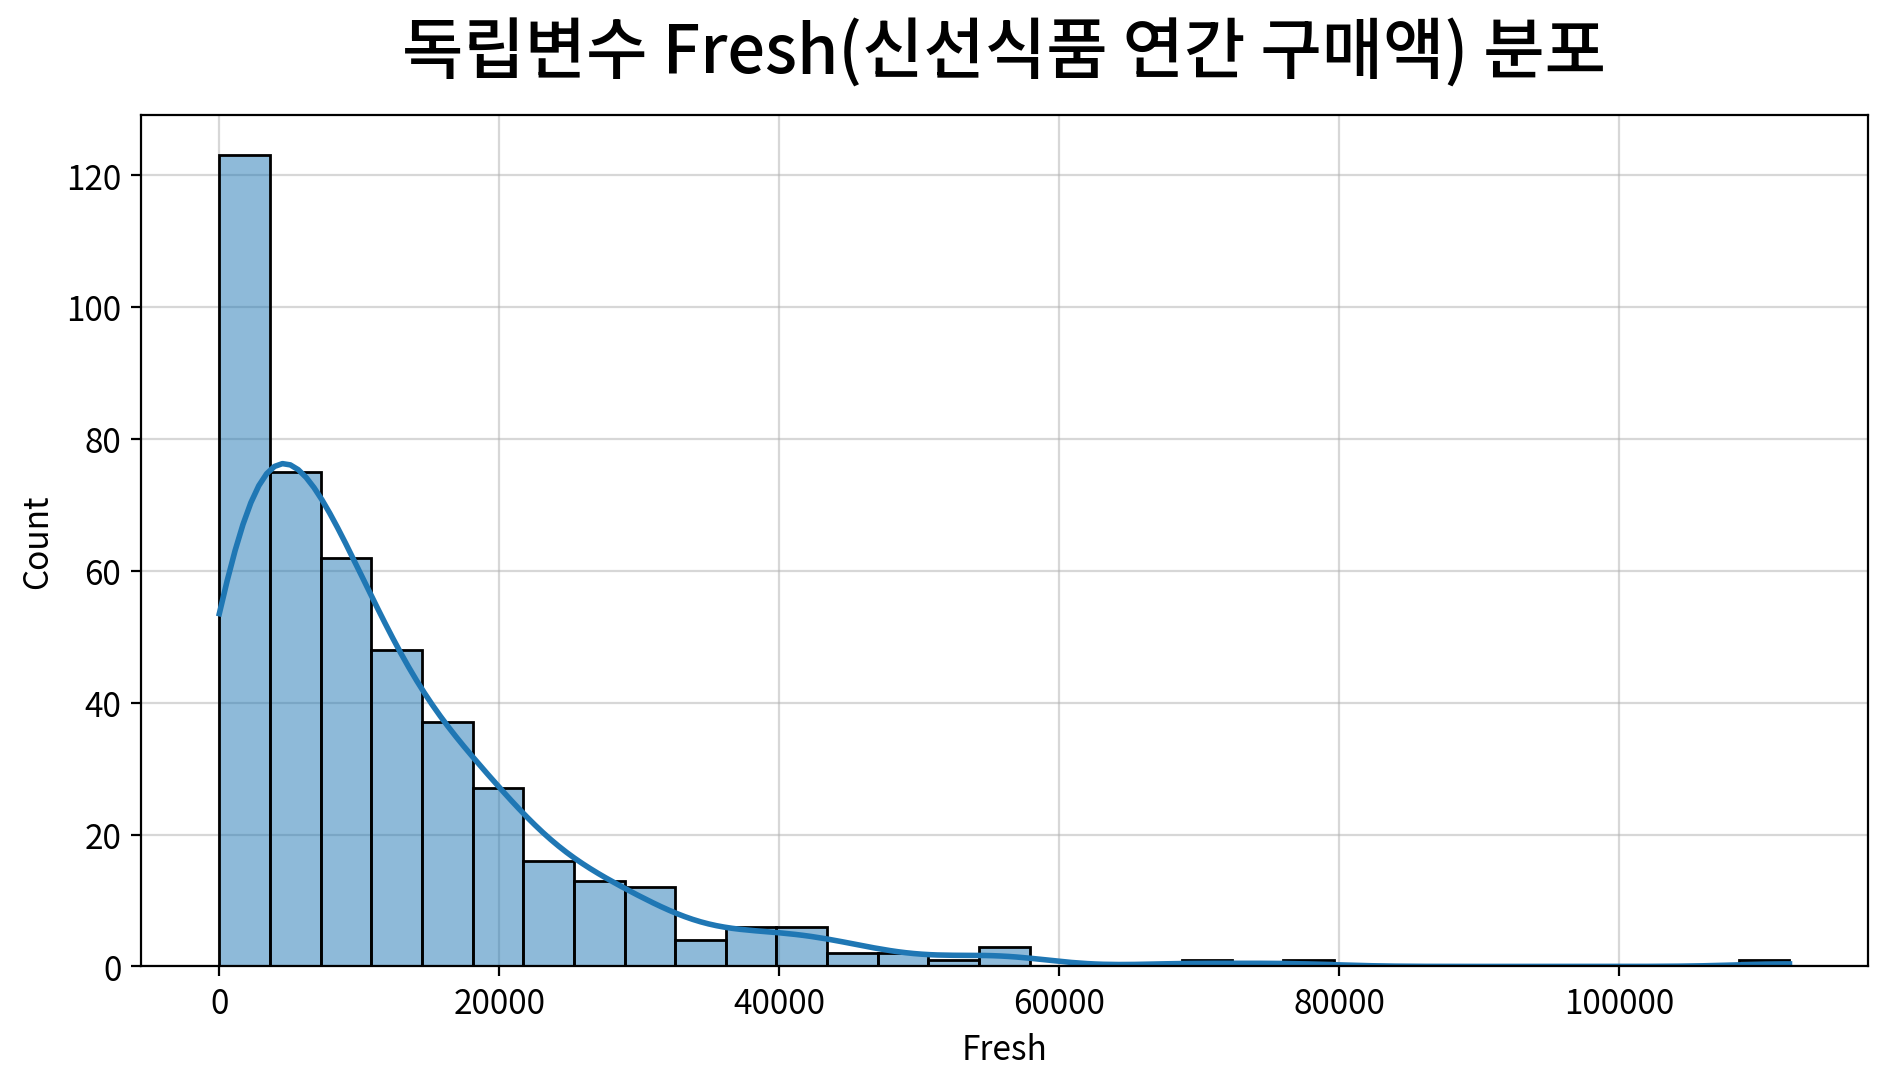

,Fresh
count,440.0
mean,12000.297727
std,12647.328865
min,3.0
25%,3127.75
50%,8504.0
75%,16933.75
max,112151.0
rel_diff,0.411136
rdiff_flag,diff


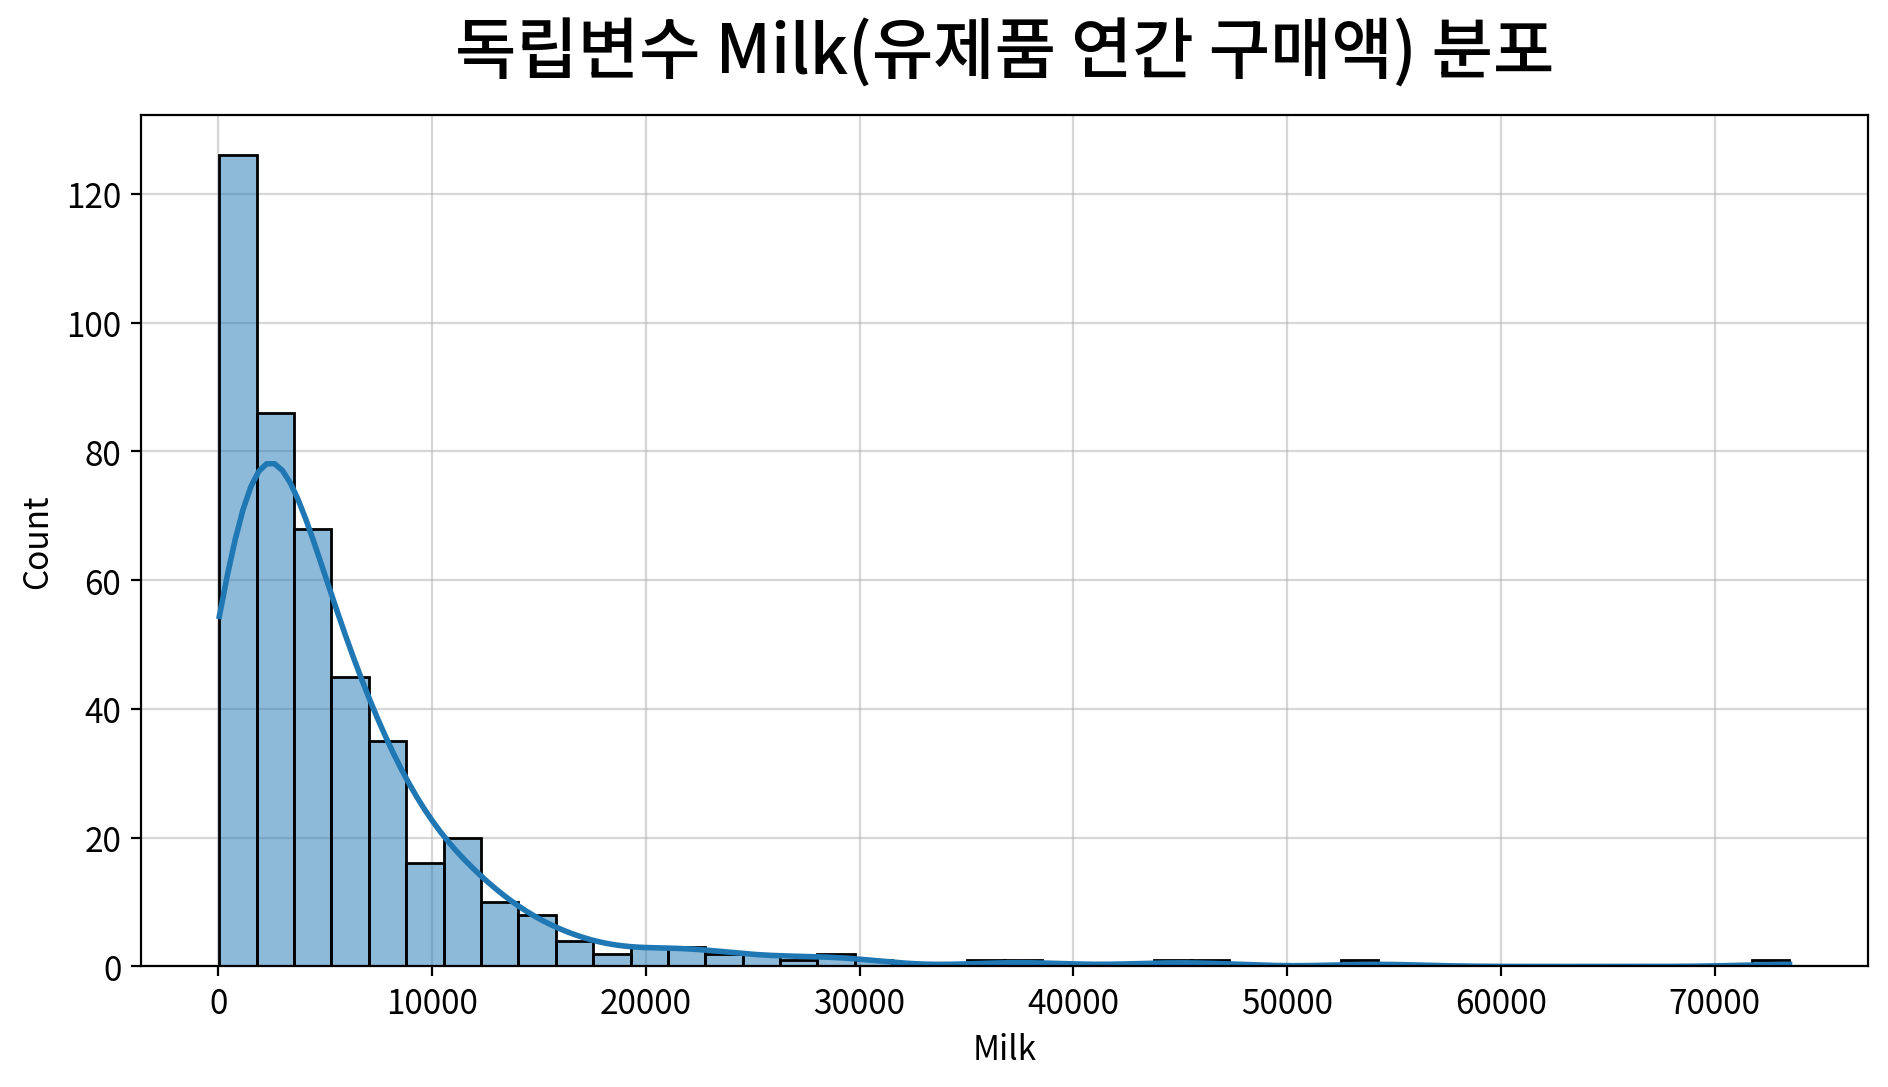

,Milk
count,440.0
mean,5796.265909
std,7380.377175
min,55.0
25%,1533.0
50%,3627.0
75%,7190.25
max,73498.0
rel_diff,0.598088
rdiff_flag,large_diff


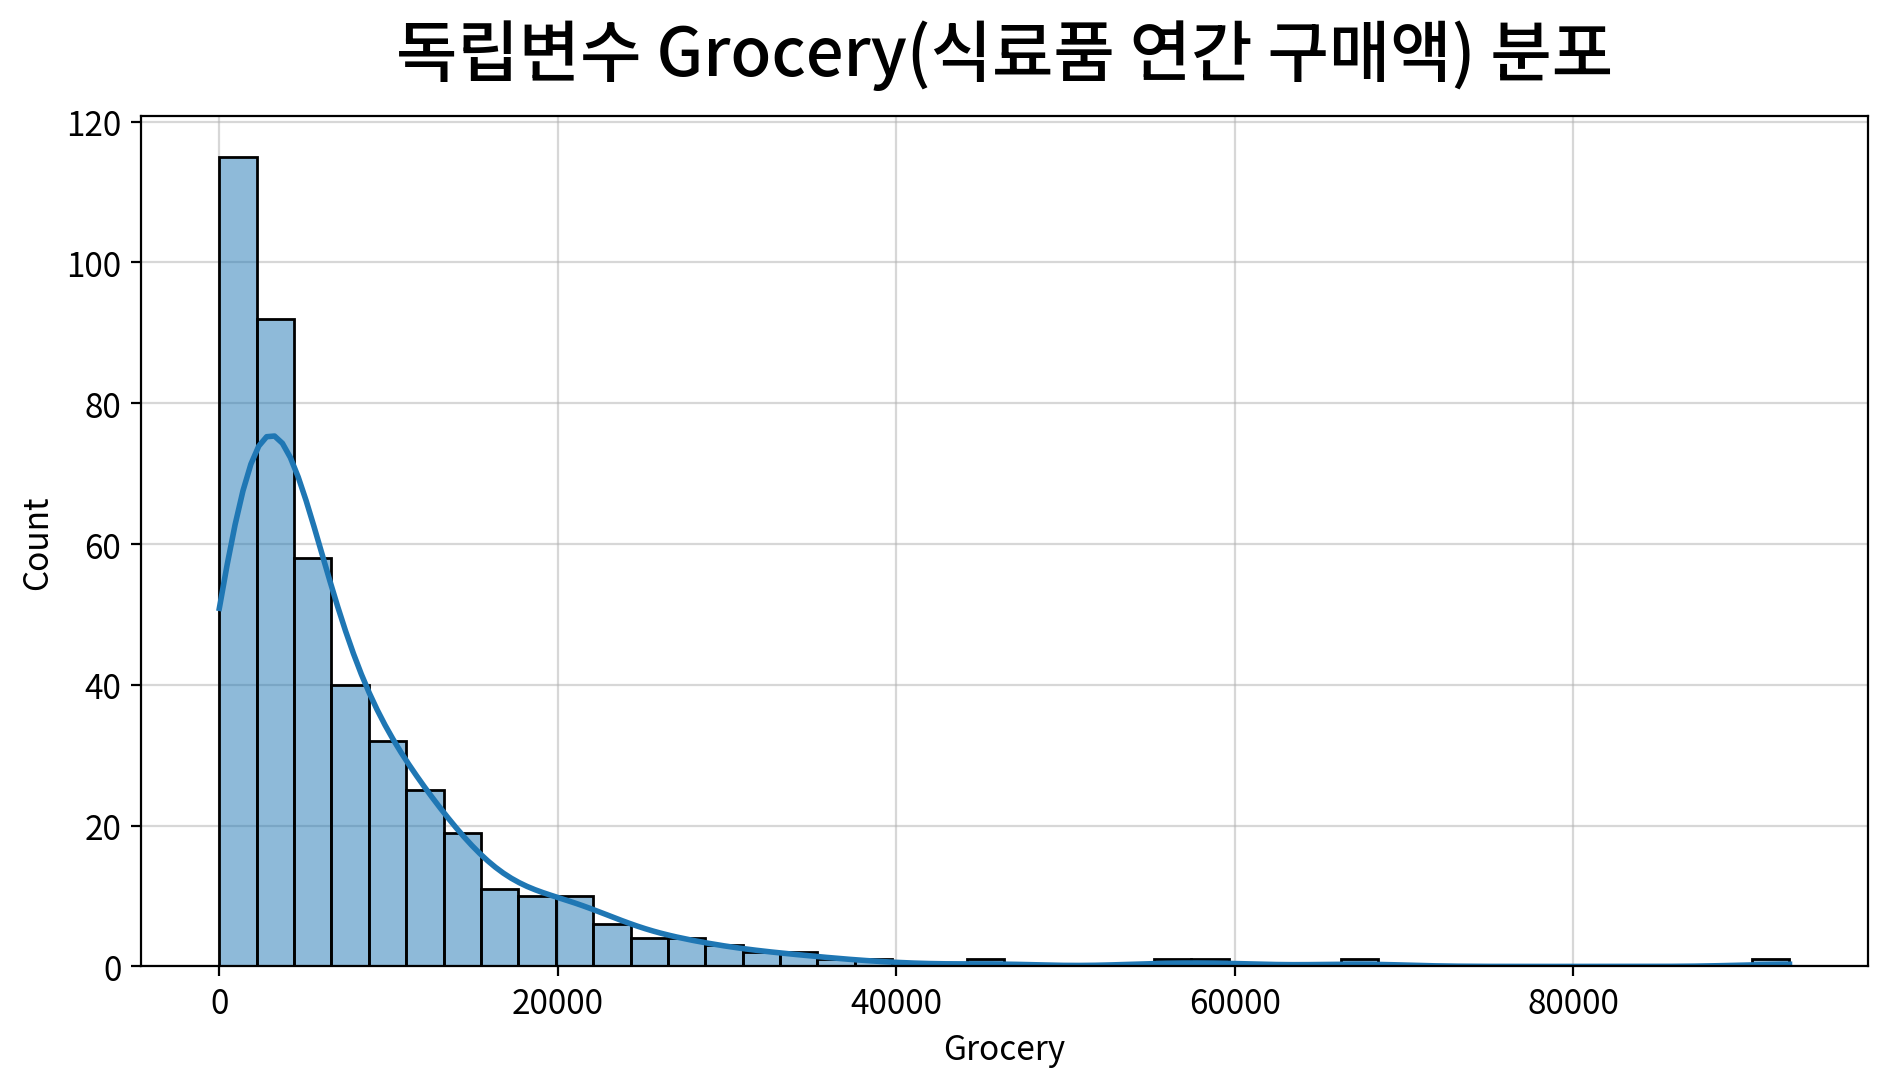

,Grocery
count,440.0
mean,7951.277273
std,9503.162829
min,3.0
25%,2153.0
50%,4755.5
75%,10655.75
max,92780.0
rel_diff,0.672017
rdiff_flag,large_diff


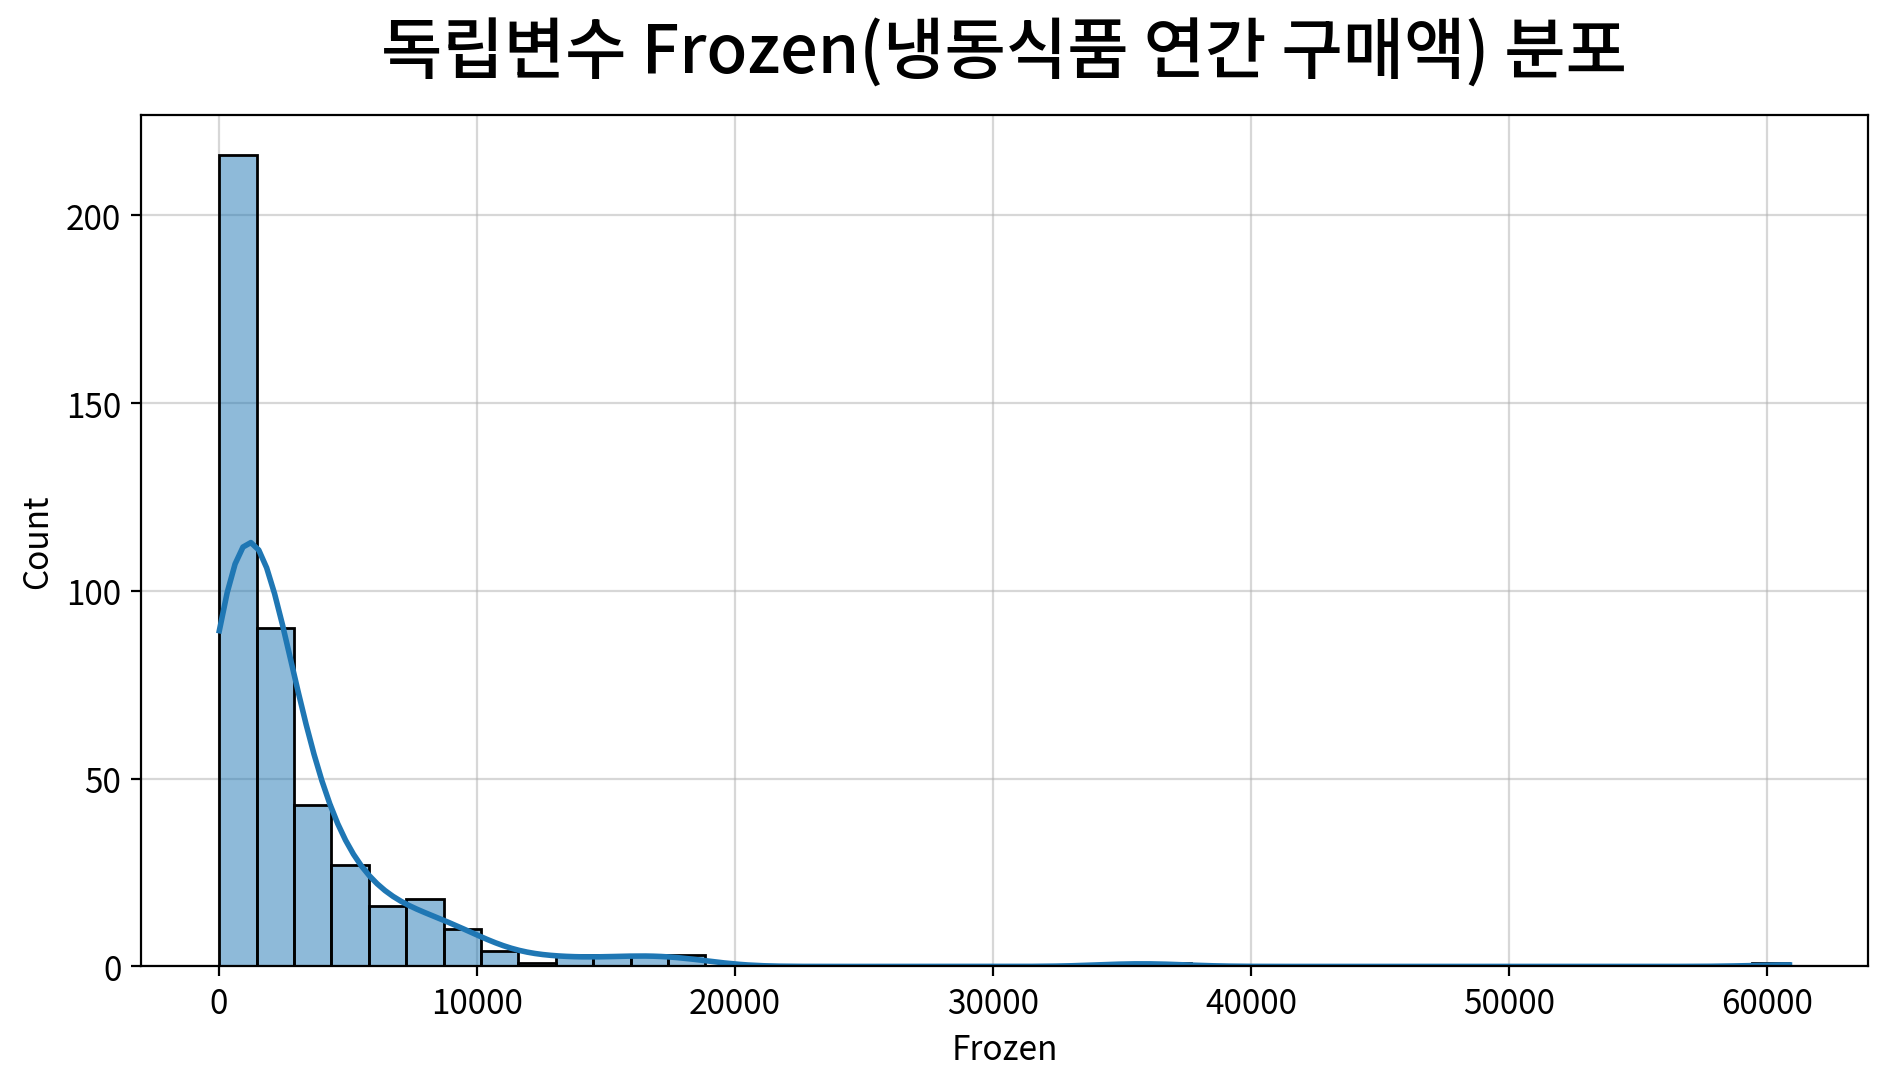

,Frozen
count,440.0
mean,3071.931818
std,4854.673333
min,25.0
25%,742.25
50%,1526.0
75%,3554.25
max,60869.0
rel_diff,1.013061
rdiff_flag,large_diff


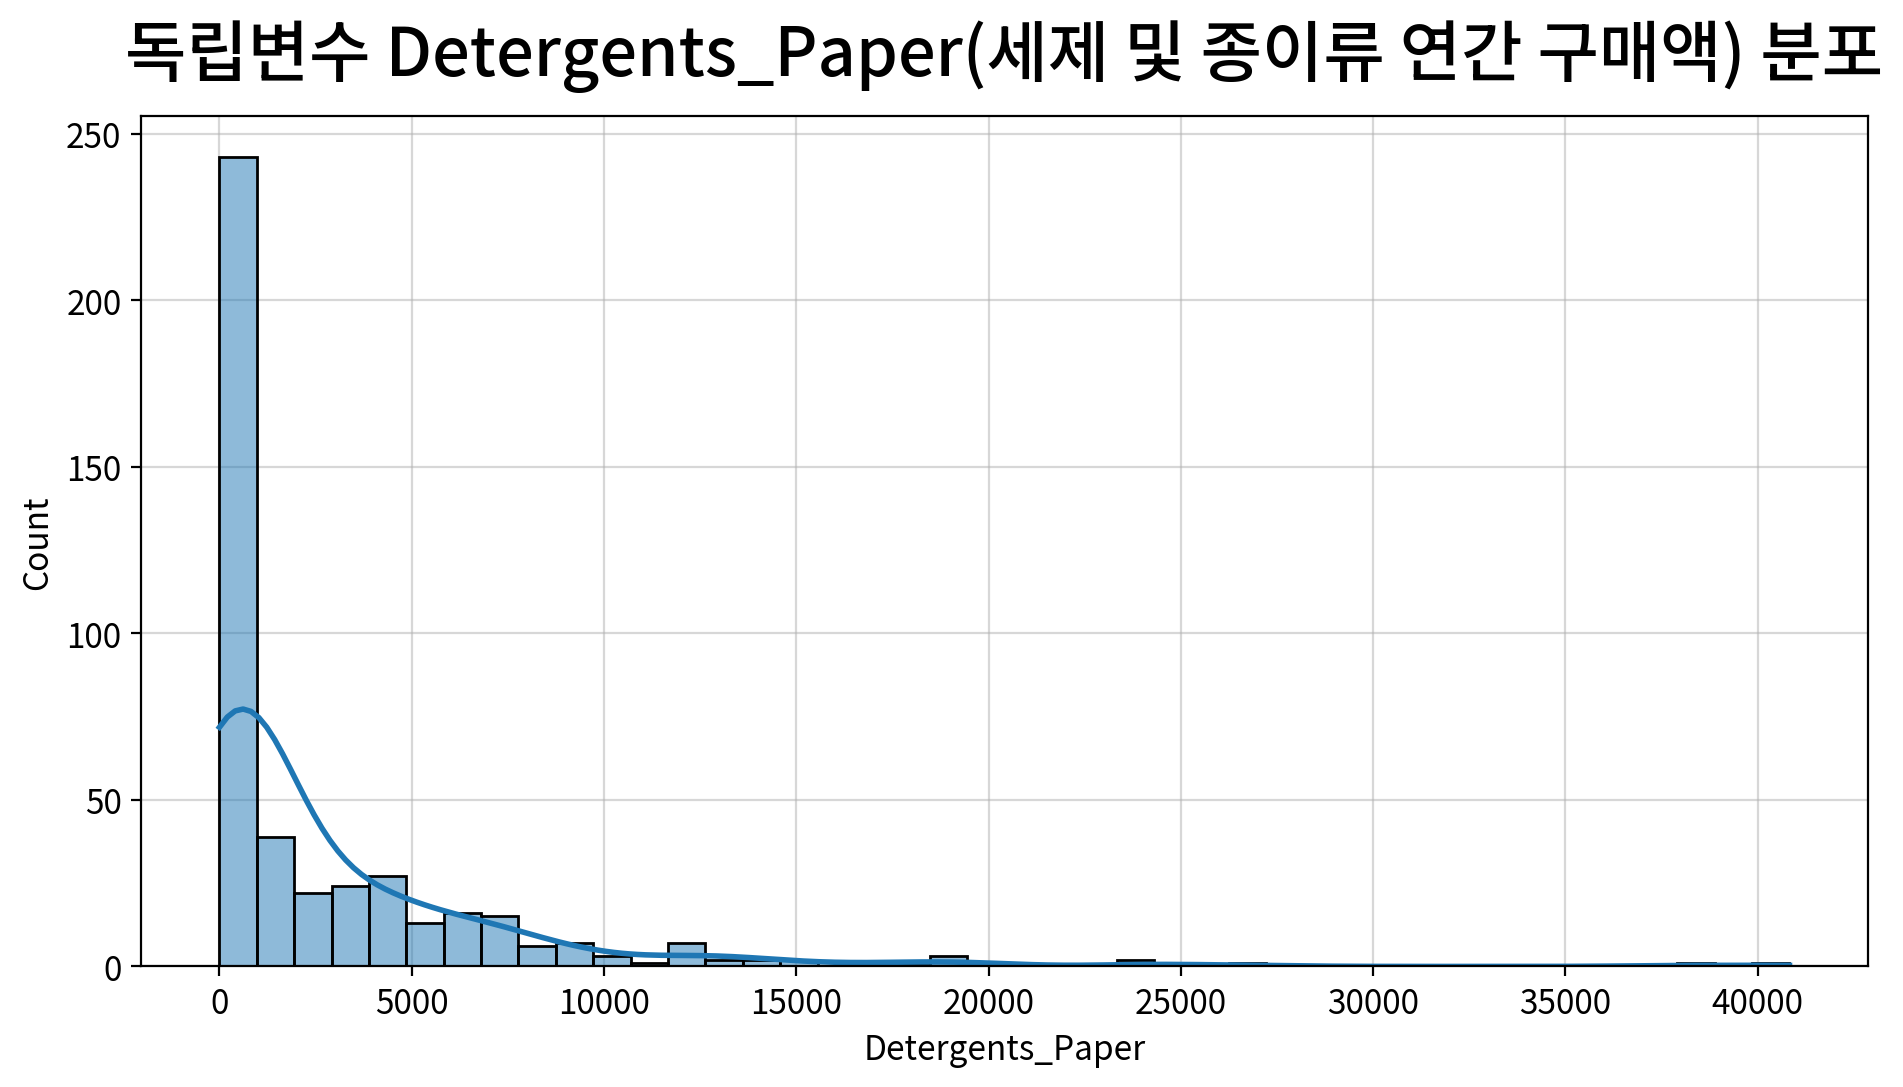

,Detergents_Paper
count,440.0
mean,2881.493182
std,4767.854448
min,3.0
25%,256.75
50%,816.5
75%,3922.0
max,40827.0
rel_diff,2.529079
rdiff_flag,large_diff


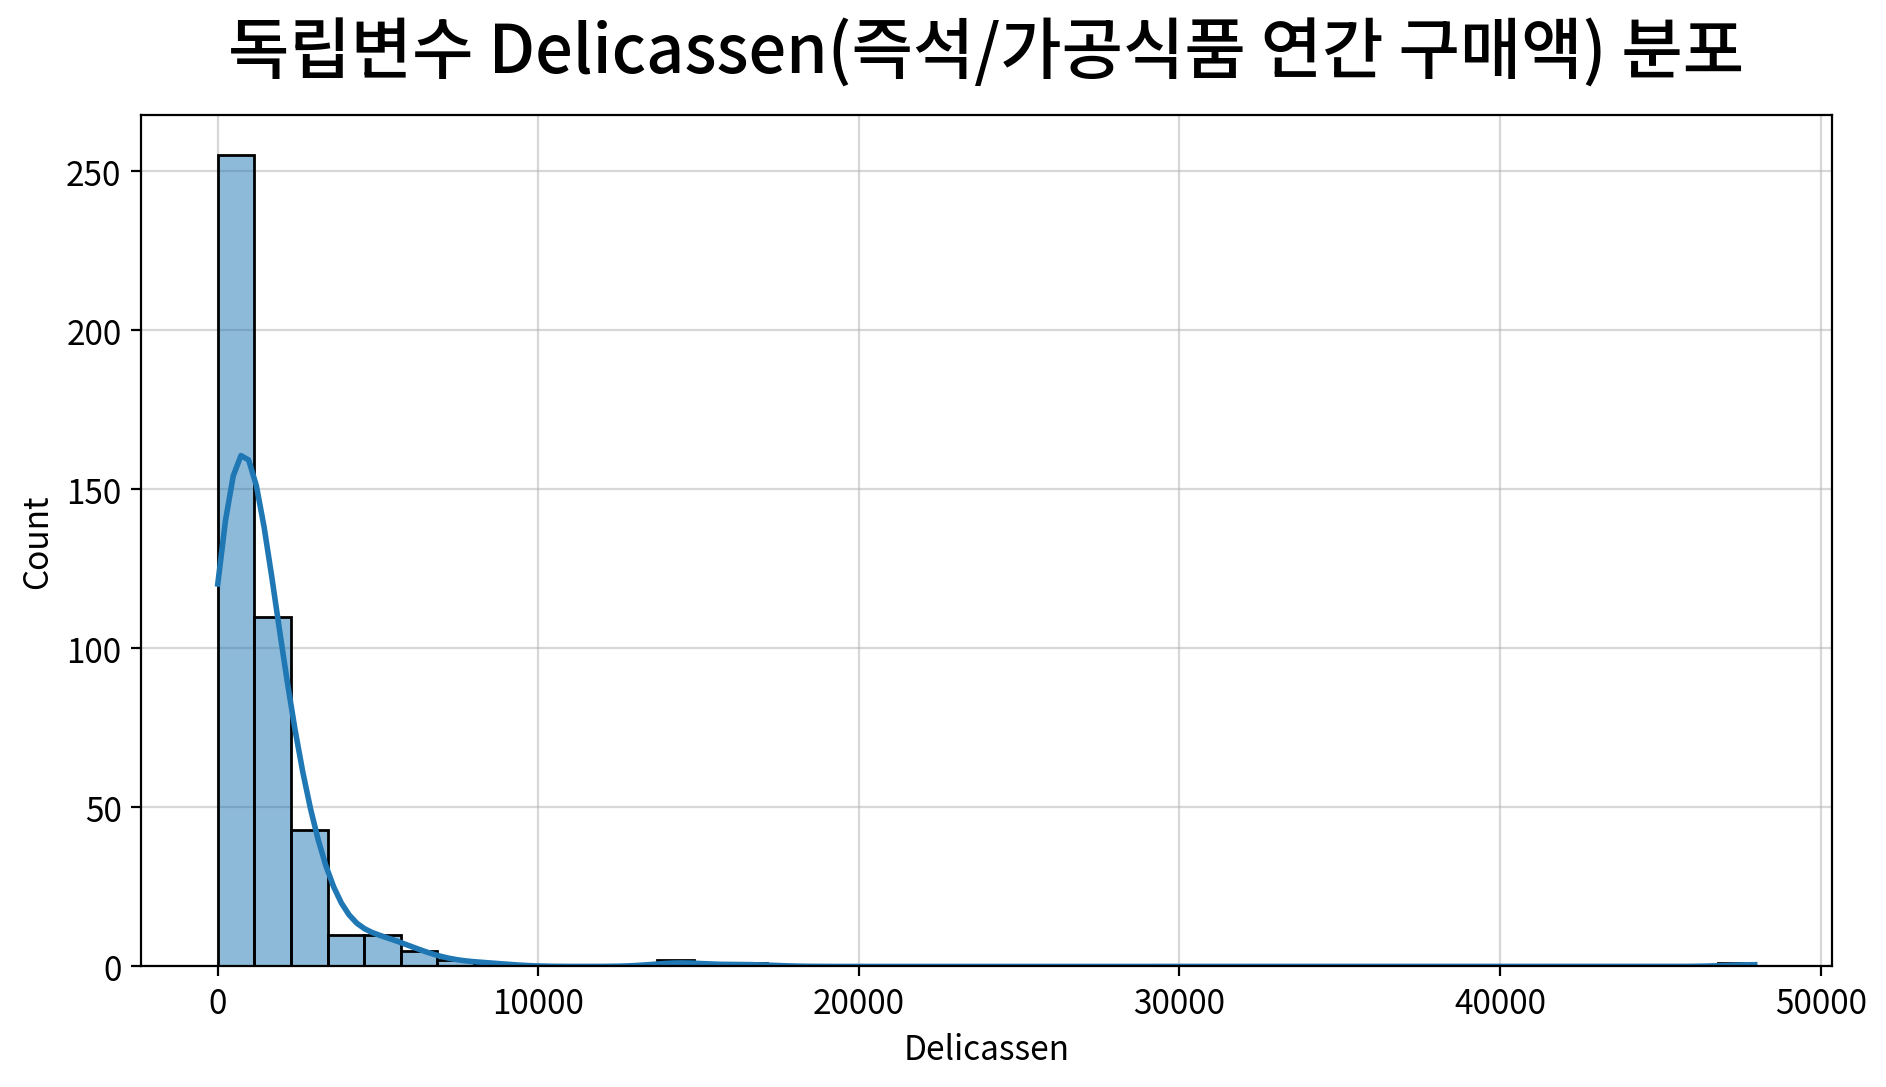

,Delicassen
count,440.0
mean,1524.870455
std,2820.105937
min,3.0
25%,408.25
50%,965.5
75%,1820.25
max,47943.0
rel_diff,0.579358
rdiff_flag,large_diff


In [21]:
for i in num_cols:
    my_plot.histplot(data=drop_df, x=i, kde=True, width=960, height=560,
                     title = f'독립변수 {i}({column_means[i]}) 분포')
    display(num_desc[num_desc.index == i].T)

In [22]:
z = pd.DataFrame(drop_df[num_cols].mean())
z['비율'] = z.loc[:, 0] / z.loc[:,0].sum()
z

,0,비율
Fresh,12000.297727,0.361170
Milk,5796.265909,0.174449
Grocery,7951.277273,0.239308
Frozen,3071.931818,0.092455
Detergents_Paper,2881.493182,0.086724
Delicassen,1524.870455,0.045894


### 🔍 해석

#### 연속형 변수 단변량분석

| 변수 | 분포 모양(왜도, 첨도) | 봉우리 | 상한 이상치 | 평균 | 중앙값 |판단·조치 |
|---|---|---|---|---|---|---|
| `Fresh` | 강한 우편향 (+2.56), <br> 첨도 (11.54) | 0 근처 단봉 | 20건(4.5%) | 약 12,000 |8,504|**로그 변환**(log) |
| `Milk` | 강한 우편향 (+4.05), <br> 첨도 (24.67) | 0 근처 단봉 | 28건(6.4%) |  약 5,796|3,627|**로그 변환**(log) |
| `Grocery` | 강한 우편향 (+3.59), <br> 첨도 (20.91) | 0 근처 단봉 | 24건(5.5%) |  약 7,951|4,755.5|**로그 변환**(log) |
| `Frozen` | **극단적 우편향** (+5.91), <br> 첨도 (54.69) | 0 근처 단봉 | 43건(9.8%) | 약 3,072|1526|**로그 변환**(log) |
| `Detergents_Paper` | 강한 우편향 (+3.63), <br> 첨도 (19.01) | 0 근처 단봉 | 30건(6.8%) |약 2,881|816.5| **로그 변환**(log) |
| `Delicassen` | **극단적 우편향** (11.15), <br> 첨도 (170.69) | 0 근처 단봉 | 27건(6.1%) | 약 1,525| 965.5|**로그 변환**(log) |

- 평균/중앙값 배율이 `Fresh`**1.4배** ~ `Detergents_Paper`**3.5배**로 이는 평균값이 소수 고소비 고객에 의해 부풀려져 있다. "평균 구매 고객"이라는 표현은 실제 다수 고객을 대표하지 못한다.
- 평균 매출 기여도를 보면 **`Fresh`(36.1%)**, **`Grocery`(23.9%)**로 전체 평균 매출의 60%이다. 다만 매출 비중이 크다고 채널 구분력이 큰 것은 아니므로, 채널 판별력은 이변량 분석의 효과크기로 따로 확인한다.
- ※ 표의 "로그 변환"은 EDA 단계의 1차 판단이다. 최종 전처리에서는 로그 변환 시 하한 왜곡이 확인되어 **Yeo-Johnson 변환**으로 대체했다(#3. 모델링 › 1) 데이터 전처리).

### 3) 이변량 분석

#### 3-1 두 집단 비교 검정 - Mann-Whitney U test (2집단 명목형 종속변수 - 연속형 독립변수)


In [23]:
# 연속형 변수 정규성검정
i = my_stats.test_assumptions(drop_df)

display(i)

,test,statistic,p-value,result
field,,,,
Fresh,normaltest,274.341627,2.675917e-60,False
Milk,normaltest,410.653643,6.725035e-90,False
Grocery,normaltest,374.023306,6.051613e-82,False
Frozen,normaltest,546.903996,1.743035e-119,False
Detergents_Paper,normaltest,371.819933,1.821074e-81,False
Delicassen,normaltest,793.298330,5.463316e-173,False
Levene,equal_var,72.136356,6.001349e-71,False


#### > Channel(고객 채널) → Fresh

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

1 vs. 2: Mann-Whitney-Wilcoxon test two-sided, P_val:1.837e-04 U_stat=2.582e+04


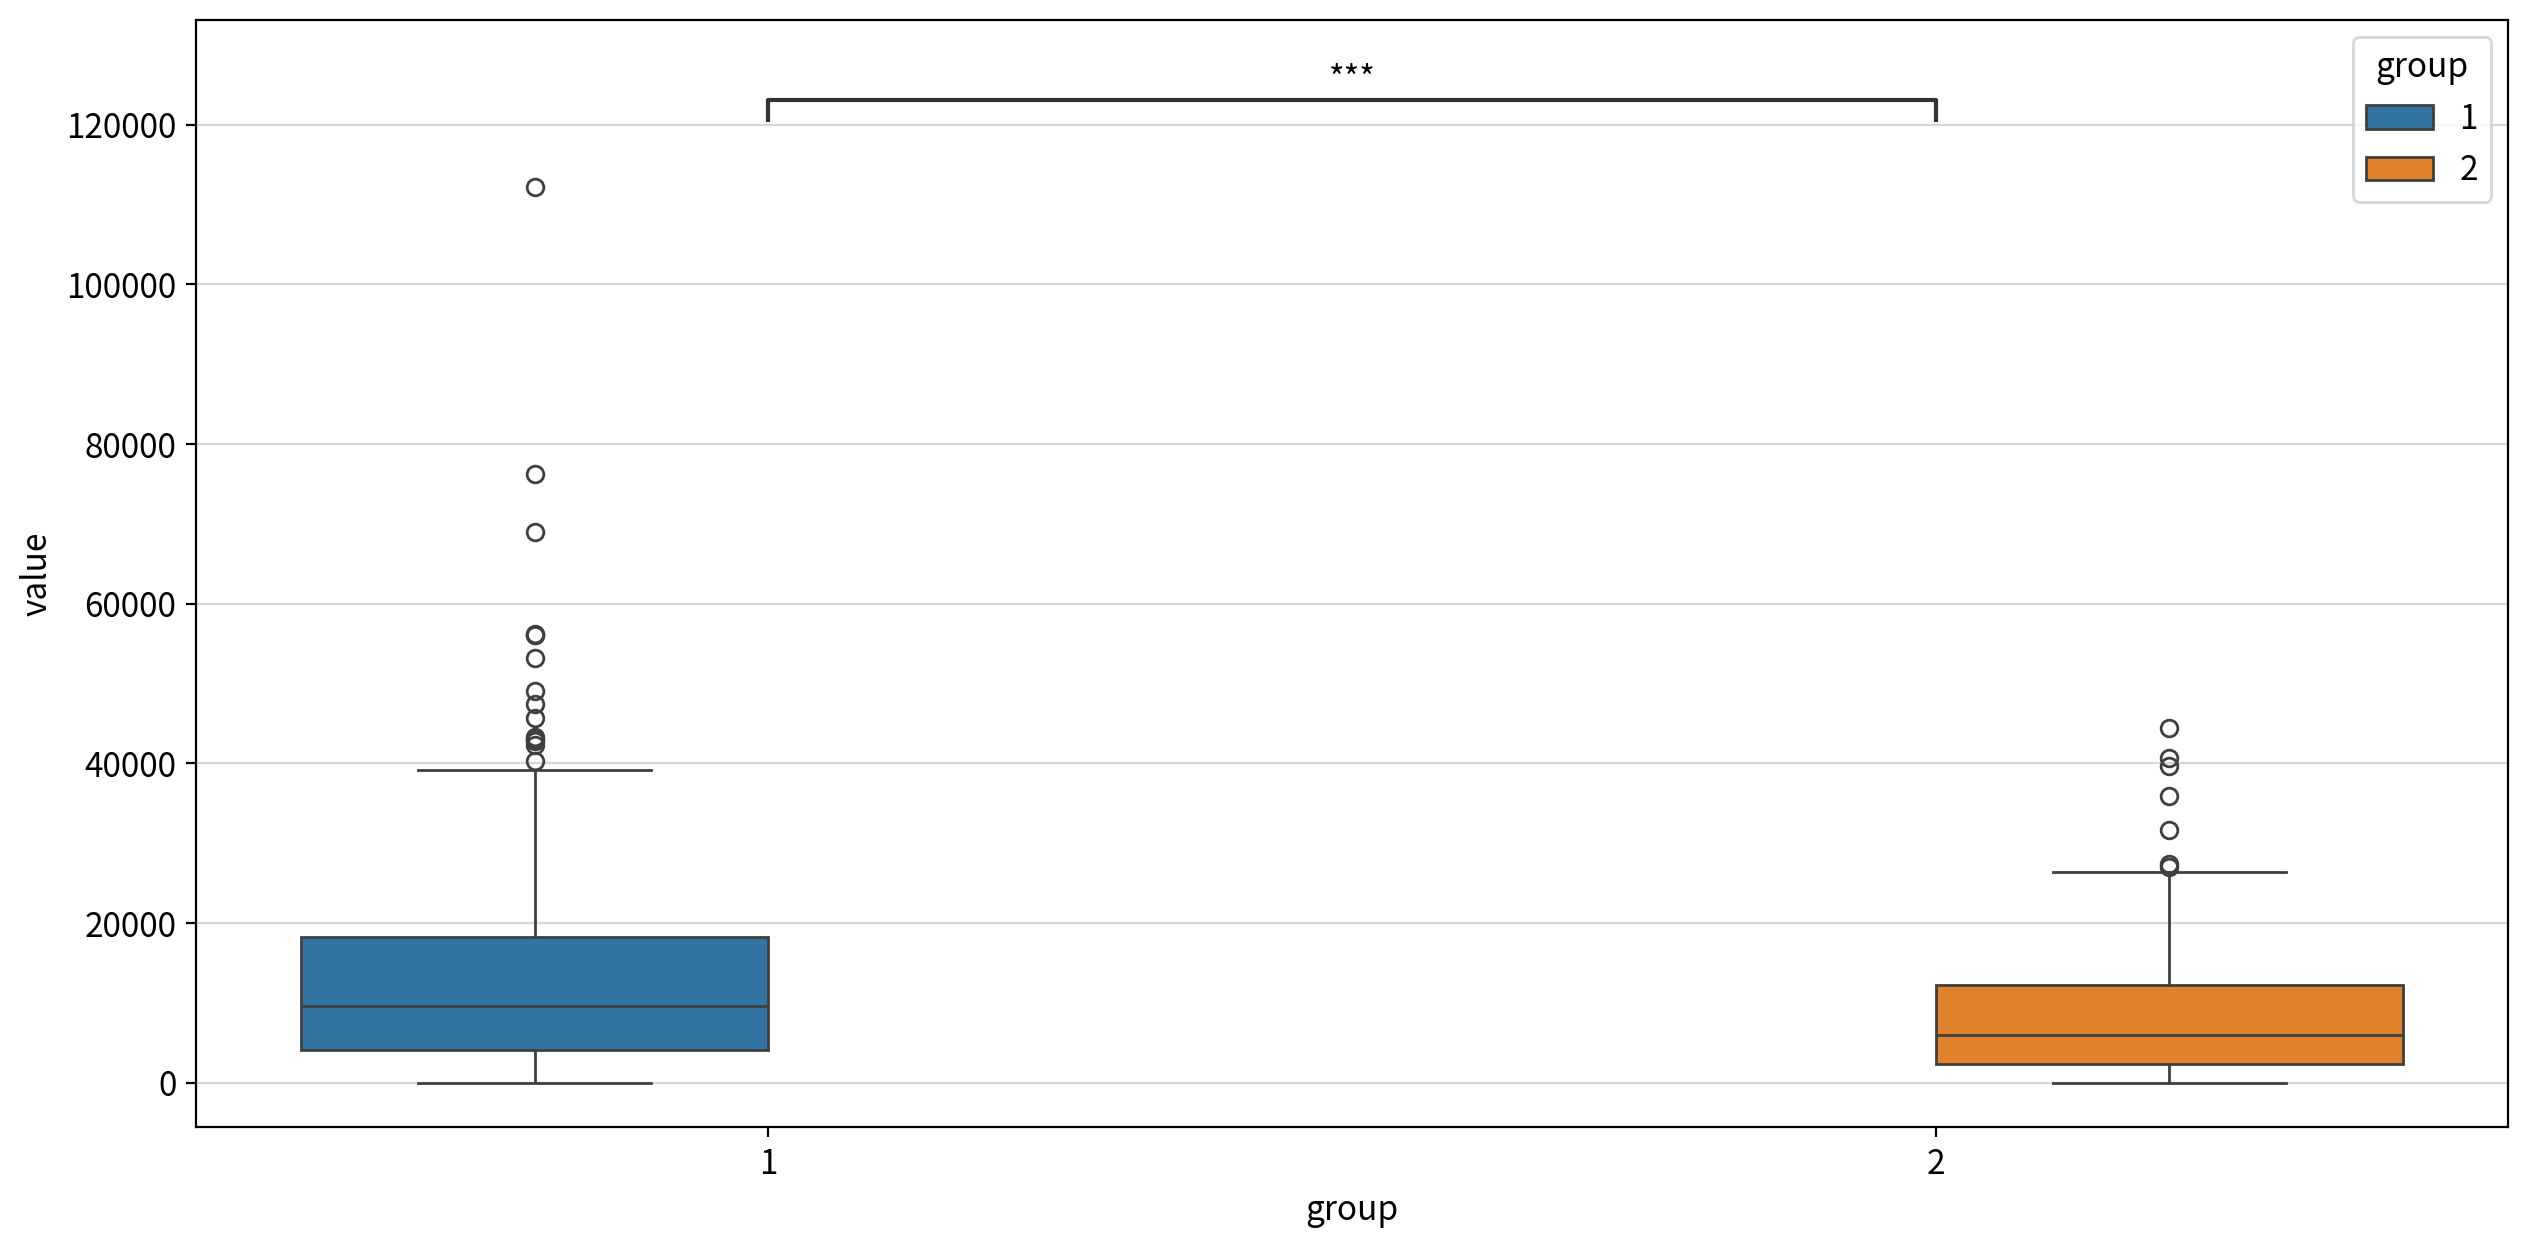

statistic  p-value  significant result  \
test                alternative                                           
Mann-Whitney U test two-sided      25823.0   0.0002         True  1 ≠ 2   
                    less           25823.0   0.9999        False  1 ≥ 2   
                    greater        25823.0   0.0001         True  1 > 2   

                                 Rank-Biserial  
test                alternative                 
Mann-Whitney U test two-sided             0.22  
                    less                  0.22  
                    greater               0.22

집단별 평균값·중앙값


,mean,median
Channel,,
1,13475.560403,9581.5
2,8904.323944,5993.5


#### > Channel(고객 채널) → Milk

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

1 vs. 2: Mann-Whitney-Wilcoxon test two-sided, P_val:7.712e-38 U_stat=5.122e+03


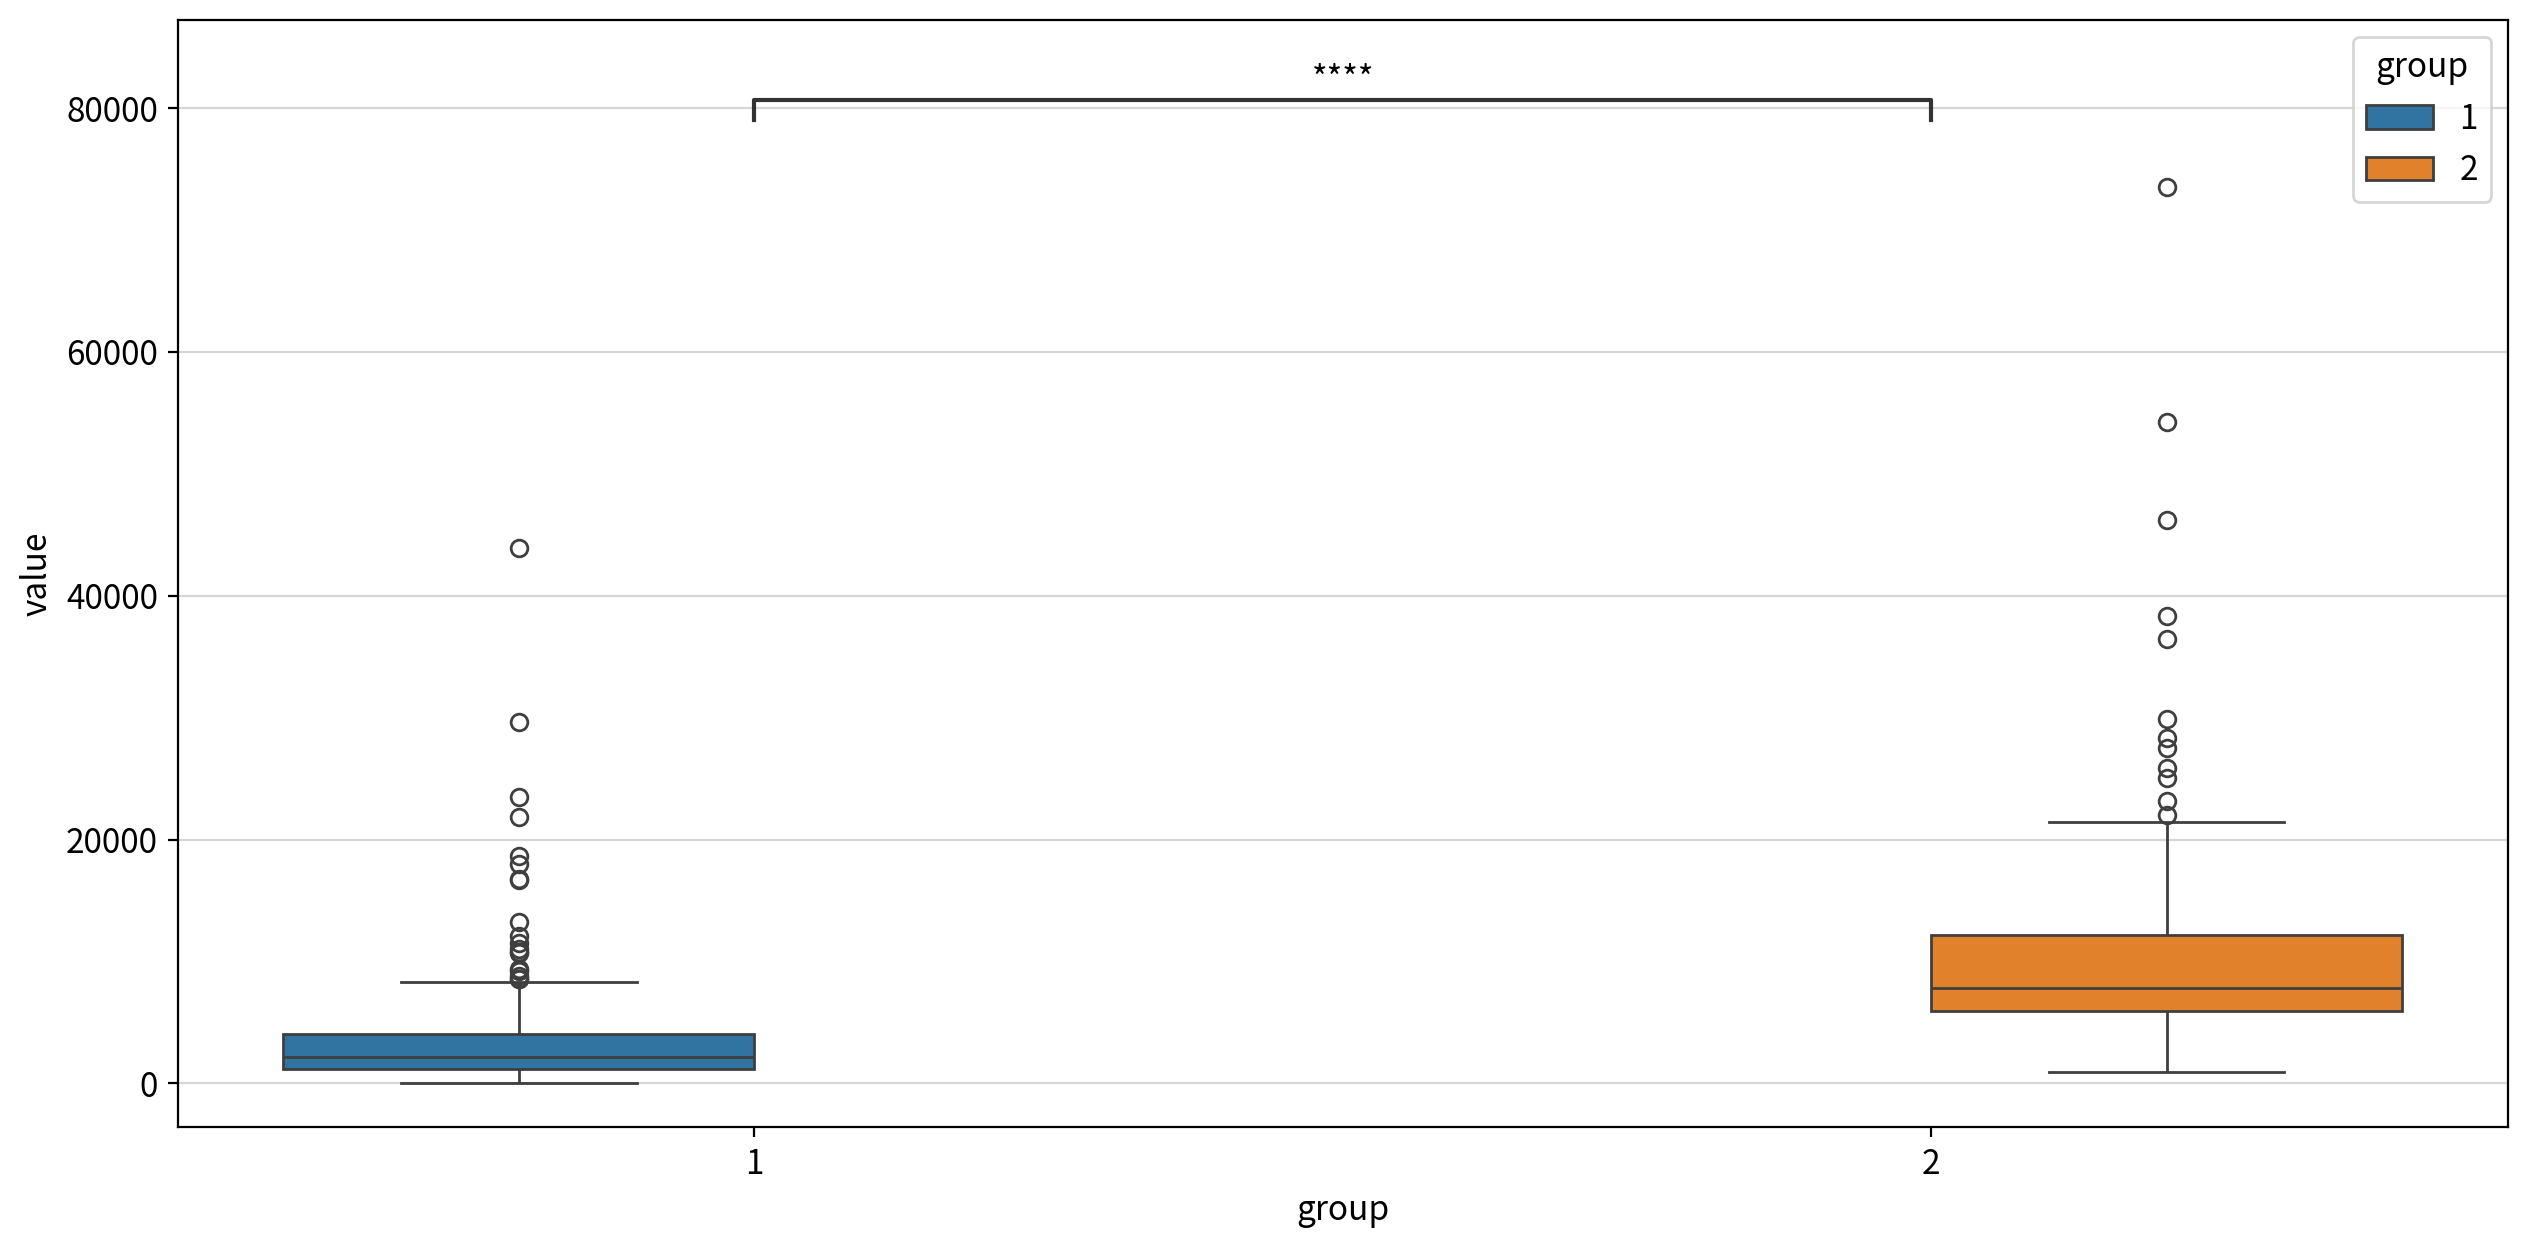

statistic  p-value  significant result  \
test                alternative                                           
Mann-Whitney U test two-sided       5122.5      0.0         True  1 ≠ 2   
                    less            5122.5      0.0         True  1 < 2   
                    greater         5122.5      1.0        False  1 ≤ 2   

                                 Rank-Biserial  
test                alternative                 
Mann-Whitney U test two-sided             0.76  
                    less                  0.76  
                    greater               0.76

집단별 평균값·중앙값


,mean,median
Channel,,
1,3451.724832,2157.0
2,10716.500000,7812.0


#### > Channel(고객 채널) → Grocery

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

1 vs. 2: Mann-Whitney-Wilcoxon test two-sided, P_val:6.637e-50 U_stat=2.635e+03


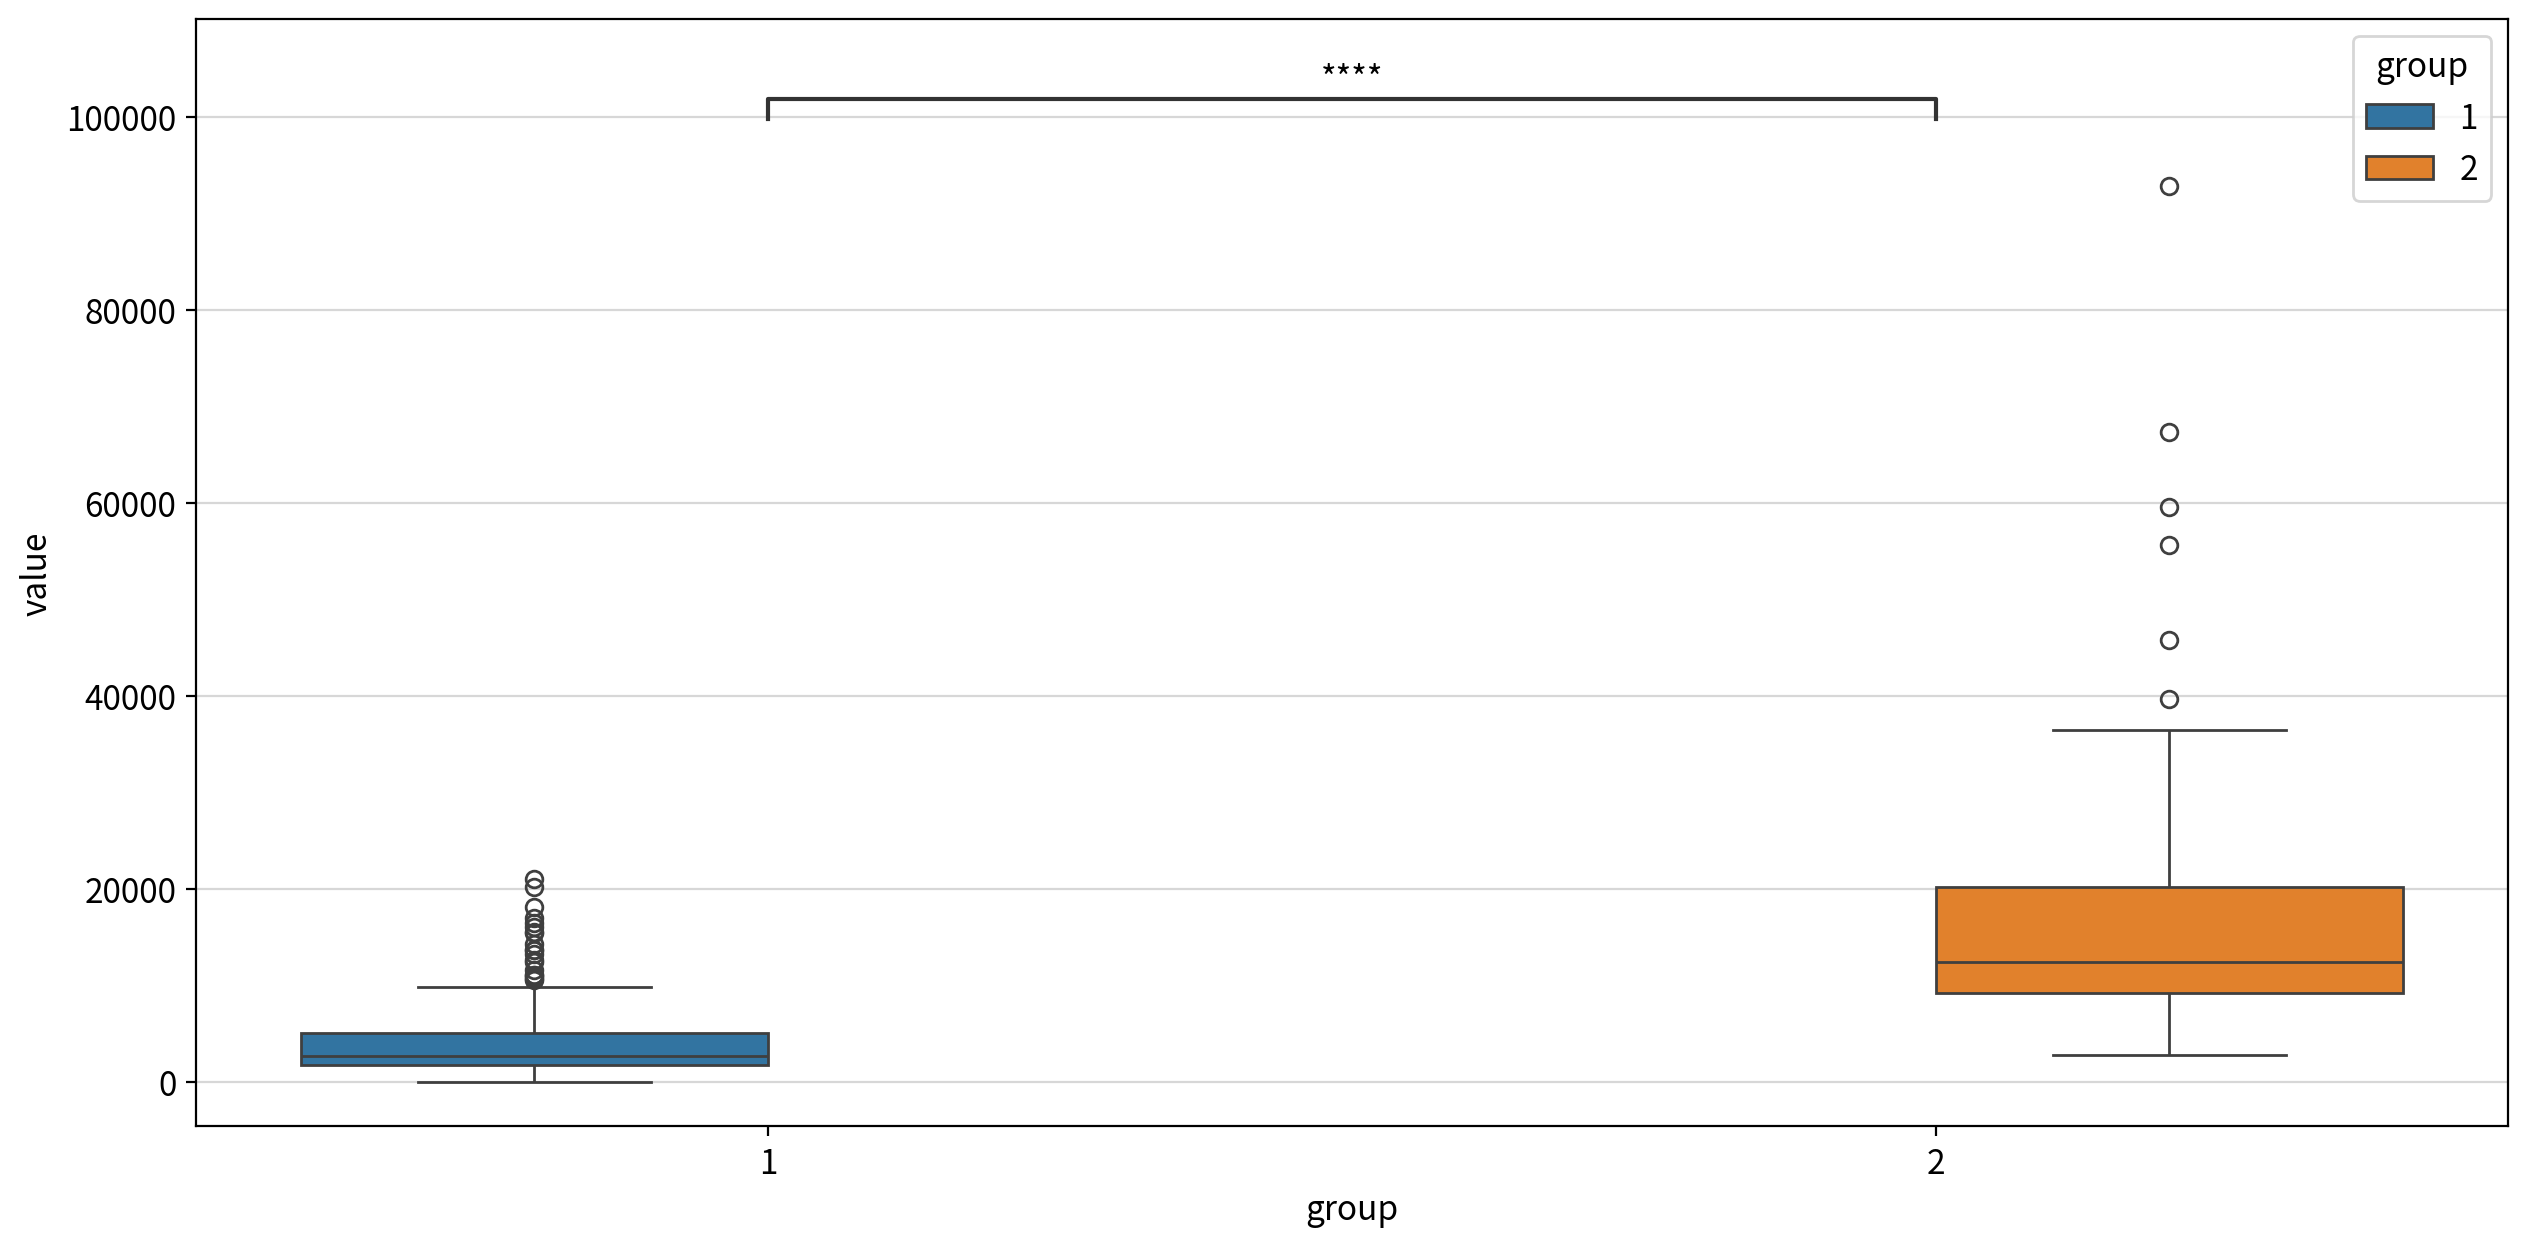

statistic  p-value  significant result  \
test                alternative                                           
Mann-Whitney U test two-sided       2635.0      0.0         True  1 ≠ 2   
                    less            2635.0      0.0         True  1 < 2   
                    greater         2635.0      1.0        False  1 ≤ 2   

                                 Rank-Biserial  
test                alternative                 
Mann-Whitney U test two-sided             0.88  
                    less                  0.88  
                    greater               0.88

집단별 평균값·중앙값


,mean,median
Channel,,
1,3962.137584,2684.0
2,16322.852113,12390.0


#### > Channel(고객 채널) → Frozen

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

1 vs. 2: Mann-Whitney-Wilcoxon test two-sided, P_val:7.402e-07 U_stat=2.733e+04


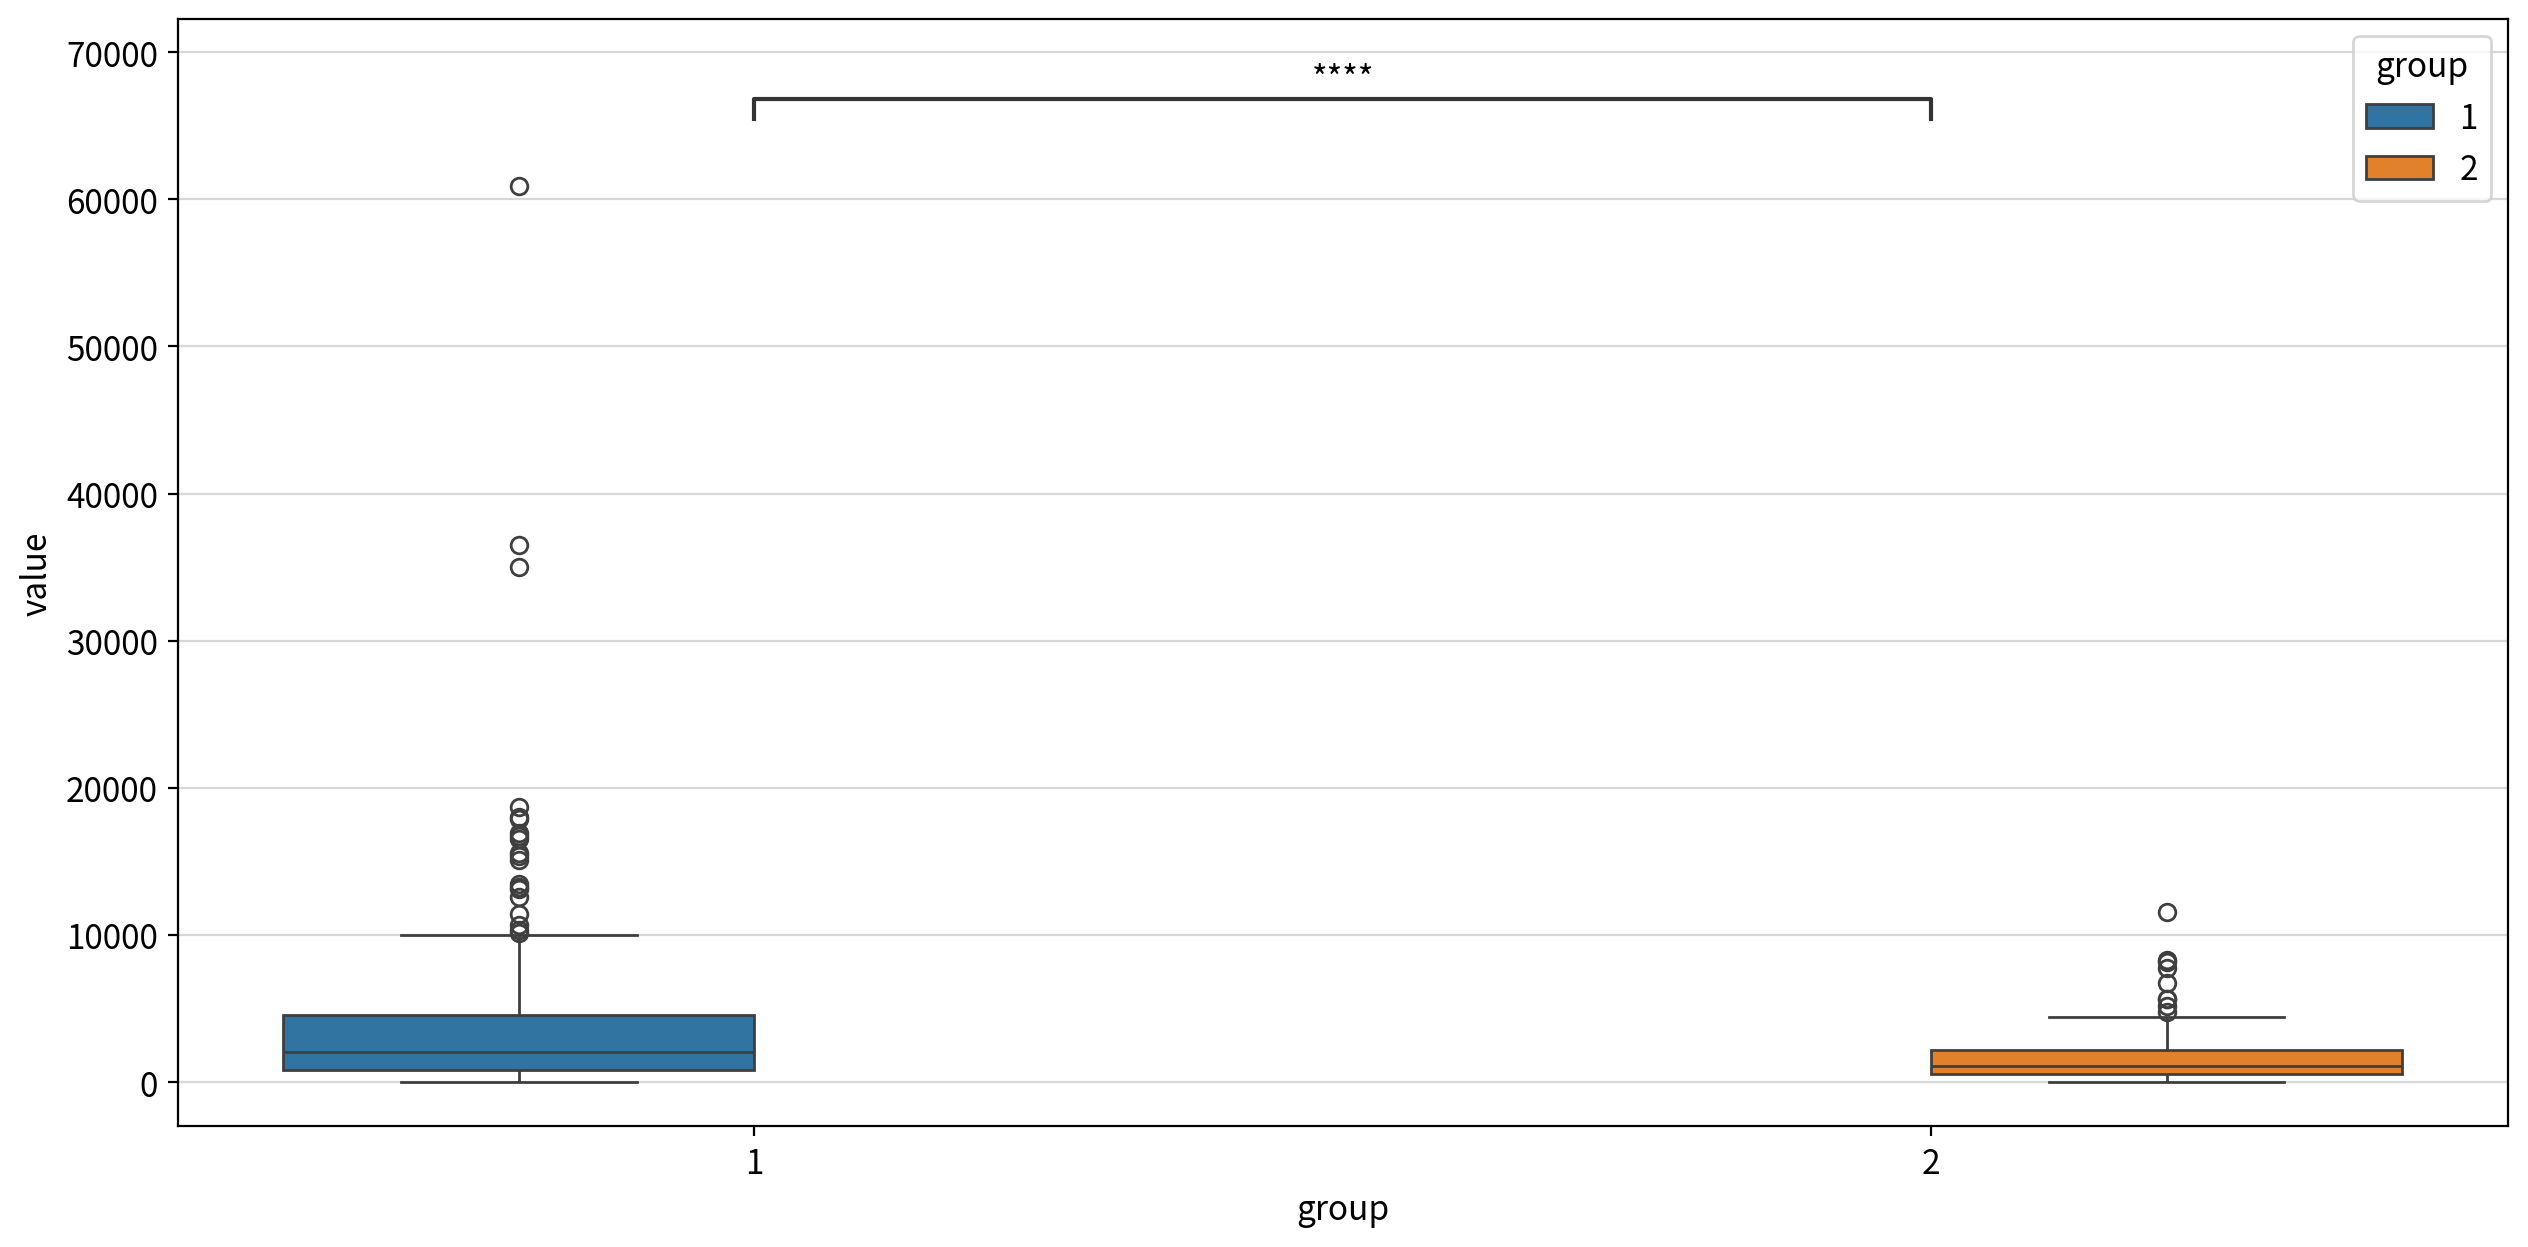

statistic  p-value  significant result  \
test                alternative                                           
Mann-Whitney U test two-sided      27332.0      0.0         True  1 ≠ 2   
                    less           27332.0      1.0        False  1 ≥ 2   
                    greater        27332.0      0.0         True  1 > 2   

                                 Rank-Biserial  
test                alternative                 
Mann-Whitney U test two-sided             0.29  
                    less                  0.29  
                    greater               0.29

집단별 평균값·중앙값


,mean,median
Channel,,
1,3748.251678,2057.5
2,1652.612676,1081.0


#### > Channel(고객 채널) → Detergents_Paper

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

1 vs. 2: Mann-Whitney-Wilcoxon test two-sided, P_val:4.591e-55 U_stat=1.667e+03


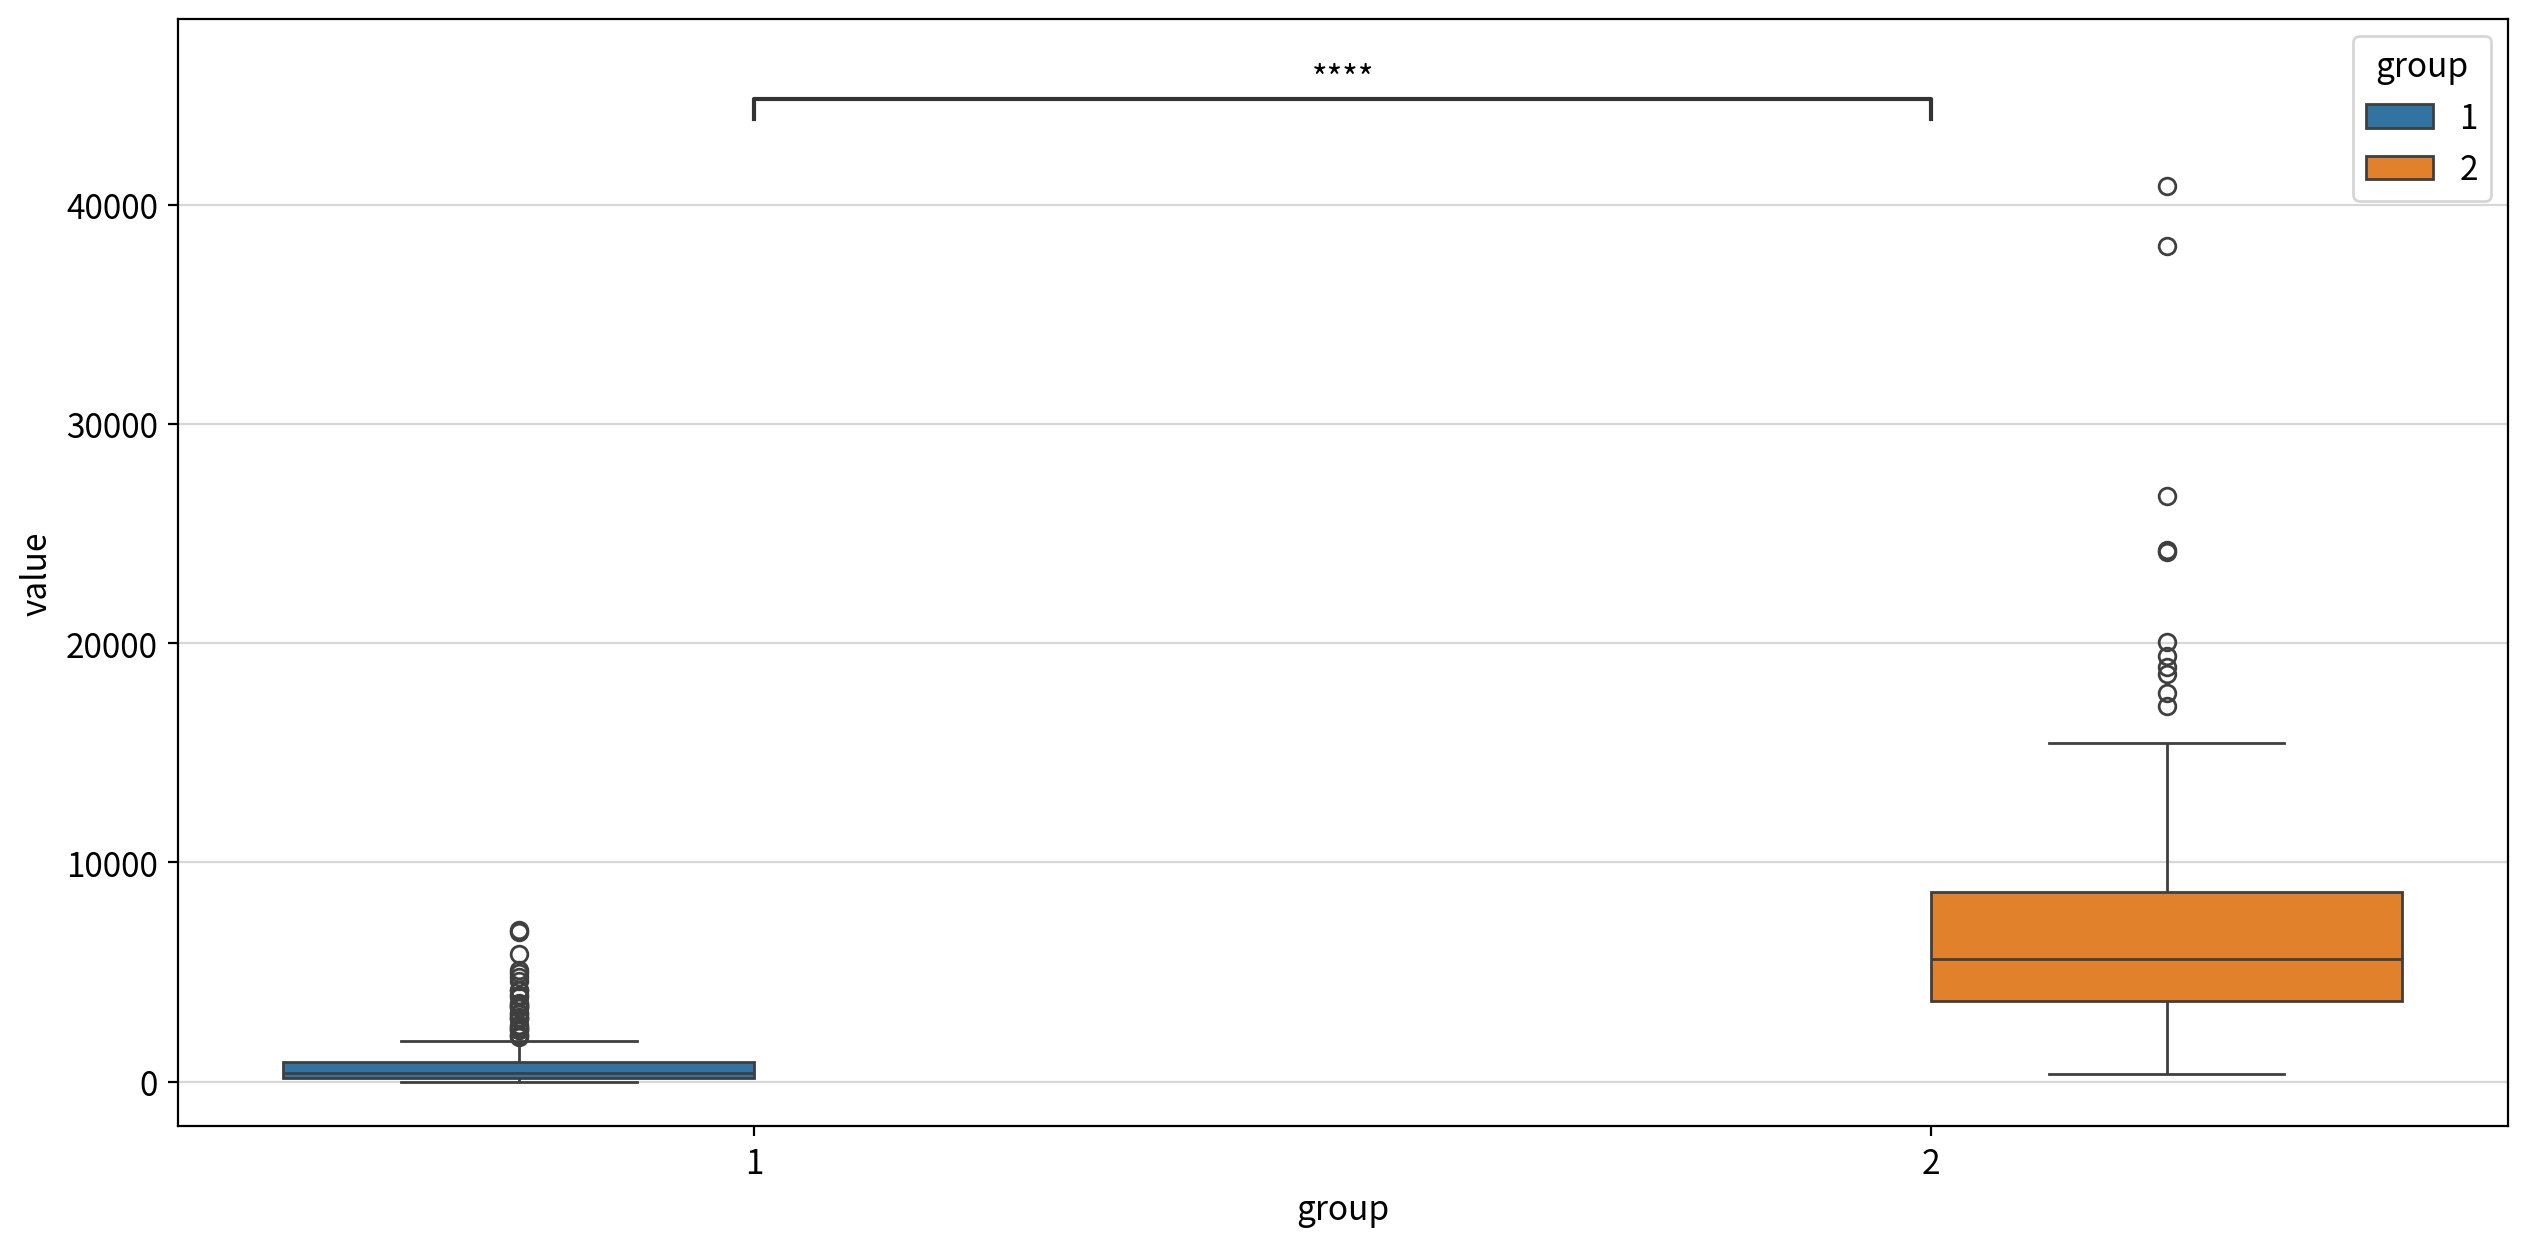

statistic  p-value  significant result  \
test                alternative                                           
Mann-Whitney U test two-sided       1667.0      0.0         True  1 ≠ 2   
                    less            1667.0      0.0         True  1 < 2   
                    greater         1667.0      1.0        False  1 ≤ 2   

                                 Rank-Biserial  
test                alternative                 
Mann-Whitney U test two-sided             0.92  
                    less                  0.92  
                    greater               0.92

집단별 평균값·중앙값


,mean,median
Channel,,
1,790.560403,385.5
2,7269.507042,5614.5


#### > Channel(고객 채널) → Delicassen

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

1 vs. 2: Mann-Whitney-Wilcoxon test two-sided, P_val:5.495e-04 U_stat=1.685e+04


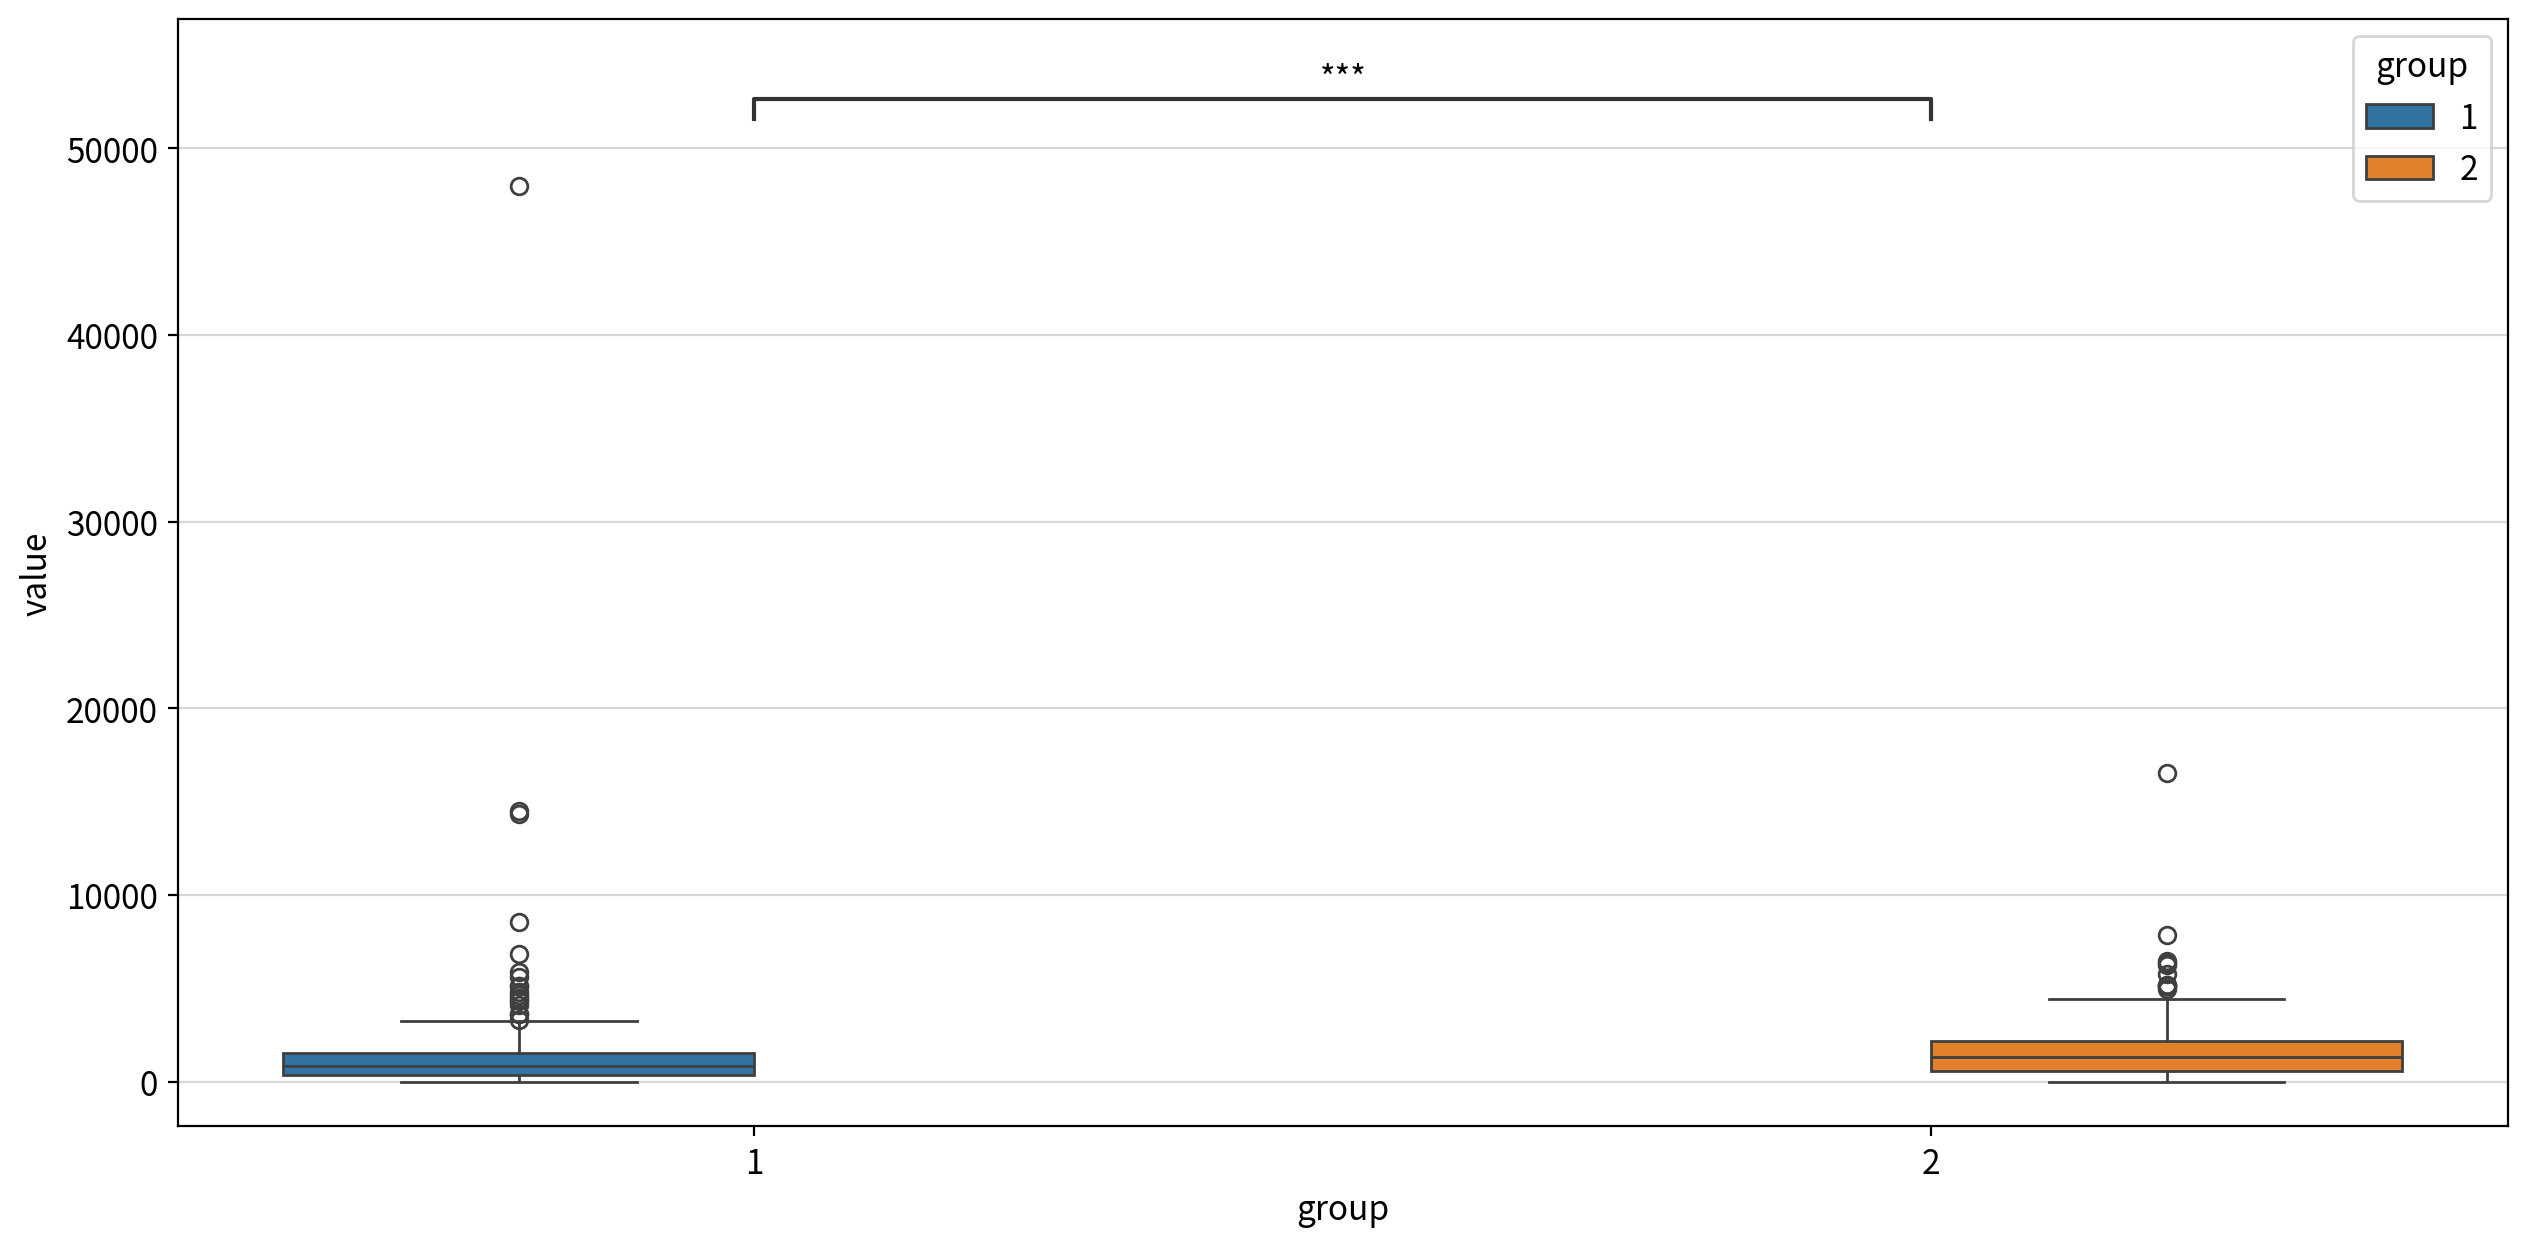

statistic  p-value  significant result  \
test                alternative                                           
Mann-Whitney U test two-sided      16848.5   0.0005         True  1 ≠ 2   
                    less           16848.5   0.0003         True  1 < 2   
                    greater        16848.5   0.9997        False  1 ≤ 2   

                                 Rank-Biserial  
test                alternative                 
Mann-Whitney U test two-sided              0.2  
                    less                   0.2  
                    greater                0.2

집단별 평균값·중앙값


,mean,median
Channel,,
1,1415.956376,821.0
2,1753.436620,1350.0


In [24]:
for n in num_cols:
    display(Markdown(f'#### > {target}({column_means[target]}) → {n}'))

    wide_df = my_prep.long2wide(drop_df, hue=target, values=n)
    a = my_stats.test_independent(wide_df, group1=wide_df.columns[0], 
                                        group2=wide_df.columns[1])

    d = drop_df['Channel'].value_counts()

    a['Rank-Biserial'] = round(abs((2 * a['statistic']) / ((d.iloc[0]) * (d.iloc[1])) - 1), 2)
    display(a)
    
    print('집단별 평균값·중앙값')
    display(drop_df[[target,n]].groupby(target)[n].agg(['mean', 'median']))

### 🔍 이변량 분석 해석

| 변수 | 검정 | p-value | 판단 | 방향(중앙값) | 평균(참고) | ｜Rank-Biserial｜ |
|---|---|---|---|---|---|---|
| `Fresh` | Mann-Whitney U test | 0.0002(양측) | **차이 있음** | 채널1(9,581.5) > 채널2(5,993.5) | 13,475.56 / 8,904.32 | 0.22 |
| `Milk` | Mann-Whitney U test | < 0.0001(양측) | **차이 있음** | 채널1(2,157) < 채널2(7,812) | 3,451.72 / 10,716.50 | 0.76 |
| `Grocery` | Mann-Whitney U test | < 0.0001(양측) | **차이 있음** | 채널1(2,684) < 채널2(12,390) | 3,962.14 / 16,322.85 | 0.88 |
| `Frozen` | Mann-Whitney U test | < 0.0001(양측) | **차이 있음** | 채널1(2,057.5) > 채널2(1,081) | 3,748.25 / 1,652.61 | 0.29 |
| `Detergents_Paper` | Mann-Whitney U test | < 0.0001(양측) | **차이 있음** | 채널1(385.5) < 채널2(5,614.5) | 790.56 / 7,269.51 | 0.92 |
| `Delicassen` | Mann-Whitney U test | 0.0005(양측) | **차이 있음** | 채널1(821) < 채널2(1,350) | 1,415.96 / 1,753.44 | 0.20 |

- Mann-Whitney는 값을 순위로 비교하는 검정이므로 방향은 **중앙값**으로 판단한다. 평균은 소수 고액 고객이 끌어올린 값이라 참고로만 적는다.
  
- 명목형 종속변수와 연속형 독립변수들 간의 상관관계는 Rank-Biserial(순위 이분 상관)으로 효과크기를 확인한다.

- 종속변수 `Channel` 과 연속형 독립변수들은 모두 유의미한 차이가 있는 것으로 나타났다. 
- `Channel: 1` 고객은 `Fresh`와 `Frozen` 구매액이 상대적으로 높은 반면, <br> `Channel: 2` 고객은 `Milk`, `Grocery`, `Detergents_Paper`, `Delicassen` 구매액이 상대적으로 높게 나타난다.  <br>
이는 두 채널 고객이 서로 다른 상품 구매 패턴을 가지고 있으며, 품목별 소비 성향이 고객 채널을 구분하는 주요 기준이 될 수 있음을 의미한다.
- 모든 연속형 변수는 정규성 미충족으로, Mann-Whitney U test 로 진행한다.
  - 검정 결과는 p < 0.05 이므로, 명목형 종속변수와 각각의 연속형 독립변수는 두 집단 간의 차이가 유의하므로, 변수 채택이 가능하다.
- |Rank-Biserial| 기준으로 `Detergents_Paper`(0.92), `Grocery`(0.88), `Milk`(0.76)는 채널을 강하게 구분하는 변수이고, `Frozen`(0.29), `Fresh`(0.22), `Delicassen`(0.20)은 판별력이 약한 보조 변수이다.

### 4) 다변량 분석

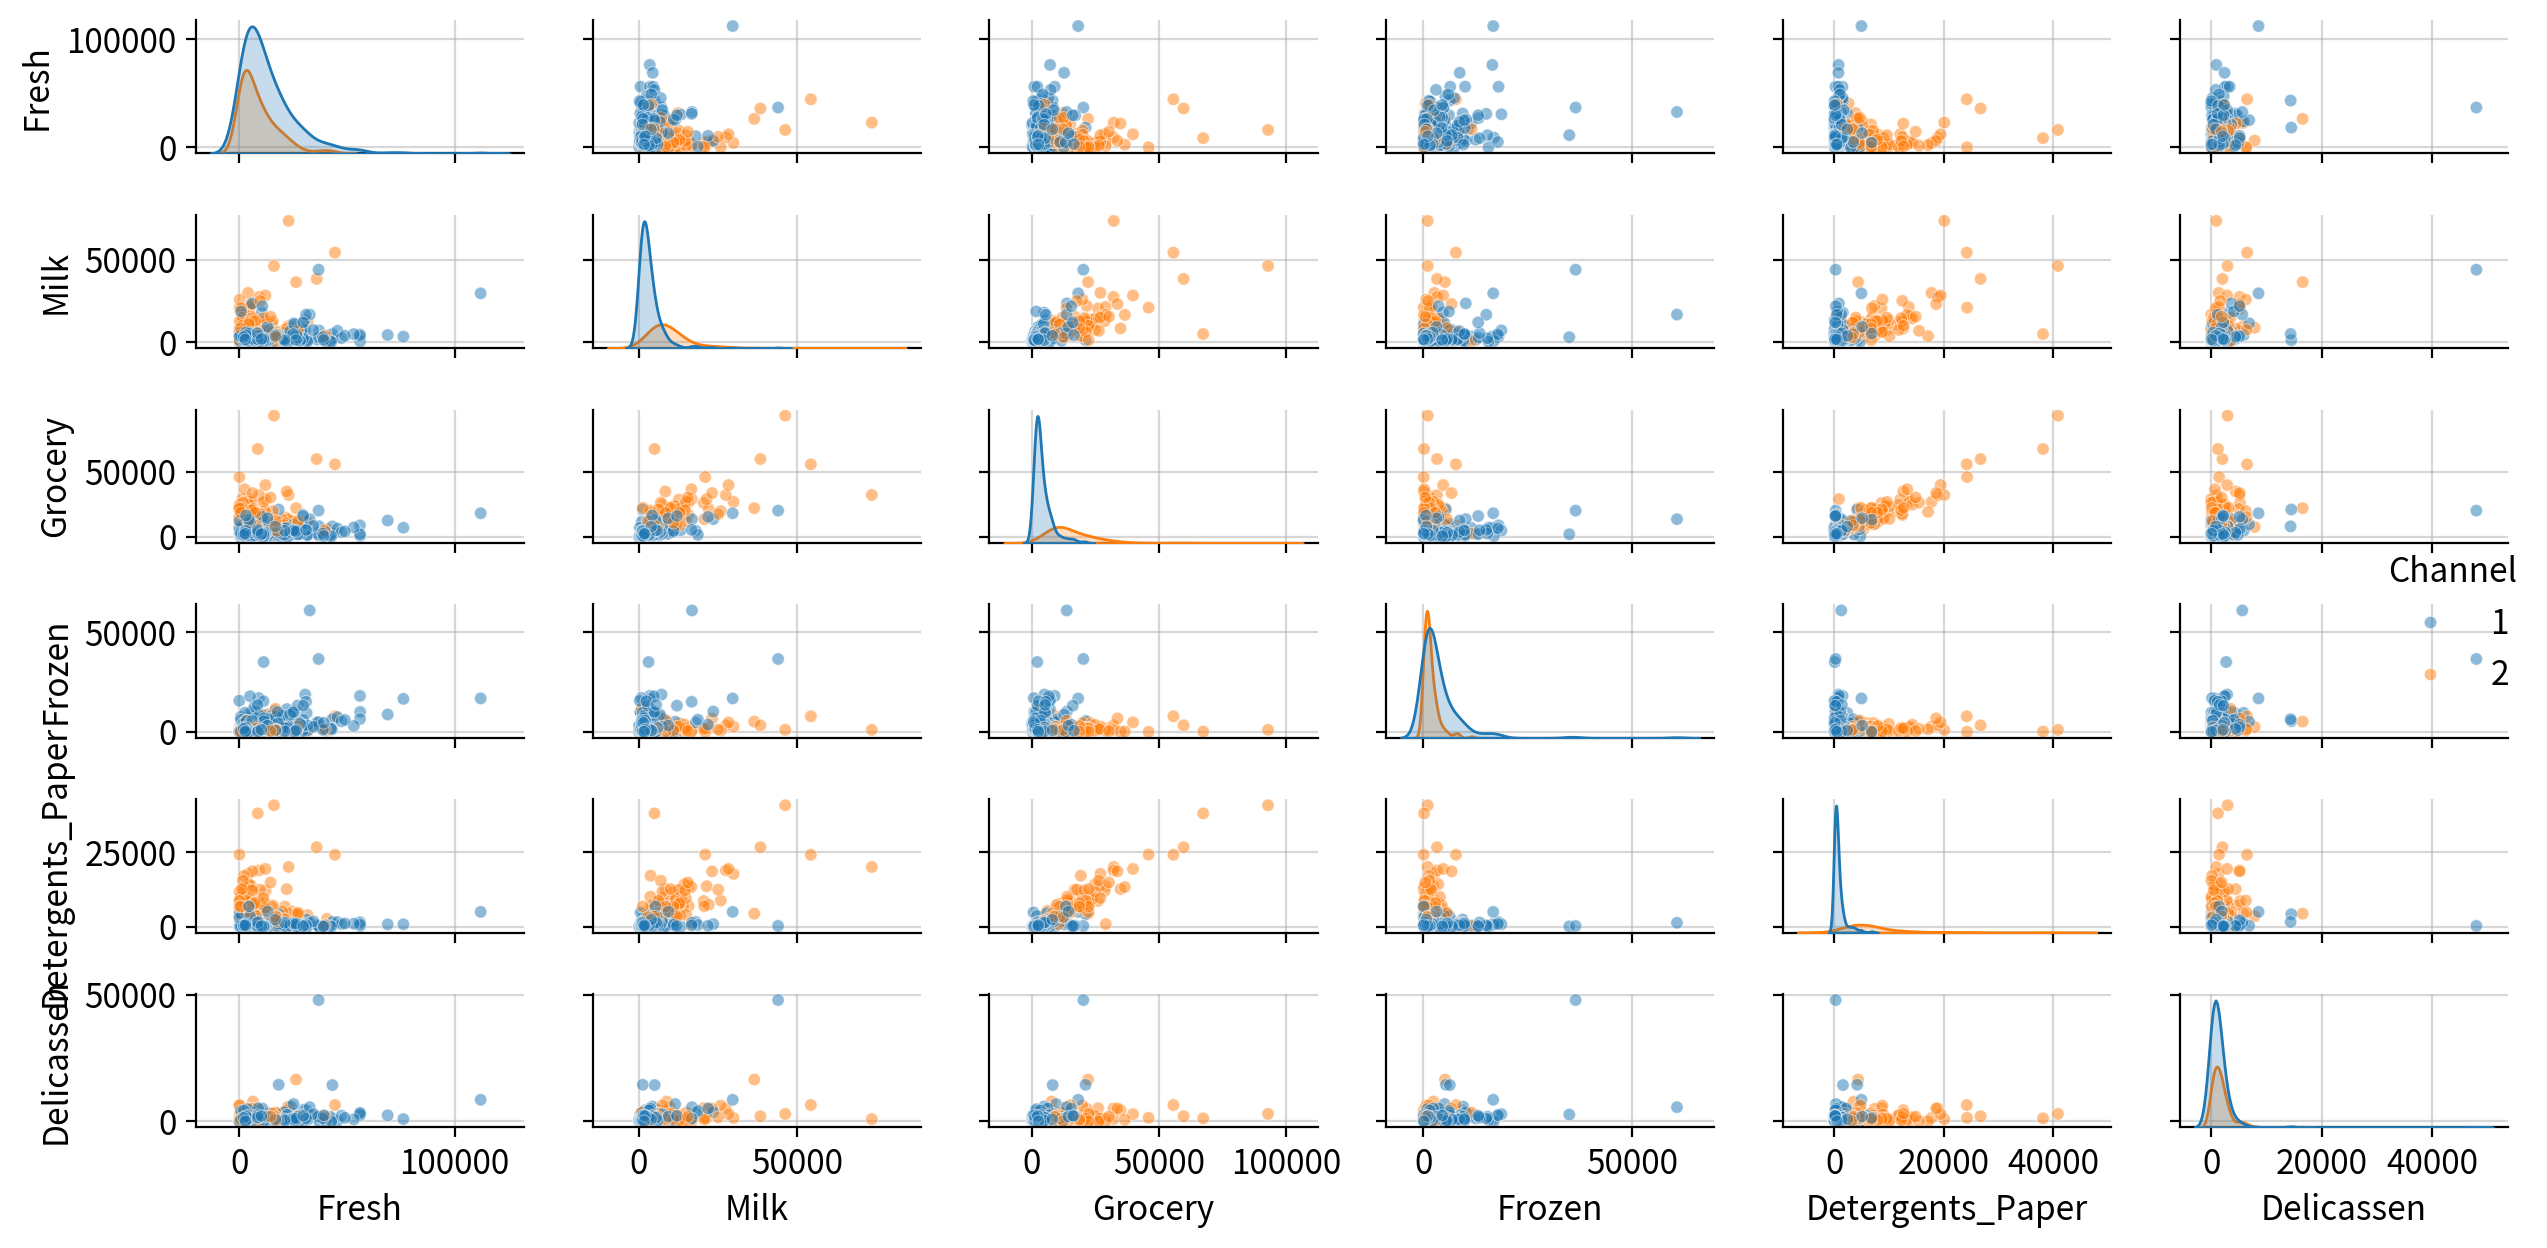

In [25]:
my_plot.pairplot(drop_df, num_cols, hue='Channel',scatter_alpha=0.5, diag_kind='kde')

In [26]:
corr_1 = drop_df[drop_df['Channel'] == 1]
corr_2 = drop_df[drop_df['Channel'] == 2]

In [27]:
print('Channel 1')
corr_1_1 = my_stats.multi_correlation(corr_1, columns=num_cols, plot=False)
display(my_stats.correlation_summary(corr_1_1))
display(corr_1_1)

Channel 1


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Fresh,1.000,0.070,0.084,0.381,-0.027,0.288
Milk,0.070,1.000,0.581,0.060,0.404,0.387
Grocery,0.084,0.581,1.000,0.017,0.526,0.322
Frozen,0.381,0.060,0.017,1.000,-0.010,0.301
Detergents_Paper,-0.027,0.404,0.526,-0.010,1.000,0.114
Delicassen,0.288,0.387,0.322,0.301,0.114,1.000


,max-y,max-coef,count,columns
x,,,,
Grocery,Milk,0.5806,0,-
Milk,Grocery,0.5806,0,-
Detergents_Paper,Grocery,0.5258,0,-
Delicassen,Milk,0.3867,0,-
Fresh,Frozen,0.3806,0,-
Frozen,Fresh,0.3806,0,-


method    coef strength  significant  \
x                y                                                          
Fresh            Milk              Spearman  0.0696       약함        False   
                 Grocery           Spearman  0.0843       약함        False   
                 Frozen            Spearman  0.3806       중간         True   
                 Detergents_Paper  Spearman -0.0269       약함        False   
                 Delicassen        Spearman  0.2881       약함         True   
Milk             Grocery           Spearman  0.5806       중간         True   
                 Frozen            Spearman  0.0603       약함        False   
                 Detergents_Paper  Spearman  0.4038       중간         True   
                 Delicassen        Spearman  0.3867       중간         True   
Grocery          Frozen            Spearman  0.0172       약함        False   
                 Detergents_Paper  Spearman  0.5258       중간         True   
                 Delicassen        Spearman  0.3217       중간         True   
Frozen           Detergents_Paper  Spearman -0.0099       약함        False   
                 Delicassen        Spearman  0.3011       중간         True   
Detergents_Paper Delicassen        Spearman  0.1139       약함         True   

                                   normality  normality_y  linearity  \
x                y                                                     
Fresh            Milk                  False        False      False   
                 Grocery               False        False      False   
                 Frozen                False        False       True   
                 Detergents_Paper      False        False      False   
                 Delicassen            False        False       True   
Milk             Grocery               False        False      False   
                 Frozen                False        False      False   
                 Detergents_Paper      False        False      False   
                 Delicassen            False        False      False   
Grocery          Frozen                False        False      False   
                 Detergents_Paper      False        False      False   
                 Delicassen            False        False      False   
Frozen           Detergents_Paper      False        False       True   
                 Delicassen            False        False       True   
Detergents_Paper Delicassen            False        False       True   

                                   influential_outlier  high_skew  
x                y                                                 
Fresh            Milk                             True       True  
                 Grocery                          True       True  
                 Frozen                          False       True  
                 Detergents_Paper                False       True  
                 Delicassen                      False       True  
Milk             Grocery                         False       True  
                 Frozen                           True       True  
                 Detergents_Paper                False       True  
                 Delicassen                       True       True  
Grocery          Frozen                           True       True  
                 Detergents_Paper                 True       True  
                 Delicassen                       True       True  
Frozen           Detergents_Paper                False       True  
                 Delicassen                       True       True  
Detergents_Paper Delicassen                      False       True

In [28]:
print('Channel 2')
corr_2_1 = my_stats.multi_correlation(corr_2, columns=num_cols, plot=False)
display(my_stats.correlation_summary(corr_2_1))

Channel 2


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Fresh,1.000,-0.054,-0.212,0.310,-0.259,0.237
Milk,-0.054,1.000,0.672,0.135,0.571,0.209
Grocery,-0.212,0.672,1.000,0.011,0.854,0.074
Frozen,0.310,0.135,0.011,1.000,-0.019,0.249
Detergents_Paper,-0.259,0.571,0.854,-0.019,1.000,-0.008
Delicassen,0.237,0.209,0.074,0.249,-0.008,1.000


,max-y,max-coef,count,columns
x,,,,
Detergents_Paper,Grocery,0.8544,1,Grocery
Grocery,Detergents_Paper,0.8544,1,Detergents_Paper
Milk,Grocery,0.6721,0,-
Fresh,Frozen,0.3103,0,-
Frozen,Fresh,0.3103,0,-
Delicassen,Frozen,0.2486,0,-


In [29]:
# 전체 고객 기준 상관계수 (Spearman: 순위 기반으로 이상치에 덜 민감 / Pearson: 비교용)
print('Spearman')
display(drop_df[num_cols].corr(method='spearman').round(3))
print('Pearson')
display(drop_df[num_cols].corr(method='pearson').round(3))

Spearman


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Fresh,1.000,-0.084,-0.120,0.384,-0.198,0.238
Milk,-0.084,1.000,0.773,-0.093,0.680,0.373
Grocery,-0.120,0.773,1.000,-0.169,0.801,0.304
Frozen,0.384,-0.093,-0.169,1.000,-0.207,0.233
Detergents_Paper,-0.198,0.680,0.801,-0.207,1.000,0.183
Delicassen,0.238,0.373,0.304,0.233,0.183,1.000


Pearson


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Fresh,1.000,0.101,-0.012,0.346,-0.102,0.245
Milk,0.101,1.000,0.728,0.124,0.662,0.406
Grocery,-0.012,0.728,1.000,-0.040,0.925,0.205
Frozen,0.346,0.124,-0.040,1.000,-0.132,0.391
Detergents_Paper,-0.102,0.662,0.925,-0.132,1.000,0.069
Delicassen,0.245,0.406,0.205,0.391,0.069,1.000


In [30]:
my_prep.reduce_vif(drop_df)


완료! 남은 변수: ['Delicassen', 'Detergents_Paper', 'Fresh', 'Frozen', 'Grocery', 'Milk']
최대VIF = 8.79


,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,12669,9656,7561,214,2674,1338
1,2,7057,9810,9568,1762,3293,1776
2,2,6353,8808,7684,2405,3516,7844
3,1,13265,1196,4221,6404,507,1788
4,2,22615,5410,7198,3915,1777,5185
...,...,...,...,...,...,...,...
435,1,29703,12051,16027,13135,182,2204
436,1,39228,1431,764,4510,93,2346
437,2,14531,15488,30243,437,14841,1867
438,1,10290,1981,2232,1038,168,2125


변수 6개 -> 주성분 3개 (누적 설명력 84.8%)


,PC1,PC2,PC3
Features,,,
Fresh,0.042884,0.527932,0.812257
Milk,0.545118,0.083168,-0.060388
Grocery,0.579256,-0.146088,0.108384
Frozen,0.051189,0.611278,-0.178386
Detergents_Paper,0.548640,-0.255233,0.136192
Delicassen,0.248682,0.504207,-0.523904
[설명력],0.440829,0.283764,0.123344
[누적 설명력],0.440829,0.724593,0.847937


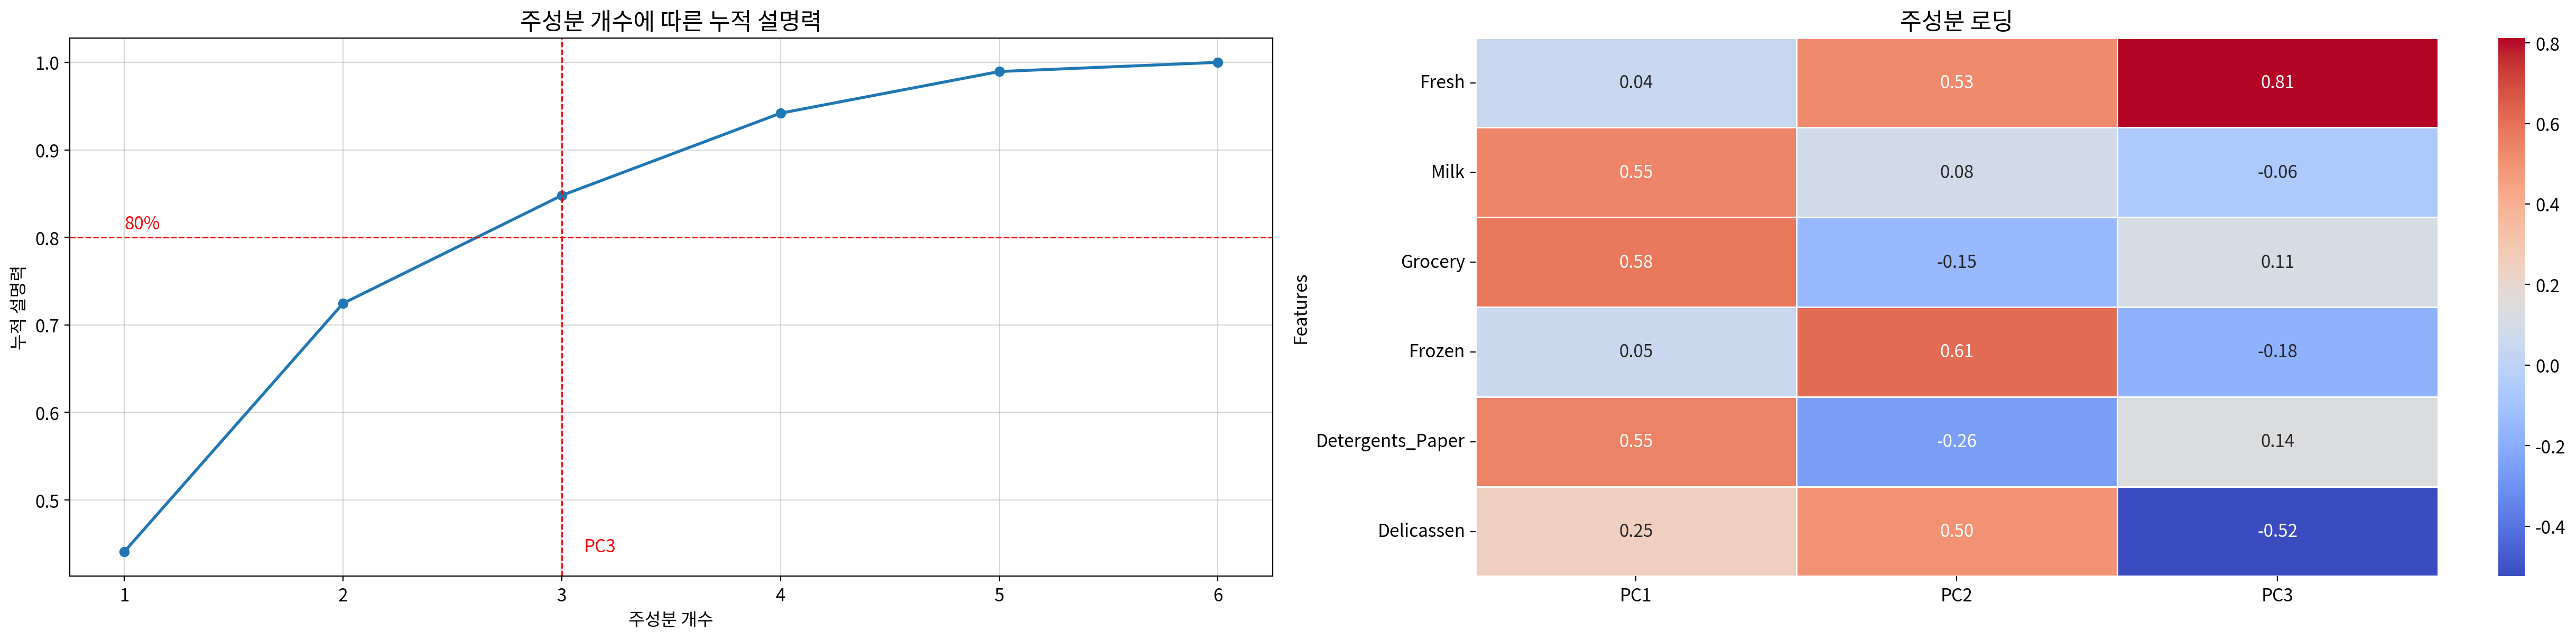

,PC1,PC2,PC3
0,0.193291,-0.305100,0.140878
1,0.434420,-0.328413,-0.319007
2,0.811143,0.815096,-1.523416
3,-0.778648,0.652754,-0.163012
4,0.166287,1.271434,-0.066279
...,...,...,...
435,0.870602,2.220845,0.605500
436,-0.902520,1.676916,1.418980
437,3.465704,-1.039838,0.713161
438,-0.918023,-0.030047,-0.258408


In [31]:
m = my_prep.pca(drop_df)
m

### 다변량 분석

- `Milk`, `Grocery`, `Detergents_Paper` 사이에는 높은 양의 상관관계가 확인되었다. (전체 고객 기준 Spearman 상관계수)
  - `Grocery`–`Detergents_Paper`: **0.801**
  - `Milk`–`Grocery`: **0.773**
  - `Milk`–`Detergents_Paper`: **0.680**
  - Pearson 기준으로는 `Grocery`–`Detergents_Paper`가 **0.925**로 더 높다. 고액 고객이 선형 상관을 키운 것으로, 이상치에 덜 민감한 Spearman 값을 기준으로 해석한다.
  - 채널별로 나눠 보면 Retail(Channel 2)에서는 `Grocery`–`Detergents_Paper`가 **0.854**로 전체(0.801)보다 강하고, Horeca(Channel 1)에서는 가장 높은 상관이 `Milk`–`Grocery` **0.581**로 중간 수준이다. 즉 세 품목의 동반 구매는 Retail 고객에서 특히 강하다.
  - 이는 세 변수가 서로 유사한 구매규모정보를 중복해서 포함하고 있음을 의미한다. 따라서 모든 변수를 거리 기반 분석에 사용할 경우 특정 구매 축이 과도하게 반영될 수 있다.
- 반면 `Fresh`, `Frozen`, `Delicassen`은 위 세 변수와 상대적으로 다른 구매 패턴을 보이며, 고객의 구매 성향을 구분하는 별도의 축을 형성할 가능성이 있다.
- 채널별 산점도에서도 `Milk`·`Grocery`·`Detergents_Paper` 중심의 구매 패턴과 `Fresh`·`Frozen` 중심의 구매 패턴이 구분되는 경향이 나타난다. 이는 고객 채널이 단일 품목이 아니라 여러 품목의 조합된 구매 패턴으로 설명될 수 있음을 의미한다.
- 다중공선성 검사 결과 최대 VIF가 8.79로 임계값(**VIF ≥ 10**)을 넘는 변수가 없으므로 모든 변수를 채택하여 분석을 시작한다.
- 따라서 변수 간 중복 정보를 줄이고 고객의 종합적인 구매 성향을 파악하기 위해 PCA를 적용한다.
- 주성분 3개로 84.8% 설명한다.
- PC3의 정체: Fresh(0.812)가 압도적, Delicassen(-0.524)이 반대 방향 → "신선식품 중심 vs 즉석/가공식품 중심"이라는 새로운 축이 생긴 것이다.
- PC1=Milk·Grocery·Detergents_Paper 중심이다.
- PC2=Fresh·Frozen·Delicassen 중심이다.
- 현재 EDA의 PCA는 표준화만 하고 왜도 보정(로그/Yeo-Johnson)은 하지 않은 상태라 극단값의 영향을 받는다. 최종 군집분석에서는 Yeo-Johnson 변환과 표준화를 거친 PCA 결과를 기준으로 해석한다.

## #3. 모델링

### 1) 데이터 전처리

#### 1-1 로그 변환 및 Yeo-Johnson 변환

In [32]:
# log 변환 (연속형 컬럼)
log_df = my_prep.log_transform(drop_df, log_columns=num_cols)
log_df.head()

컬럼        꼬리방향      변환식                   역변환식                                  왜도
----------------------------------------------------------------------------------------
Fresh     우측 꼬리     log(x)                exp(y)                   2.55 -> -1.62
Milk      우측 꼬리     log(x)                exp(y)                   4.04 -> -0.23
Grocery   우측 꼬리     log(x)                exp(y)                   3.58 -> -0.74
Frozen    우측 꼬리     log(x)                exp(y)                   5.89 -> -0.36
Detergents_Paper우측 꼬리     log(x)                exp(y)                   3.62 -> -0.27
Delicassen우측 꼬리     log(x)                exp(y)                  11.11 -> -1.17


,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,9.446913,9.175335,8.930759,5.365976,7.891331,7.198931
1,2,8.861775,9.191158,9.166179,7.474205,8.099554,7.482119
2,2,8.756682,9.083416,8.946896,7.785305,8.165079,8.967504
3,1,9.492884,7.086738,8.347827,8.764678,6.228511,7.488853
4,2,10.026369,8.596004,8.881558,8.272571,7.482682,8.553525


**결과**
- 로그변환 후 왜도가 `Fresh`(-1.62), `Delicassen`(-1.17)로 과보정되었다. 이는 하한값 3에 의한 하한 왜곡이 일어났음을 보여준다.
- 이로 인해 Yeo-Johnson 변환을 적용한다.

In [33]:
from sklearn.preprocessing import PowerTransformer
from scipy.stats import skew

# Yeo-Johnson 변환
# standardize=False로 설정하여 이후 별도로 표준화
yj = PowerTransformer(method='yeo-johnson', standardize=False)

yj_df = drop_df.copy()
yj_df[num_cols] = yj.fit_transform(drop_df[num_cols])

# 변환 전후 왜도 비교
skew_comparison = pd.DataFrame({
    '변환 전 왜도': drop_df[num_cols].apply(skew),
    'Yeo-Johnson 변환 후 왜도': yj_df[num_cols].apply(skew)
})

display(skew_comparison)


,변환 전 왜도,Yeo-Johnson 변환 후 왜도
Fresh,2.552583,-0.041474
Milk,4.039922,0.001385
Grocery,3.575187,0.031052
Frozen,5.887826,0.002632
Detergents_Paper,3.619458,-0.016825
Delicassen,11.113534,0.095923


In [34]:
# 스케일링 (연속형 컬럼)
scaling_df = my_prep.scaling(yj_df, columns=num_cols)
scaling_df.head()

StandardScaler 적용 (6개 컬럼)
컬럼                            변환 전                  변환 후
--------------------------------------------------------
Fresh              1.71 ~ 100.76          -2.59 ~ 3.39
Milk                4.61 ~ 16.62          -3.37 ~ 3.15
Grocery             1.51 ~ 25.20          -4.40 ~ 3.27
Frozen              3.77 ~ 18.59          -2.74 ~ 3.41
Detergents_Paper        1.44 ~ 14.45          -2.80 ~ 2.46
Delicassen          1.58 ~ 34.39          -2.90 ~ 4.95


,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,0.413012,0.979454,0.394901,-1.457973,0.620530,0.338074
1,2,-0.110911,0.995243,0.628376,0.080081,0.751556,0.602222
2,2,-0.195814,0.888063,0.410688,0.332499,0.793104,2.240051
3,1,0.458126,-0.965336,-0.154740,1.173953,-0.372736,0.608674
4,2,1.028870,0.412660,0.346961,0.742061,0.367767,1.737333


In [35]:
sc_desc = my_qtcheck.numerical_summary(scaling_df)
sc_desc.T

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.0,440.0,440.0,440.0,440.0,440.0
mean,0.0,-0.0,0.0,-0.0,0.0,-0.0
std,1.001138,1.001138,1.001138,1.001138,1.001138,1.001138
min,-2.589651,-3.372439,-4.398854,-2.740748,-2.797946,-2.896435
25%,-0.704553,-0.748111,-0.742002,-0.585907,-0.752845,-0.629334
50%,0.046395,0.033999,-0.045526,-0.034279,-0.097551,0.050488
75%,0.708264,0.688256,0.73745,0.659396,0.862721,0.62584
max,3.393795,3.146213,3.268233,3.407522,2.461726,4.954018
rel_diff,1.0,1.0,-1.0,-1.0,-1.0,1.0
rdiff_flag,large_diff,large_diff,similar,similar,similar,large_diff


#### 해석

| 변수 | mean | std | min | max | skew | kurtosis |
|---|---|---|---|---|---|---|
| Fresh | 0.0 | 1.00 | -2.59 | 3.39 | -0.042 | -0.061 |
| Milk | 0.0 | 1.00 | -3.37 | 3.15 | 0.001 | 0.067 |
| Grocery | 0.0 | 1.00 | -4.40 | 3.27 | 0.031 | 0.468 |
| Frozen | 0.0 | 1.00 | -2.74 | 3.41 | 0.003 | 0.109 |
| Detergents_Paper | 0.0 | 1.00 | -2.80 | 2.46 | -0.017 | -0.558 |
| **Delicassen** | 0.0 | 1.00 | -2.90 | **4.95** | 0.096 | **1.680** |

- mean=0, std=1이 6개 변수 전부 정확히 일치한다. 이는 스케일링이 의도대로 적용되었음을 확인해 준다.
- log 변환 시 일부 변수(`Fresh`, `Delicassen`)의 왜도가 반대 방향으로 과보정되는 문제가 확인된다.
  - 이는 Yeo-Johnson 변환으로 왜도가 전부 ±0.1 이내로, log 변환(최대 -1.62) 대비 훨씬 안정적으로 개선됐다.
- `Delicassen`은 원래 왜도 11.15, 첨도 170.69로 6개 변수 중 가장 극단적이었던 변수로, 변환 후에도 완전한 정규분포가 안됐다.
  - 이는 군집분석에서 `Delicassen` 고액 고객이 별도의 소그룹으로 분리될 가능성을 시사한다.

### 2) PCA 차원축소

변수 간 상관관계를 정리하고, 여러 고객 특성을 소수의 주성분으로 축약한다.

- 시각화: biplot

> 누적 설명분산이 80% 이상이 되는 주성분 개수를 군집분석 입력 변수로 사용한다.



변수 6개 -> 주성분 3개 (누적 설명력 83.1%)


,PC1,PC2,PC3
Features,,,
Fresh,-0.091671,0.592753,0.726014
Milk,0.542534,0.117888,0.028984
Grocery,0.570812,-0.008730,0.144329
Frozen,-0.121867,0.596160,-0.146810
Detergents_Paper,0.545940,-0.104924,0.187729
Delicassen,0.241918,0.517933,-0.628043
[설명력],0.448889,0.280036,0.101868
[누적 설명력],0.448889,0.728925,0.830794


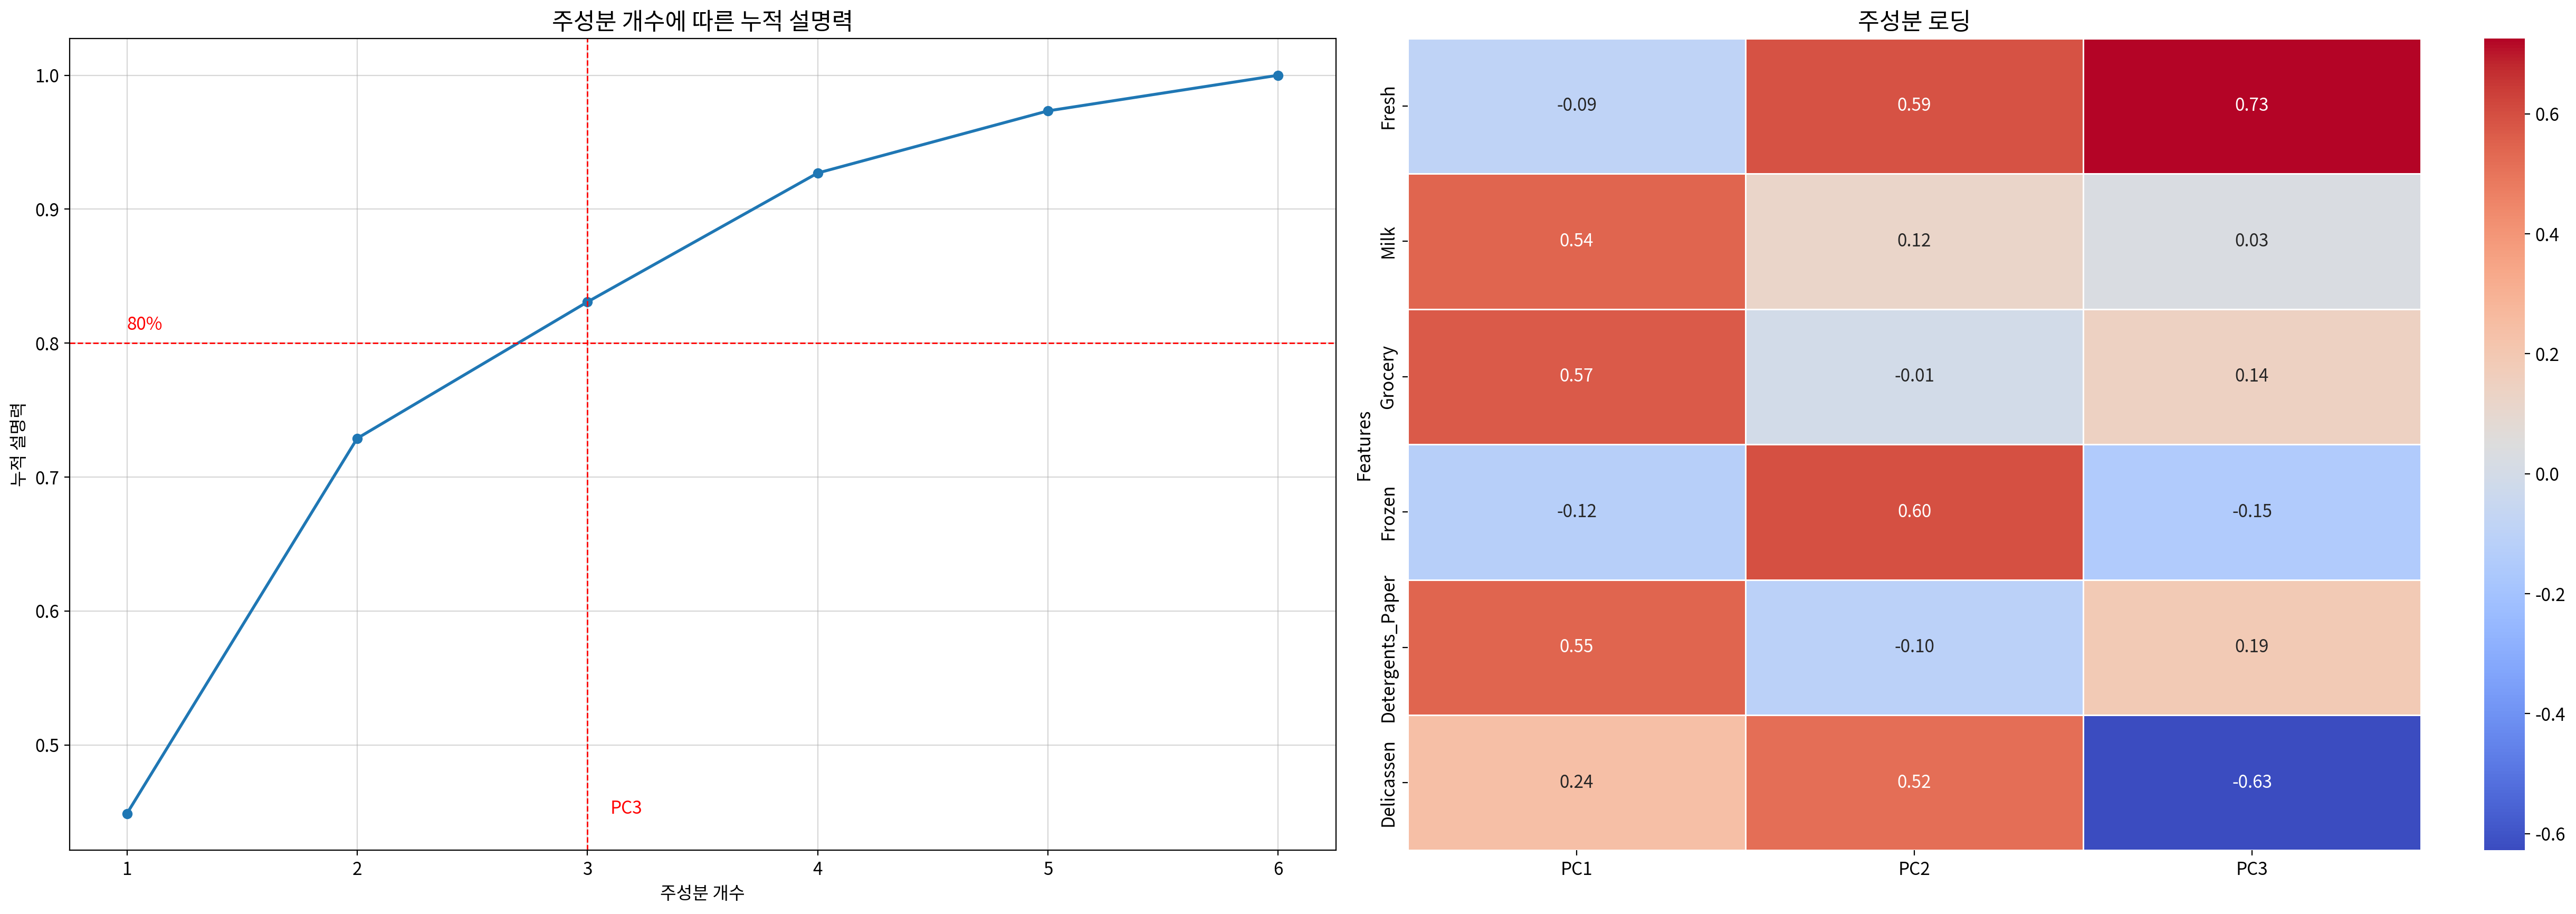

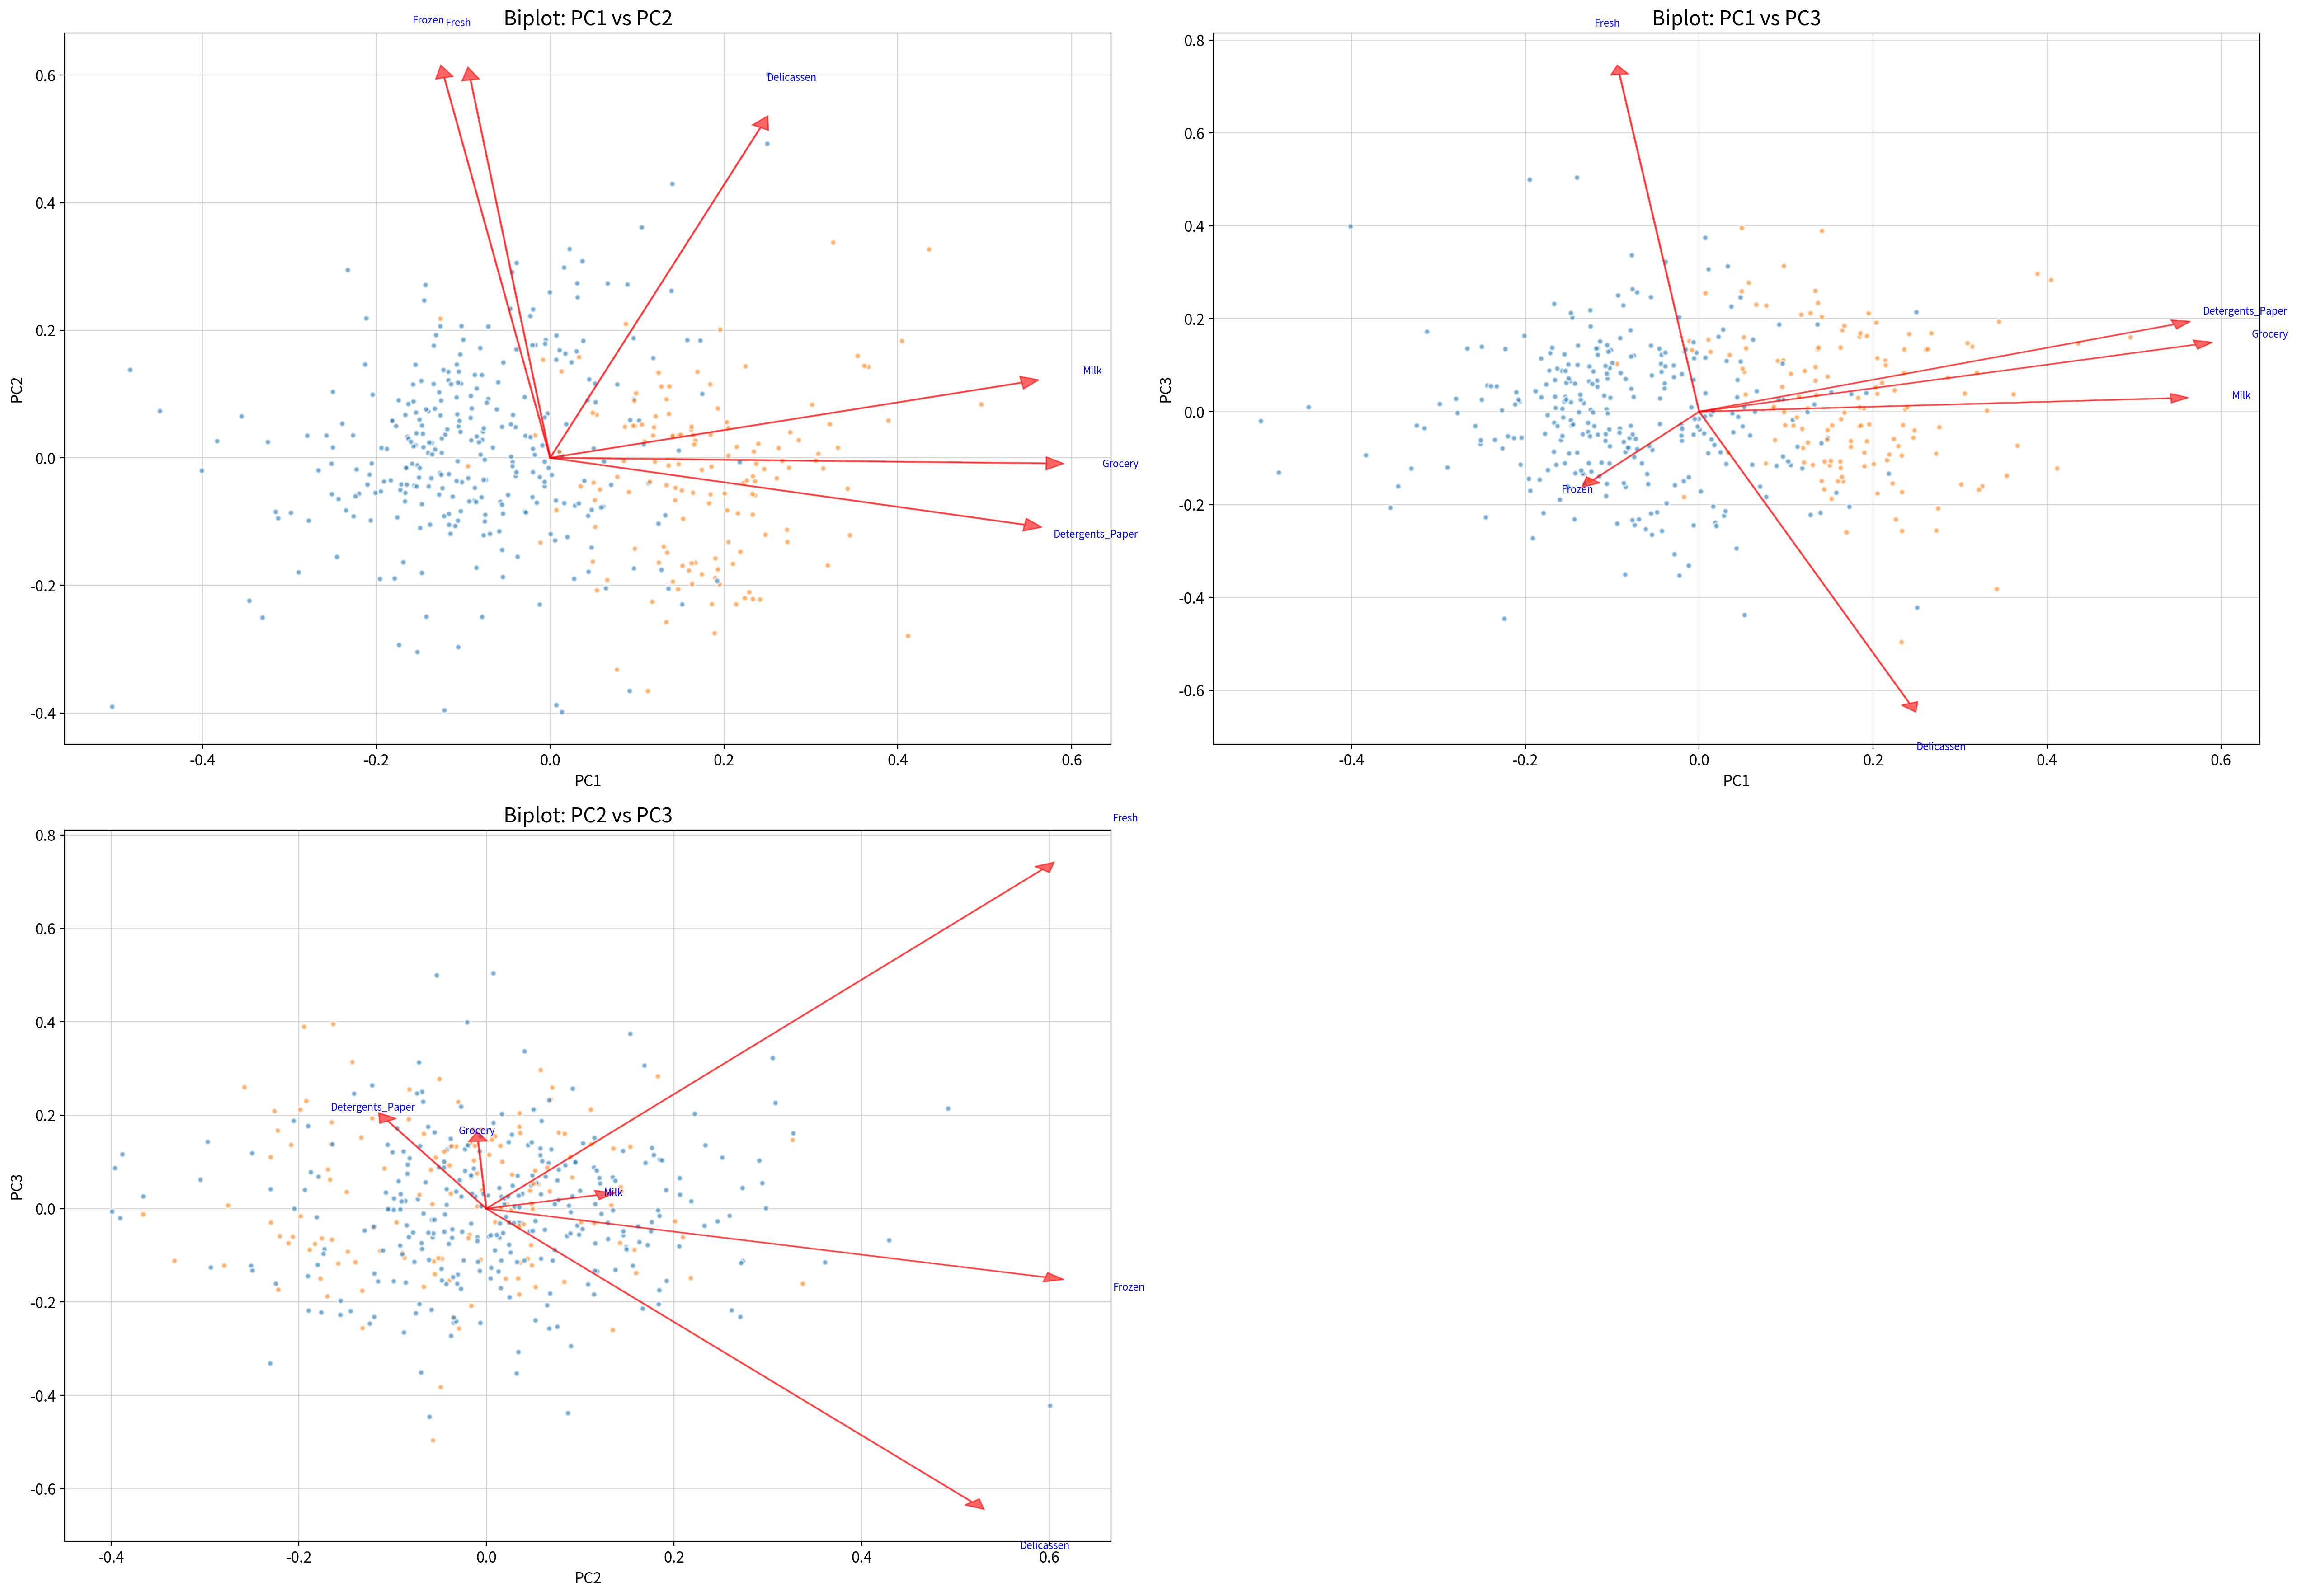

,PC1,PC2,PC3,Channel
0,1.317178,-0.402363,0.503448,2
1,1.455039,0.326894,-0.209873,2
2,1.668557,1.260240,-1.363923,2
3,-0.853361,1.213330,-0.342302,1
4,0.858253,1.959105,-0.322010,2
...,...,...,...,...
435,0.652173,2.552008,0.231097,1
436,-2.083018,2.042291,0.081474,1
437,3.038216,0.056982,0.773043,2
438,-1.015846,0.379728,-0.584062,1


In [36]:
pca_df = my_prep.pca(scaling_df, y=target, scale=None, biplot='all', width=1280, height=900)
display(pca_df)

#### 해석

| 주성분 | 설명력 | 누적 설명력 | 주요 구성 변수 |
|---|---|---|---|
| PC1 | 44.9% | 44.9% | Milk, Grocery, Detergents_Paper (식료품·유제품·세제/종이류 구매 축) |
| PC2 | 28.0% | 72.9% | Fresh, Frozen, Delicassen (신선·냉동·즉석/가공식품 구매 축) |
| PC3 | 10.2% | 83.1% | Fresh(+) vs Delicassen(-) (신선식품 vs 즉석/가공식품 축) |

- PCA는 채널 정보를 보지 않고 변수들의 흩어짐만 요약하므로, 주성분 이름은 채널(소매·요식업)이 아니라 **구성 변수 묶음**으로만 붙인다. PC1 적재량이 가장 큰 변수는 `Grocery`(0.571)이다.
- PC1만 쓰면 Fresh·Frozen 축(PC2)과 신선 vs 즉석식품 축(PC3)의 정보가 빠지므로, 이후 군집분석은 PC1~PC3를 함께 사용한다.

### 3) KMeans 군집분석

[엘보우] 최적의 k = 4


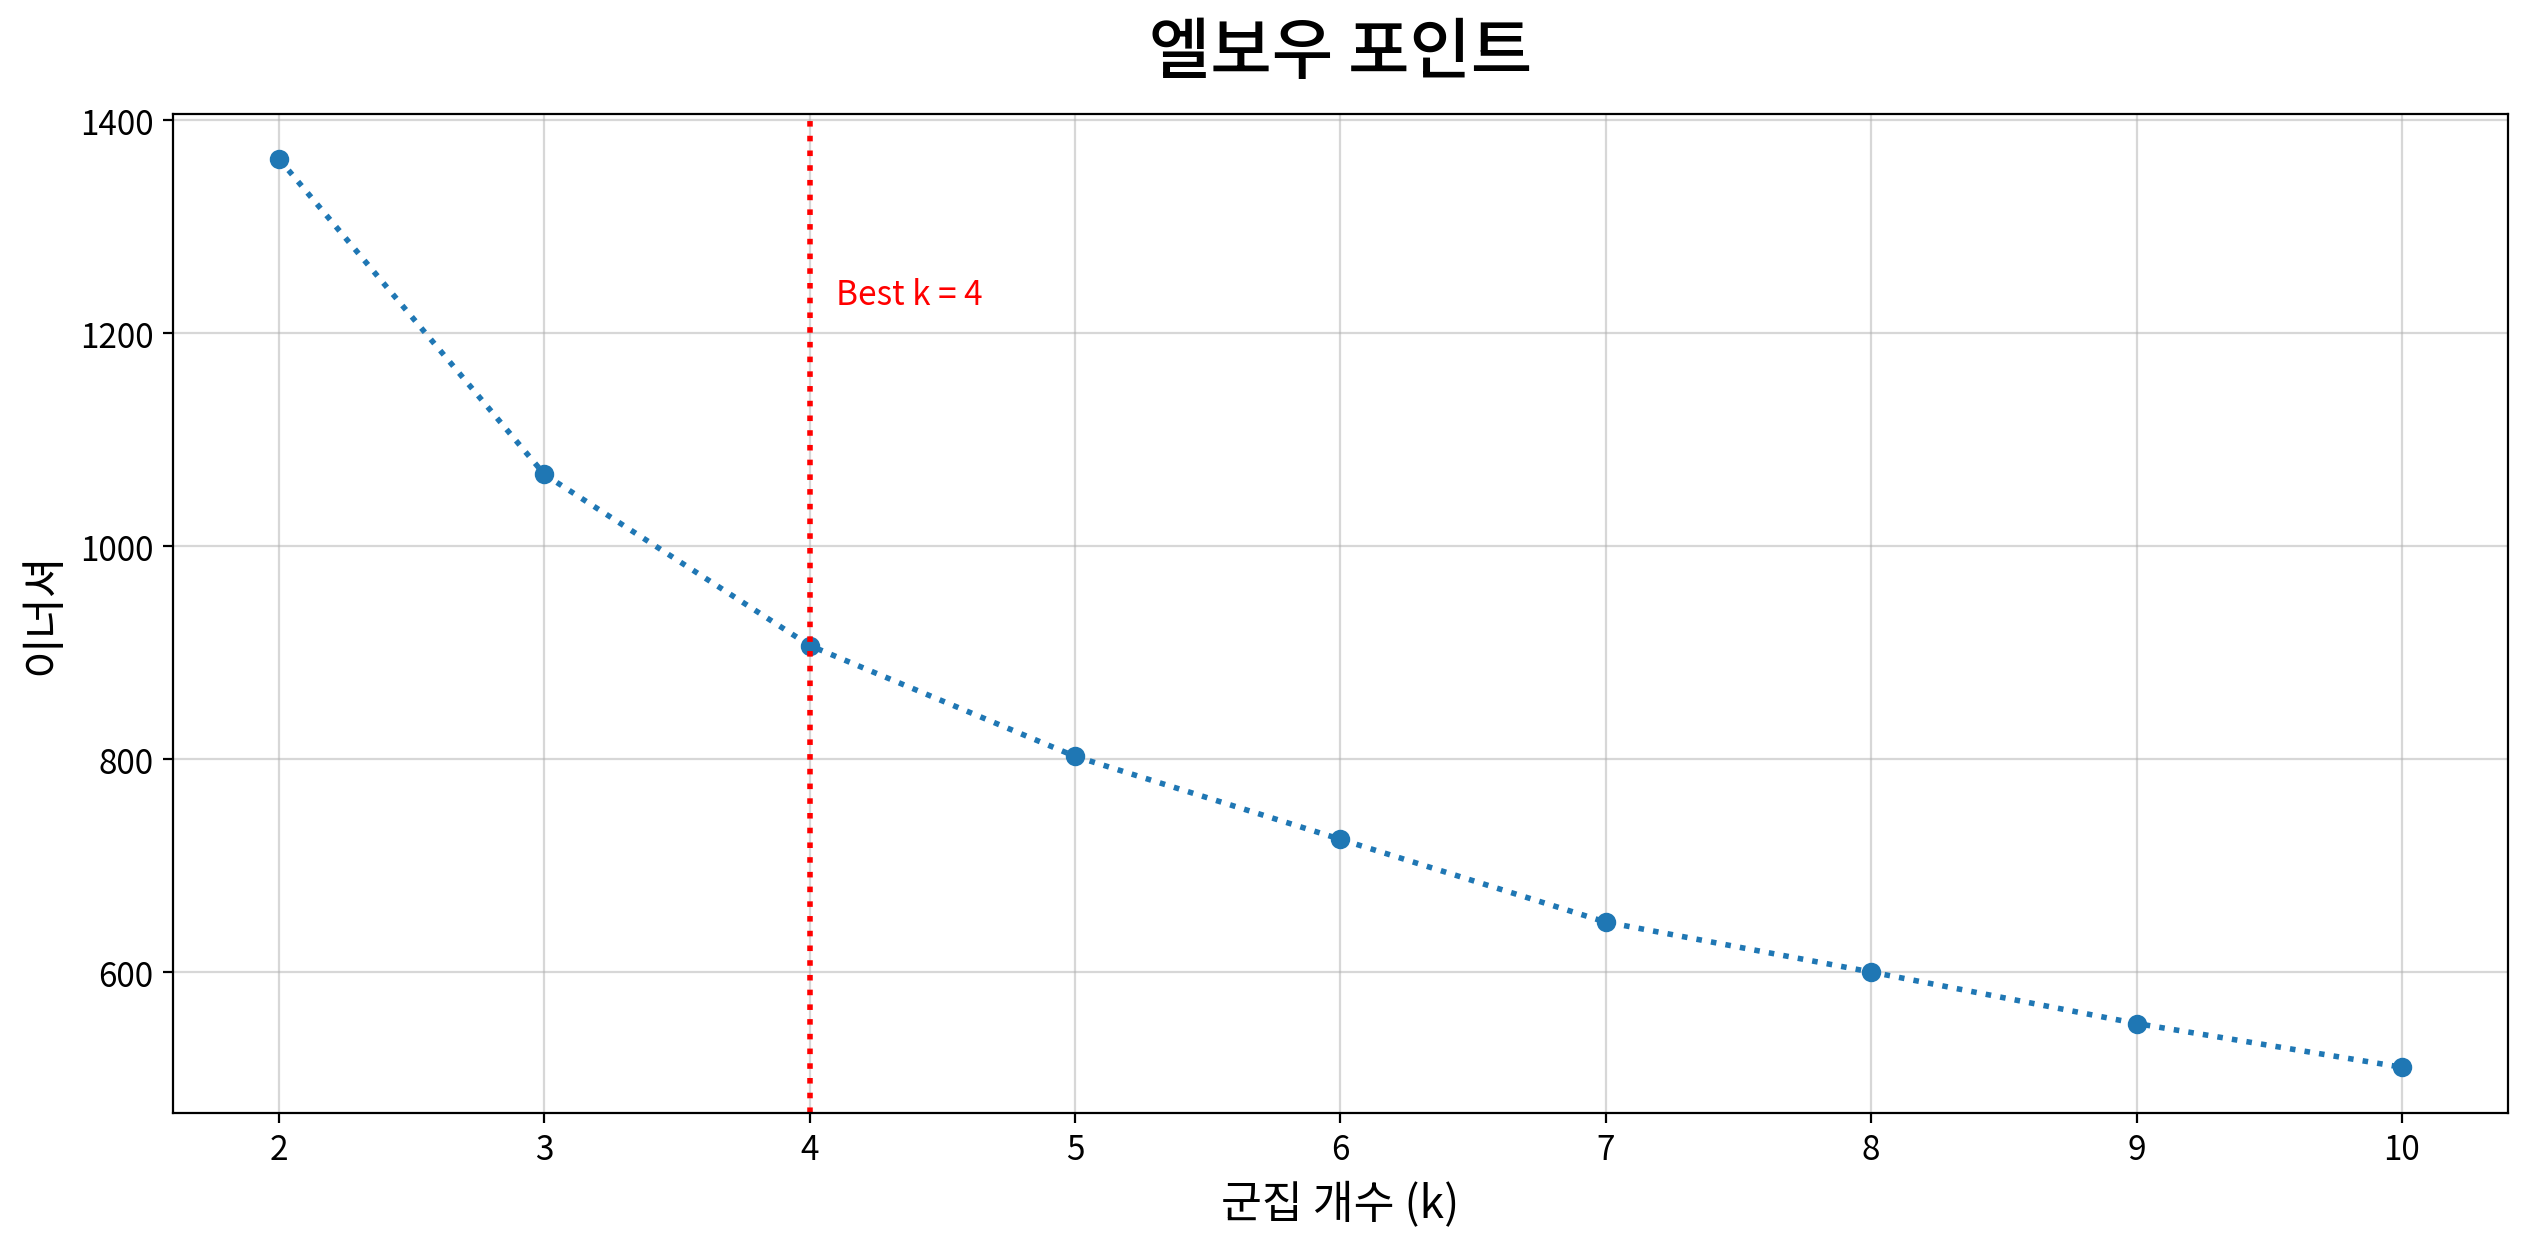

(np.int64(4),
     k        이너셔       감소량
 0   2  1363.5740       NaN
 1   3  1067.4727  296.1013
 2   4   906.8331  160.6397
 3   5   802.7631  104.0699
 4   6   724.8715   77.8916
 5   7   647.1483   77.7233
 6   8   600.2982   46.8501
 7   9   551.9646   48.3336
 8  10   510.8818   41.0828)

In [37]:
my_cluster.best_k_elbow(pca_df, scaling=None)

[실루엣] 균형지수 최대 → 최적의 k = 5(스코어 0.2536, 두께비 1.8947, 균형지수 0.8042)


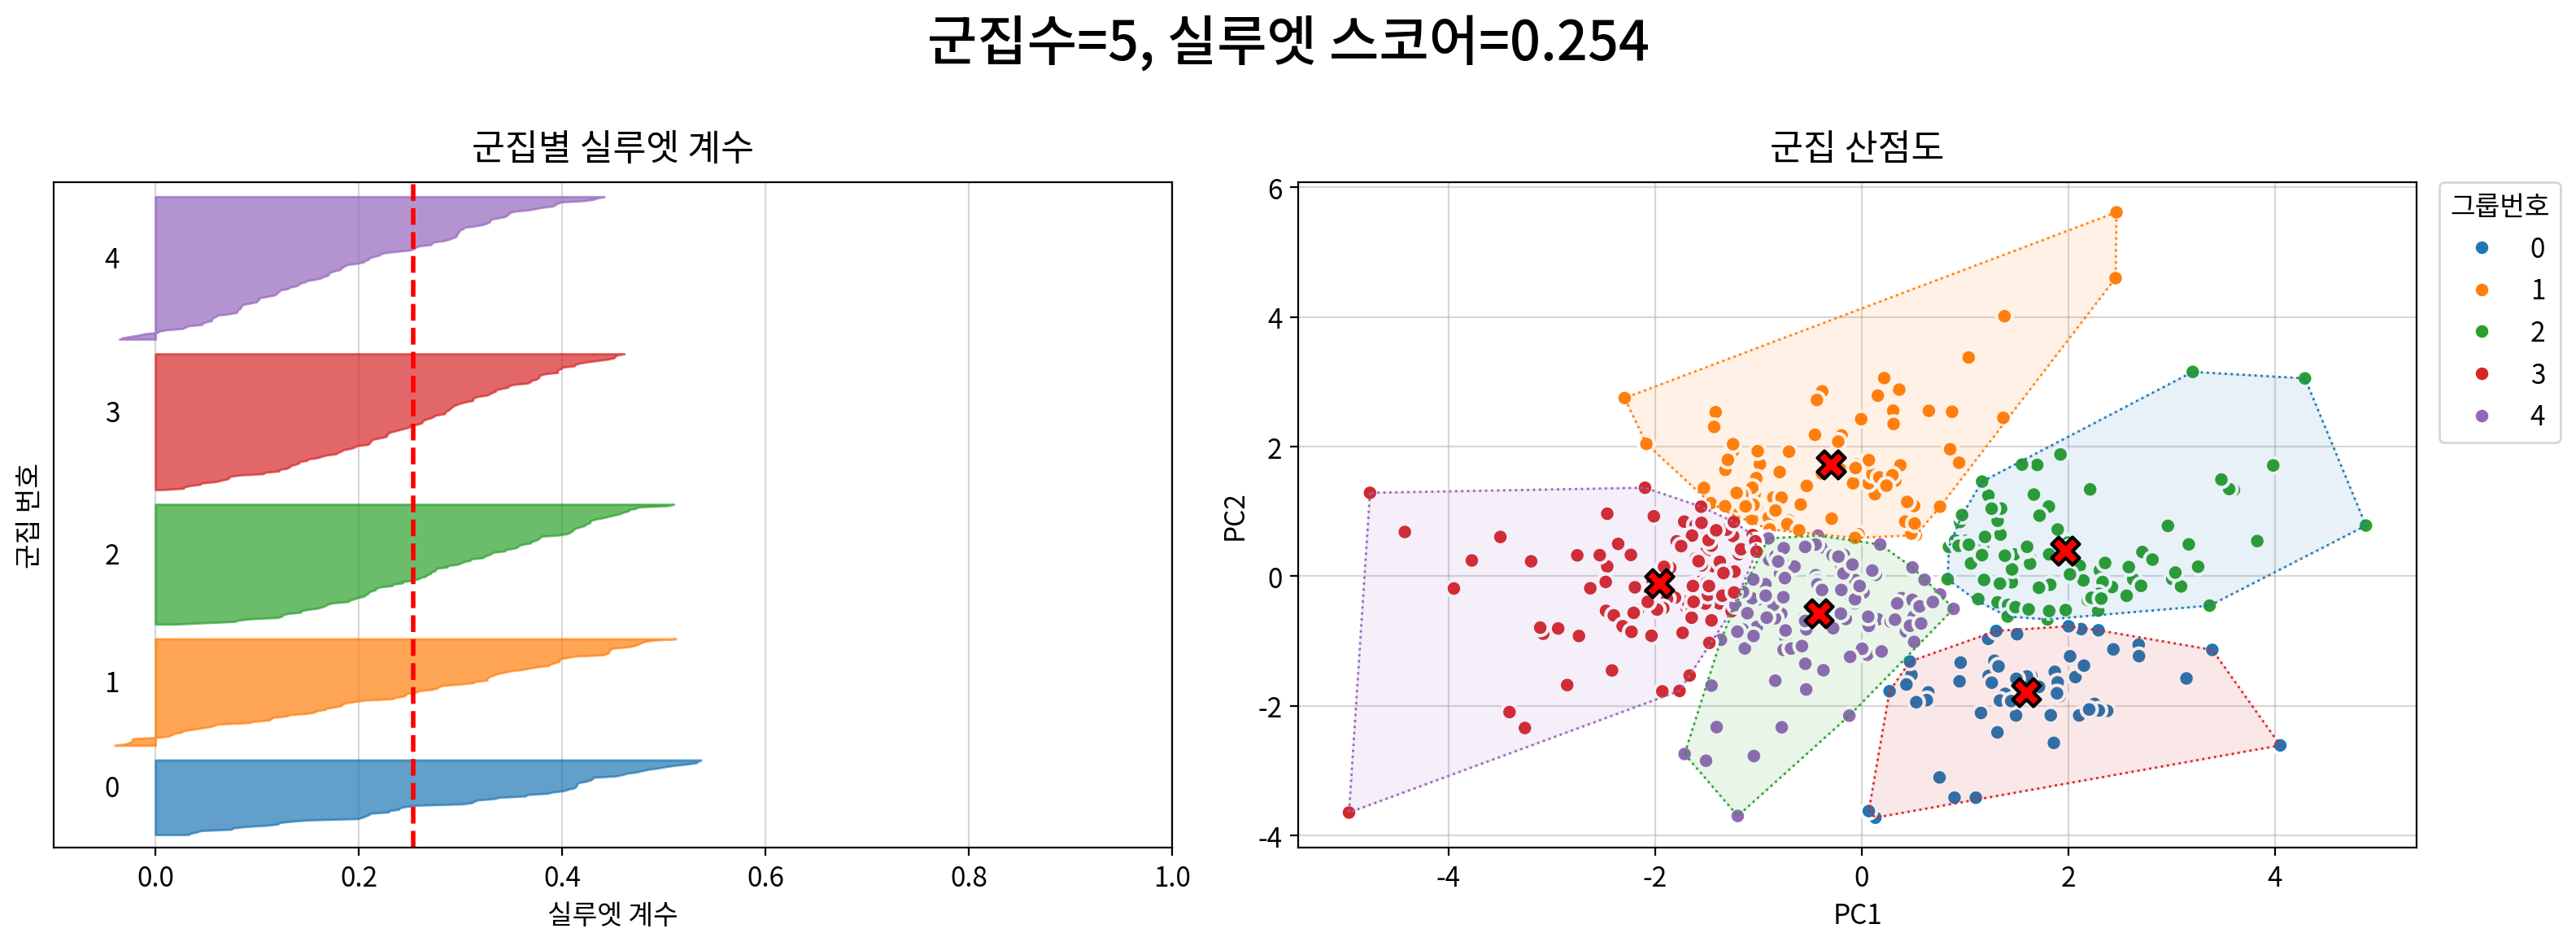

(5,
     k     스코어      전체면적      두께비  최소상대면적    균형지수
 0   2  0.3583  157.6456   1.4044  0.7248  0.7248
 1   3  0.3192  140.4697   2.3882  0.4594  0.4594
 2   4  0.2810  123.6290   2.3205  0.6023  0.6023
 3   5  0.2536  111.5721   1.8947  0.8042  0.8042
 4   6  0.2437  107.2393   2.1489  0.3649  0.3649
 5   7  0.2659  116.9802   2.0233  0.4834  0.4834
 6   8  0.2782  122.4179  13.1429  0.1161  0.1161
 7   9  0.2686  118.1920   5.2667  0.2537  0.2537
 8  10  0.2642  116.2610  10.2857  0.0803  0.0803)

In [38]:
my_cluster.best_k_silhouette(pca_df, scaling=None)

### 해석
| k | SSE | 감소량 | Silhouette | 균형지수 |
|---|---|---|---|---|
| 2 | 1363.6 | - | **0.358 (최고)** | 0.725 |
| 3 | 1067.5 | 296.1 | 0.319 | 0.459 |
| **4** | **906.8** | 160.6 | 0.281 | 0.602 |
| 5 | 802.8 | 104.1 | 0.254 | **0.804 (최고)** |
| 6 | 724.9 | 77.9 | 0.244 | 0.365 |

- 실루엣은 k=2에서 최고점이나, 이는 채널 판별력이 큰 Milk·Grocery·Detergents_Paper로 구성된 PC1이 지배하는 구조를 그대로 반영한 결과이므로 **k=2 채택 시 군집이 Channel을 그대로 복제할 위험**이 있다.
- 균형지수는 k=5에서 최고(0.804)이지만, 실루엣은 k=5(0.254)가 k=4(0.281)보다 낮다 — 군집 크기는 더 균등해져도 군집 간 분리는 오히려 더 애매해진다는 뜻이므로, **분리력(실루엣)을 균형(군집 크기)보다 우선해 k=5 대신 k=4를 택한다.**
- 엘보우 도구는 감소량(`296 → 161 → 104 → 78`)의 상대적 꺾임(최대 곡률) 기준으로 k=4를 자동 제시했다. 절대 감소량 자체는 완만하게 줄어 그래프상 눈에 띄는 급격한 꺾임은 보이지 않지만, 두 판단이 어긋난 게 아니라 **'수치상 최대 곡률'과 '시각적 뚜렷함'이라는 서로 다른 기준을 본 것**이다.
- **현 분석에서는 k=4를 채택**하여 통계적 최적 분리보다 페르소나 세분화 및 오분류 탐색을 우선시한다.

> k=4의 실루엣 **0.281**은 0.25 근처로, 이웃 군집과 겹치는 고객이 있는 **약한 군집 구조**다. 통계적 최적값(실루엣 기준 k=2, 균형지수 기준 k=5)보다 해석 가능성을 우선해 k=4를 최종 채택하며, 시드를 바꿔도 같은 군집이 유지되는지는 다음 시드 안정성 점검에서 추가로 확인한다.

<div style="background-color:#FFF8E1; border-left:6px solid #F9A825; border-radius:4px; padding:20px 15px 5px 30px; margin:8px 10px 8px 0; color:#5D4037; box-sizing:border-box; max-width:calc(100% - 10px); overflow-wrap:anywhere; white-space:normal;">

#### ✏️ Feedback Note

- 바로 위 실루엣 셀은 균형지수 기준으로 `k=5`(균형지수 `0.804`, 최대)를 추천했는데 해석에는 k=5를 왜 택하지 않았는지 설명이 없습니다.
  - ► 실루엣 점수가 `0.254`로 k=4(`0.281`)보다 낮다는 점 등 k=5를 뺀 이유를 추가하세요.

- 엘보우 셀 출력은 `[엘보우] 최적의 k = 4`인데 해석은 '뚜렷한 꺾임점이 없다'입니다.
  - ► 도구가 자동으로 고른 값과 그래프를 보고 내린 판단이 왜 다른지 한 줄 추가하세요.

</div>

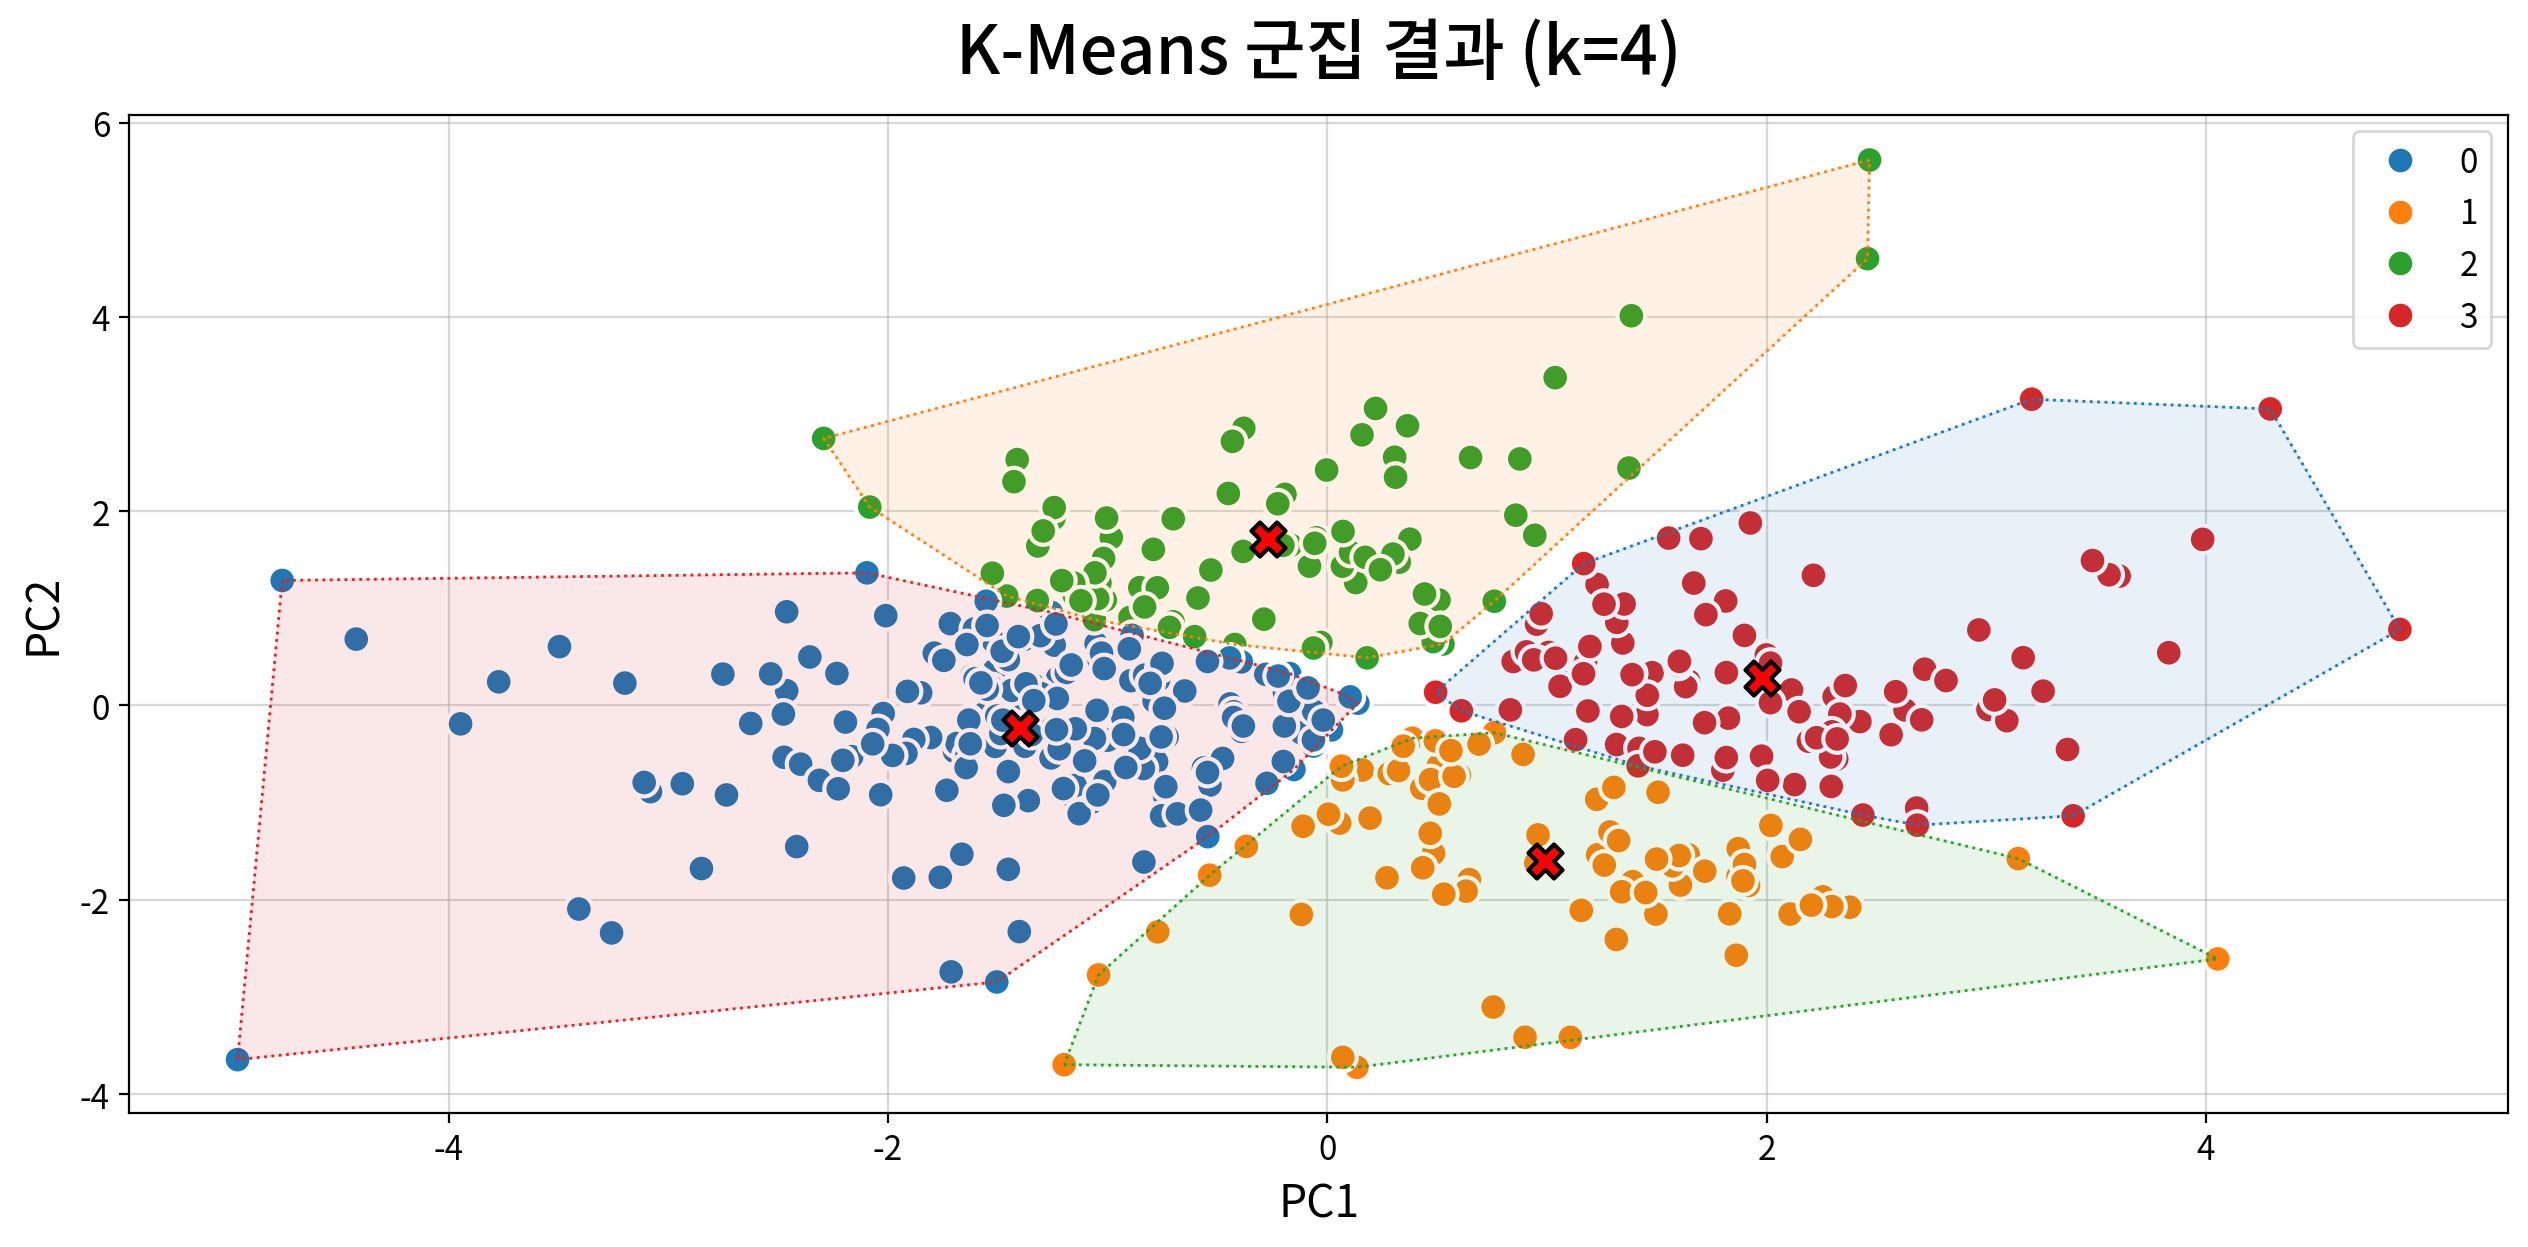

,Channel,페르소나군집번호
0,2,3
1,2,3
2,2,3
3,1,2
4,2,2


페르소나군집번호,0,1,2,3,All
Channel,,,,,
1,178,33,74,13,298
2,3,45,7,87,142
All,181,78,81,100,440


In [39]:
# K-Means 결과를 군집 데이터프레임으로 저장
cluster_model, cluster_df, cluster_centers = my_cluster.kmeans(
  pca_df, 4, scaling=None
)

# 원본 채널과 군집번호를 같은 행 기준으로 결합
channel_persona_df = pd.DataFrame({
  'Channel': df['Channel'].to_numpy(),
  '페르소나군집번호': cluster_df['그룹번호'].to_numpy()
})

# 채널 × 페르소나군집번호 교차표
channel_persona_crosstab = pd.crosstab(
  channel_persona_df['Channel'],
  channel_persona_df['페르소나군집번호'],
  margins=True
)

display(channel_persona_df.head())
display(channel_persona_crosstab)

In [40]:
# 시드 안정성 확인: KMeans 시작점 난수(random_state)를 바꿔도 같은 4개 군집이 나오는지 ARI로 비교
# ARI = 1이면 기준 군집과 완전히 같은 분할, 0에 가까우면 무작위 수준
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

pc_cols = ['PC1', 'PC2', 'PC3']
seed_rows = []
for seed in range(10):
    labels = KMeans(n_clusters=4, n_init=10, random_state=seed).fit_predict(pca_df[pc_cols])
    seed_rows.append({'seed': seed,
                      'ARI': round(adjusted_rand_score(cluster_df['그룹번호'], labels), 4),
                      '군집 크기': sorted(pd.Series(labels).value_counts().tolist(), reverse=True)})

seed_df = pd.DataFrame(seed_rows)
display(seed_df)

# 기준 군집(#3 페르소나)과 시드 0 결과의 대응: 어느 군집 사이에서 고객이 옮겨가는지 확인
seed0_labels = KMeans(n_clusters=4, n_init=10, random_state=0).fit_predict(pca_df[pc_cols])
display(Markdown('#### ▶ 기준 군집 × 시드 0 군집'))
display(pd.crosstab(cluster_df['그룹번호'], seed0_labels, rownames=['기준 군집'], colnames=['시드 0 군집']))
print('ARI 최소값:', seed_df['ARI'].min(), '/ 기준 군집 크기:', sorted(cluster_df['그룹번호'].value_counts().tolist(), reverse=True))

,seed,ARI,군집 크기
0,0,0.9070,"[168, 100, 94, 78]"
1,1,0.9070,"[168, 100, 94, 78]"
2,2,0.9070,"[168, 100, 94, 78]"
3,3,0.9070,"[168, 100, 94, 78]"
4,4,0.9044,"[166, 100, 96, 78]"
5,5,0.9044,"[166, 100, 96, 78]"
6,6,0.8397,"[159, 102, 97, 82]"
7,7,0.9070,"[168, 100, 94, 78]"
8,8,0.9070,"[168, 100, 94, 78]"
9,9,0.9070,"[168, 100, 94, 78]"


#### ▶ 기준 군집 × 시드 0 군집

시드 0 군집,0,1,2,3
기준 군집,,,,
0,168,0,12,1
1,0,1,0,77
2,0,0,81,0
3,0,99,1,0


ARI 최소값: 0.8397 / 기준 군집 크기: [181, 100, 81, 78]


#### 🔍 시드 안정성 해석

- 시드 0~9로 다시 군집화한 결과 기준 군집과의 ARI는 **0.84~0.91**로, 4개 군집의 골격은 시드가 바뀌어도 유지된다.
- 다만 군집 크기는 기준(181·100·81·78)과 달리 10개 시드 중 7개에서 168·100·94·78이 나왔다. 기준 × 시드 0 교차표를 보면 C2는 그대로이고, **C0 고객 13명(C2로 12명, C1로 1명)** 과 C1·C3 고객 각 1명이 옮겨간다.
- 즉 C0(소량 신선식품)와 C2(대량 신선·냉동·즉석/가공식품)의 **경계에 있는 고객은 시드에 따라 소속이 바뀐다**. 실루엣 0.281이 보여준 '경계가 약한 구조'와 같은 신호이므로, C0·C2 경계 고객의 페르소나는 확정적으로 해석하지 않는다.

In [41]:
# 군집별 원본 구매액 프로파일 (페르소나 정의 근거)
persona_names = {
    0: '소량 신선식품 중심형',
    1: '중간 규모 식료품·유제품·세제/종이류 중심형',
    2: '대량 신선·냉동·즉석/가공식품 구매형',
    3: '대량 식료품·유제품·세제/종이류 구매형',
}

persona_df = df.copy()
persona_df['군집'] = cluster_df['그룹번호'].to_numpy()
persona_df['페르소나'] = persona_df['군집'].map(persona_names)
persona_df['총구매액'] = persona_df[num_cols].sum(axis=1)

# 1) 군집 규모 및 매출 비중
size_df = persona_df.groupby('군집').agg(
    페르소나=('페르소나', 'first'),
    고객수=('군집', 'size'),
    총구매액_중앙값=('총구매액', 'median'),
    매출합=('총구매액', 'sum'),
)
size_df['고객비중'] = (size_df['고객수'] / len(persona_df)).round(3)
size_df['매출비중'] = (size_df['매출합'] / size_df['매출합'].sum()).round(3)

# 페르소나별 채널 비율 (분석 질문 3단계: 각 페르소나가 어느 채널에 몰려 있는가)
channel_ratio = pd.crosstab(persona_df['군집'], persona_df['Channel'], normalize='index')
size_df['Horeca비율'] = channel_ratio[1].round(3)
size_df['Retail비율'] = channel_ratio[2].round(3)
display(Markdown('#### ▶ 군집 규모 및 매출 비중'))
display(size_df)

# 2) 군집별 품목 평균 구매액
display(Markdown('#### ▶ 군집별 품목 평균 구매액 (원본)'))
display(persona_df.groupby('군집')[num_cols].mean().round(0))

# 3) 군집별 품목 구매 비중 (고객별 비중의 평균)
share_df = persona_df[num_cols].div(persona_df['총구매액'], axis=0)
display(Markdown('#### ▶ 군집별 품목 구매 비중'))
display(share_df.groupby(persona_df['군집']).mean().round(3))

#### ▶ 군집 규모 및 매출 비중

,페르소나,고객수,총구매액_중앙값,매출합,고객비중,매출비중,Horeca비율,Retail비율
군집,,,,,,,,
0,소량 신선식품 중심형,181,17415.0,3265493,0.411,0.223,0.983,0.017
1,중간 규모 식료품·유제품·세제/종이류 중심형,78,26498.0,2103915,0.177,0.144,0.423,0.577
2,대량 신선·냉동·즉석/가공식품 구매형,81,43394.0,3977979,0.184,0.272,0.914,0.086
3,대량 식료품·유제품·세제/종이류 구매형,100,45967.5,5272113,0.227,0.361,0.130,0.870


#### ▶ 군집별 품목 평균 구매액 (원본)

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
군집,,,,,,
0,10053.0,1894.0,2503.0,2404.0,450.0,736.0
1,3629.0,6494.0,11022.0,685.0,4563.0,579.0
2,26504.0,5239.0,5159.0,8239.0,808.0,3161.0
3,10307.0,12766.0,17679.0,1957.0,7649.0,2364.0


#### ▶ 군집별 품목 구매 비중

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
군집,,,,,,
0,0.500,0.122,0.157,0.143,0.030,0.049
1,0.143,0.250,0.398,0.030,0.154,0.026
2,0.527,0.108,0.109,0.176,0.018,0.062
3,0.208,0.234,0.328,0.041,0.138,0.051


### 🔍해석

군집은 Channel 없이 6개 구매 변수만으로 만들었고, 라벨도 **품목 구성 비중과 총구매 규모**만으로 붙였다. 품목명은 변수 정의 표의 이름(신선식품·유제품·식료품·냉동식품·세제/종이류·즉석/가공식품)을 따른다.

| 군집 | 고객 수 | 총구매액 중앙값 | 주요 구매 비중 | 채널 비율 (Horeca : Retail) | 페르소나 |
|---|---|---|---|---|---|
| C0 | 181 (41%) | 17,415 | Fresh 50%, Frozen 14% | **98.3%** : 1.7% (178 : 3) | **소량 신선식품 중심형** |
| C1 | 78 (18%) | 26,498 | Grocery 40%, Milk 25%, Det_Paper 15% | 42.3% : **57.7%** (33 : 45) | **중간 규모 식료품·유제품·세제/종이류 중심형** |
| C2 | 81 (18%) | 43,394 | Fresh 53%, Frozen 18%, Delicassen 6% | **91.4%** : 8.6% (74 : 7) | **대량 신선·냉동·즉석/가공식품 구매형** |
| C3 | 100 (23%) | 45,968 | Grocery 33%, Milk 23%, Det_Paper 14% | 13.0% : **87.0%** (13 : 87) | **대량 식료품·유제품·세제/종이류 구매형** |

- 4개 군집은 품목 구성으로 **신선·냉동 계열(C0·C2)** 과 **식료품·유제품·세제/종이류 계열(C1·C3)** 로 나뉘고, 각 계열 안에서 구매 규모가 다르다. 다만 C1의 중앙값(26,498)은 C0(17,415)의 약 1.5배, C3(45,968)의 약 절반이라 '소량/대량' 어느 쪽에도 딱 맞지 않으므로 중간 규모로 표기한다.
- **분석 질문 3단계(각 페르소나가 어느 채널에 몰려 있는가)의 답**: C0(Horeca 98%)와 C2(Horeca 91%)는 Horeca에, C3(Retail 87%)는 Retail에 몰려 있다. 반면 **C1은 Horeca 33명 : Retail 45명으로 채널이 섞인 군집**이다.
- 채널이 섞인 C1은 구매 패턴만으로 채널을 가르기 어려운 고객이 모인 곳이므로, 채널예측에서 오분류가 나올 가능성이 가장 큰 자리다.
- `Delicassen` 고액 소그룹은 별도 군집으로 나타나지 않았다. `Delicassen` 비중이 가장 높은 군집은 C2(6.2%)로, 신선·냉동과 함께 묶였다.

## #4. 채널예측

**누수 방지 원칙**: 원본을 가장 먼저 Train/Test로 나누고, 모든 전처리·군집화는 Train에만 fit한다. 모델 선택은 Train 내부의 교차검증으로 하고, Test는 마지막 평가에 한 번만 쓴다.

#### 1) 데이터 분할 및 특성 생성

In [42]:
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import PowerTransformer
from sklearn.cluster import KMeans

N_CLUSTERS = 4      # #3. 모델링 › 3) KMeans에서 결정한 군집 수


def build_features(train_raw, test_raw):
    """Train에만 fit한 Yeo-Johnson·군집 파이프라인으로 Train/Test 특성을 만든다.

    Returns:
        tuple: (x_train, x_test) - 구매 변수 6개(Yeo-Johnson 변환) + cluster(범주형)
    """
    # 1) Yeo-Johnson : helper에 없어 sklearn으로 처리한다 (표준화는 모델 파이프라인에서)
    yj = PowerTransformer(method='yeo-johnson', standardize=False)
    x_train = pd.DataFrame(yj.fit_transform(train_raw[num_cols]), columns=num_cols, index=train_raw.index)
    x_test = pd.DataFrame(yj.transform(test_raw[num_cols]), columns=num_cols, index=test_raw.index)

    # 2) 페르소나(군집) : 표준화 -> PCA(누적 설명력 80%) -> KMeans 를 Train에만 fit
    cluster_pipe = my_ml.fit_pipeline(
        KMeans(n_clusters=N_CLUSTERS, n_init=10, random_state=RANDOM_STATE), x_train, None,
        scale=True, pca=True, pca_variance=0.8, name='KMeans', verbose=False
    )

    # Test는 Train 기준 중심점으로 predict만 한다.
    # 군집 컬럼을 붙이기 전에 예측해야 파이프라인이 학습 때와 같은 컬럼을 받는다
    train_cluster = cluster_pipe.predict(x_train)
    test_cluster = cluster_pipe.predict(x_test)

    # 카테고리를 고정해서 Train/Test 더미 컬럼 개수를 일치시킨다
    cats = pd.CategoricalDtype(categories=list(range(N_CLUSTERS)))
    x_train['cluster'] = pd.Series(train_cluster, index=x_train.index).astype(cats)
    x_test['cluster'] = pd.Series(test_cluster, index=x_test.index).astype(cats)

    return x_train, x_test


# 원본에서 가장 먼저 분할한다 (전처리 이전!)
X_raw = drop_df[num_cols]
y = drop_df['Channel'].astype(int)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

X_train, X_test = build_features(X_train_raw, X_test_raw)

print(f'Train {X_train.shape} / Test {X_test.shape}')
print('Train 채널 비율:', y_train.value_counts(normalize=True).round(3).to_dict())
print('Test  채널 비율:', y_test.value_counts(normalize=True).round(3).to_dict())
display(X_train.head())

Train (352, 7) / Test (88, 7)
Train 채널 비율: {1: 0.676, 2: 0.324}
Test  채널 비율: {1: 0.682, 2: 0.318}


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,cluster
152,65.899895,9.392373,15.217712,12.291648,7.146466,8.359117,1
227,39.551616,10.190785,13.101822,11.692215,6.724569,11.903394,1
272,19.277269,12.572031,17.871967,8.736424,5.288001,13.181422,0
426,58.544717,12.790668,20.644899,12.393695,11.416224,15.208532,2
91,57.981804,10.579773,14.543054,14.798255,8.007061,13.412324,3


#### 2) 모델 구성

In [43]:
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 모델
MODEL_SPECS = {
    'LogisticRegression': (
        LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
        dict(scale=True, vif=True, drop_first=True),
    ),
    'KNN': (KNeighborsClassifier(n_neighbors=5), dict(scale=True)),
    'SVM': (
        # 오분류 분석에서 예측신뢰도를 쓰기 위해 probability=True
        SVC(class_weight='balanced', probability=True, random_state=RANDOM_STATE),
        dict(scale=True),
    ),
    'RandomForest': (
        RandomForestClassifier(n_estimators=300, class_weight='balanced',
                               random_state=RANDOM_STATE, n_jobs=-1),
        {},
    ),
    'GradientBoosting': (GradientBoostingClassifier(random_state=RANDOM_STATE), {}),
}


def fit_models(x_train, y_train):
    """MODEL_SPECS 의 모든 모델을 my_ml.fit_pipeline 으로 학습한다.
    추정기는 clone 해서 쓰므로 폴드마다 호출해도 이전 학습 결과를 덮어쓰지 않는다."""
    return {
        name: my_ml.fit_pipeline(clone(model), x_train, y_train, nominal_cols=['cluster'],
                                 name=name, verbose=False, **options)
        for name, (model, options) in MODEL_SPECS.items()
    }


def cls_score(model, x_test, y_test):
    """분류 성능 지표(Accuracy, Macro Precision/Recall/F1)를 계산한다."""
    pred = model.predict(x_test)
    return {
        'Accuracy': accuracy_score(y_test, pred),
        'Macro Precision': precision_score(y_test, pred, average='macro', zero_division=0),
        'Macro Recall': recall_score(y_test, pred, average='macro', zero_division=0),
        'Macro F1': f1_score(y_test, pred, average='macro', zero_division=0),
    }


# 전처리 구성 확인 (Train 전체로 한 번 학습해서 단계만 출력)
for name, (model, options) in MODEL_SPECS.items():
    print(f'\n[{name}]')
    my_ml.fit_pipeline(clone(model), X_train, y_train, nominal_cols=['cluster'], name=name, **options)


[LogisticRegression]
대상: 352행 x 7열 | 모델: LogisticRegression
명목형: ['cluster']
연속형: ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

전처리 단계
  연속형: 다중공선성 제거(VIF >= 10.0) → 정규화(standard)
  명목형: 더미변수 인코딩(drop_first=True)



모델 학습 완료: LogisticRegression

[KNN]
대상: 352행 x 7열 | 모델: KNN
명목형: ['cluster']
연속형: ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

전처리 단계
  연속형: 정규화(standard)
  명목형: 더미변수 인코딩(drop_first=False)



모델 학습 완료: KNN

[SVM]
대상: 352행 x 7열 | 모델: SVM
명목형: ['cluster']
연속형: ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

전처리 단계
  연속형: 정규화(standard)
  명목형: 더미변수 인코딩(drop_first=False)



모델 학습 완료: SVM

[RandomForest]
대상: 352행 x 7열 | 모델: RandomForest
명목형: ['cluster']
연속형: ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

전처리 단계
  연속형: (변환 없음)
  명목형: 더미변수 인코딩(drop_first=False)



모델 학습 완료: RandomForest

[GradientBoosting]
대상: 352행 x 7열 | 모델: GradientBoosting
명목형: ['cluster']
연속형: ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

전처리 단계
  연속형: (변환 없음)
  명목형: 더미변수 인코딩(drop_first=False)

모델 학습 완료: GradientBoosting


#### 3) 교차검증으로 모델 선택 (Train 내부)

Train을 StratifiedKFold(5)로 나누고, **폴드마다 `build_features()`부터 다시 실행**한다. 검증 폴드의 정보가 Yeo-Johnson·군집·스케일러에 섞이지 않는다. 평균 Macro F1이 가장 높은 모델을 최종 모델로 고른다.

#### ▶ StratifiedKFold(5) 교차검증 결과 (Train 내부)

,Accuracy (mean),Macro Recall (mean),Macro F1 (mean),Macro F1 (std)
모델,,,,
RandomForest,0.9175,0.9110,0.9062,0.0307
GradientBoosting,0.9119,0.9023,0.8990,0.0489
SVM,0.8949,0.9036,0.8846,0.0305
KNN,0.8950,0.8923,0.8825,0.0340
LogisticRegression,0.8920,0.9012,0.8818,0.0268


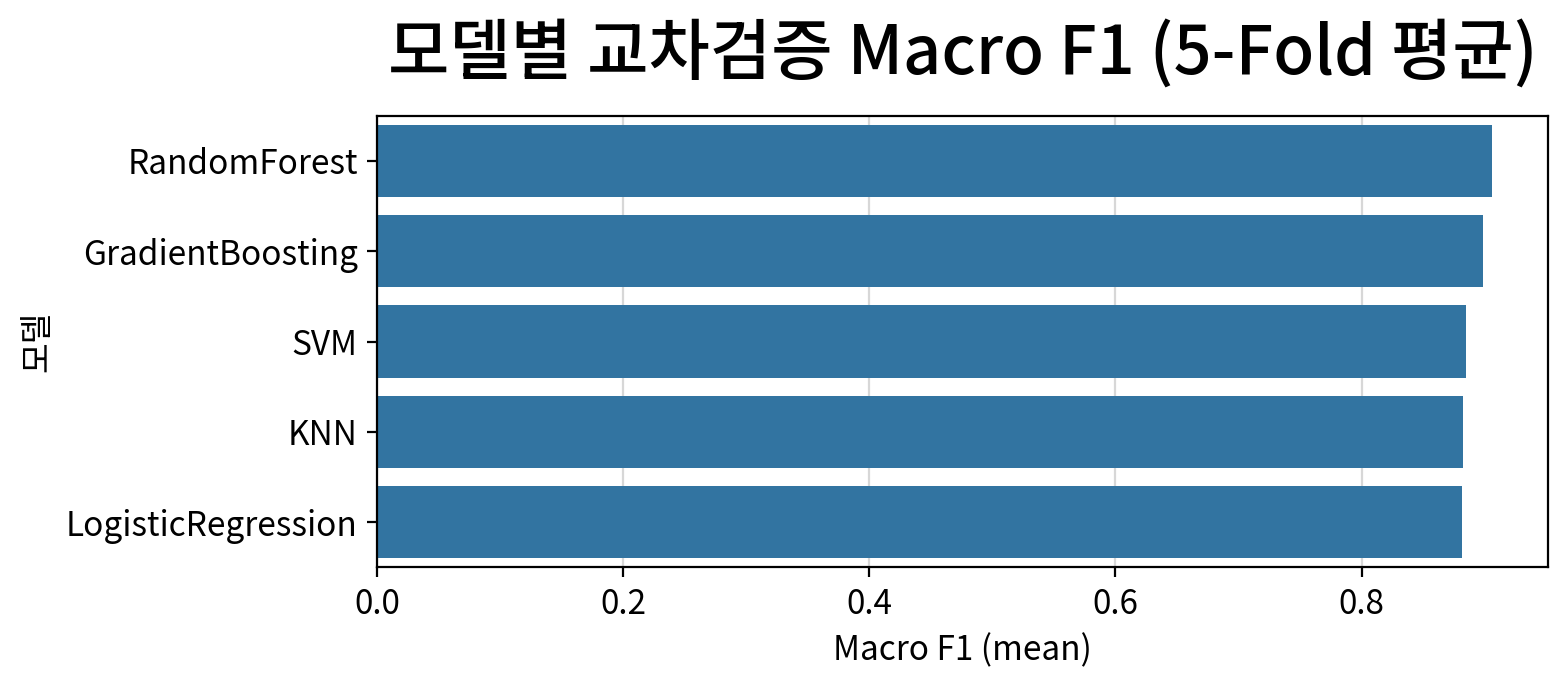

교차검증 Macro F1 기준 최종 모델: RandomForest


In [44]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_rows = []
for fold, (tr_idx, va_idx) in enumerate(cv.split(X_train_raw, y_train), start=1):
    tr_raw, va_raw = X_train_raw.iloc[tr_idx], X_train_raw.iloc[va_idx]
    y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]

    # 폴드의 Train 부분에만 Yeo-Johnson·군집을 새로 fit
    x_tr, x_va = build_features(tr_raw, va_raw)

    for name, model in fit_models(x_tr, y_tr).items():
        cv_rows.append({'모델': name, 'Fold': fold, **cls_score(model, x_va, y_va)})

cv_df = pd.DataFrame(cv_rows)

cv_summary = (
    cv_df.groupby('모델')
    .agg(**{
        'Accuracy (mean)': ('Accuracy', 'mean'),
        'Macro Recall (mean)': ('Macro Recall', 'mean'),
        'Macro F1 (mean)': ('Macro F1', 'mean'),
        'Macro F1 (std)': ('Macro F1', 'std'),
    })
    .sort_values('Macro F1 (mean)', ascending=False)
)

display(Markdown('#### ▶ StratifiedKFold(5) 교차검증 결과 (Train 내부)'))
display(cv_summary.round(4))

my_plot.barplot(cv_summary.reset_index(), x='Macro F1 (mean)', y='모델',
                title='모델별 교차검증 Macro F1 (5-Fold 평균)', width=800, height=360)

best_name = cv_summary.index[0]
print(f'교차검증 Macro F1 기준 최종 모델: {best_name}')

#### 4) 최종 평가 (Test 1회)

Train 전체로 다시 학습한 뒤 Test에서 한 번만 평가한다. Test 결과는 모델 선택에 쓰지 않고, 일반화 성능 확인용으로만 본다.

#### ▶ Test 성능 (교차검증 순위 순)

,Accuracy,Macro Precision,Macro Recall,Macro F1
모델,,,,
RandomForest,0.9545,0.9476,0.9476,0.9476
GradientBoosting,0.9205,0.9117,0.9036,0.9074
SVM,0.9318,0.9161,0.9310,0.9229
KNN,0.9318,0.9214,0.9214,0.9214
LogisticRegression,0.9432,0.9313,0.9393,0.9351


#### ▶ 채널별 성능 지표 (RandomForest)

,precision,recall,f1-score,support
채널 1 (Horeca),0.9667,0.9667,0.9667,60.0000
채널 2 (Retail),0.9286,0.9286,0.9286,28.0000
accuracy,0.9545,0.9545,0.9545,0.9545
macro avg,0.9476,0.9476,0.9476,88.0000
weighted avg,0.9545,0.9545,0.9545,88.0000


#### ▶ Confusion Matrix (RandomForest)

,예측 채널 1 (Horeca),예측 채널 2 (Retail)
실제 채널 1 (Horeca),58,2
실제 채널 2 (Retail),2,26


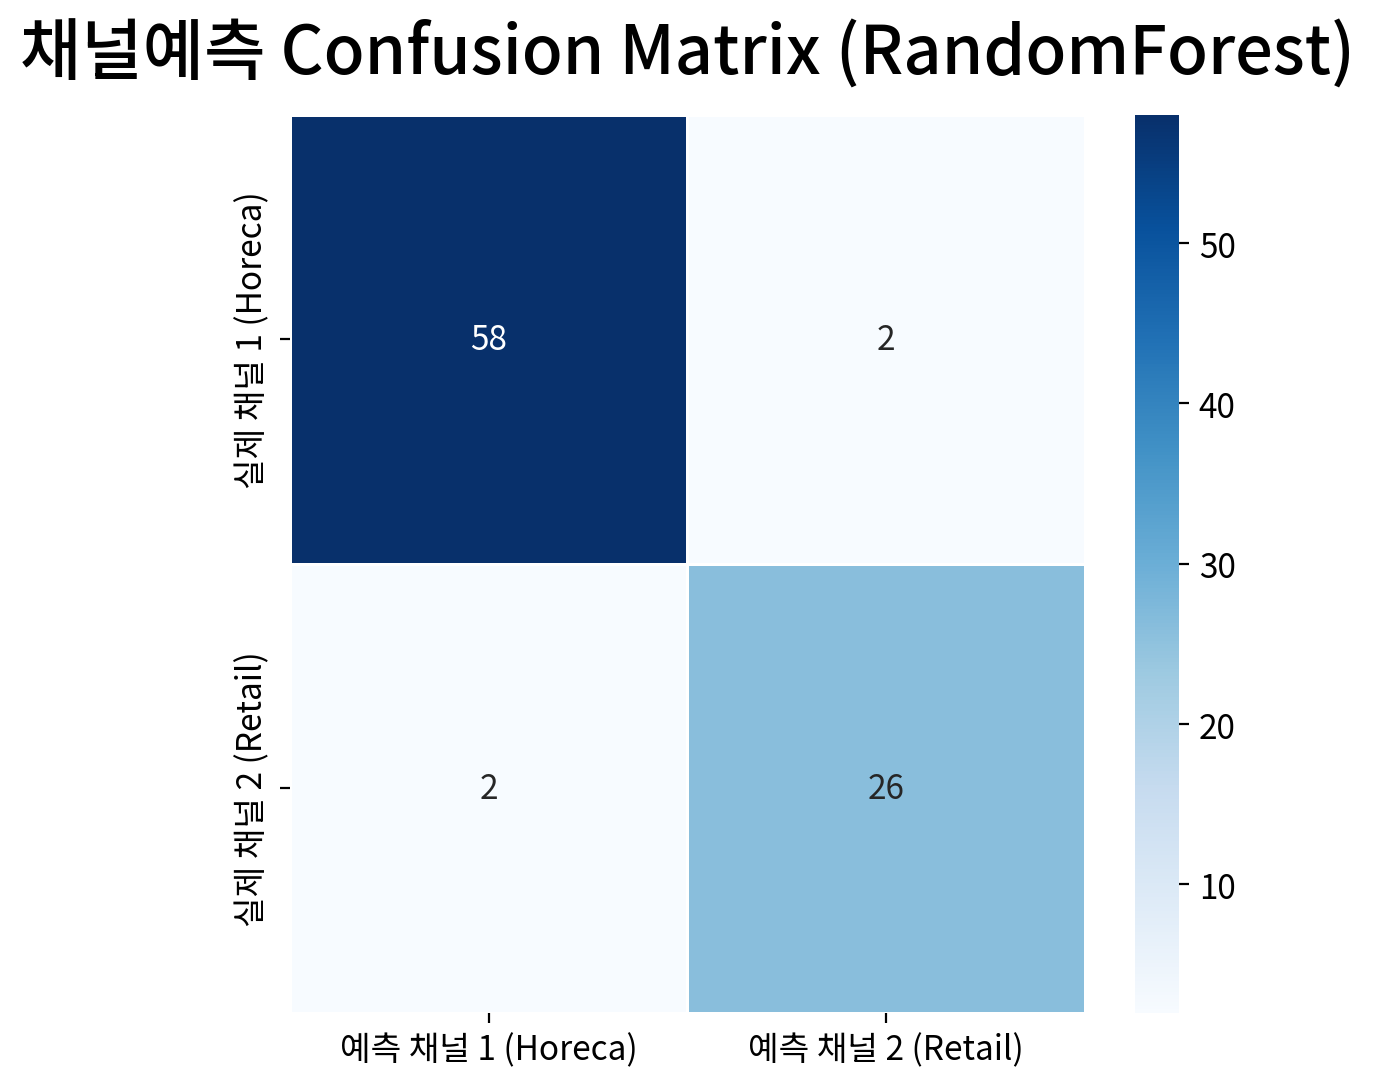

In [45]:
from sklearn.metrics import classification_report, confusion_matrix

# 1) Train 전체로 재학습 후 Test 평가 (표는 교차검증 순위 순서로 정렬)
final_models = fit_models(X_train, y_train)
test_summary = pd.DataFrame({name: cls_score(m, X_test, y_test) for name, m in final_models.items()}).T
test_summary = test_summary.loc[cv_summary.index]
test_summary.index.name = '모델'

display(Markdown('#### ▶ Test 성능 (교차검증 순위 순)'))
display(test_summary.round(4))

# 2) 최종 모델 상세 평가
best_model = final_models[best_name]
y_pred = best_model.predict(X_test)
labels = [1, 2]
label_names = ['채널 1 (Horeca)', '채널 2 (Retail)']

display(Markdown(f'#### ▶ 채널별 성능 지표 ({best_name})'))
display(pd.DataFrame(classification_report(y_test, y_pred, labels=labels, target_names=label_names,
                                           output_dict=True, zero_division=0)).T.round(4))

cm_df = pd.DataFrame(confusion_matrix(y_test, y_pred, labels=labels),
                     index=[f'실제 {n}' for n in label_names],
                     columns=[f'예측 {n}' for n in label_names])
display(Markdown(f'#### ▶ Confusion Matrix ({best_name})'))
display(cm_df)
my_plot.heatmap(data=cm_df, annot=True, fmt='d', palette='Blues',
                title=f'채널예측 Confusion Matrix ({best_name})', width=560, height=560)

#### ▶ 변수 영향력 (RandomForest)

,변수,중요도
0,Detergents_Paper,0.3416
1,Grocery,0.2272
2,Milk,0.1548
3,Frozen,0.0613
4,cluster_1,0.0550
5,cluster_2,0.0474
6,Delicassen,0.0416
7,Fresh,0.0410
8,cluster_0,0.0168
9,cluster_3,0.0132


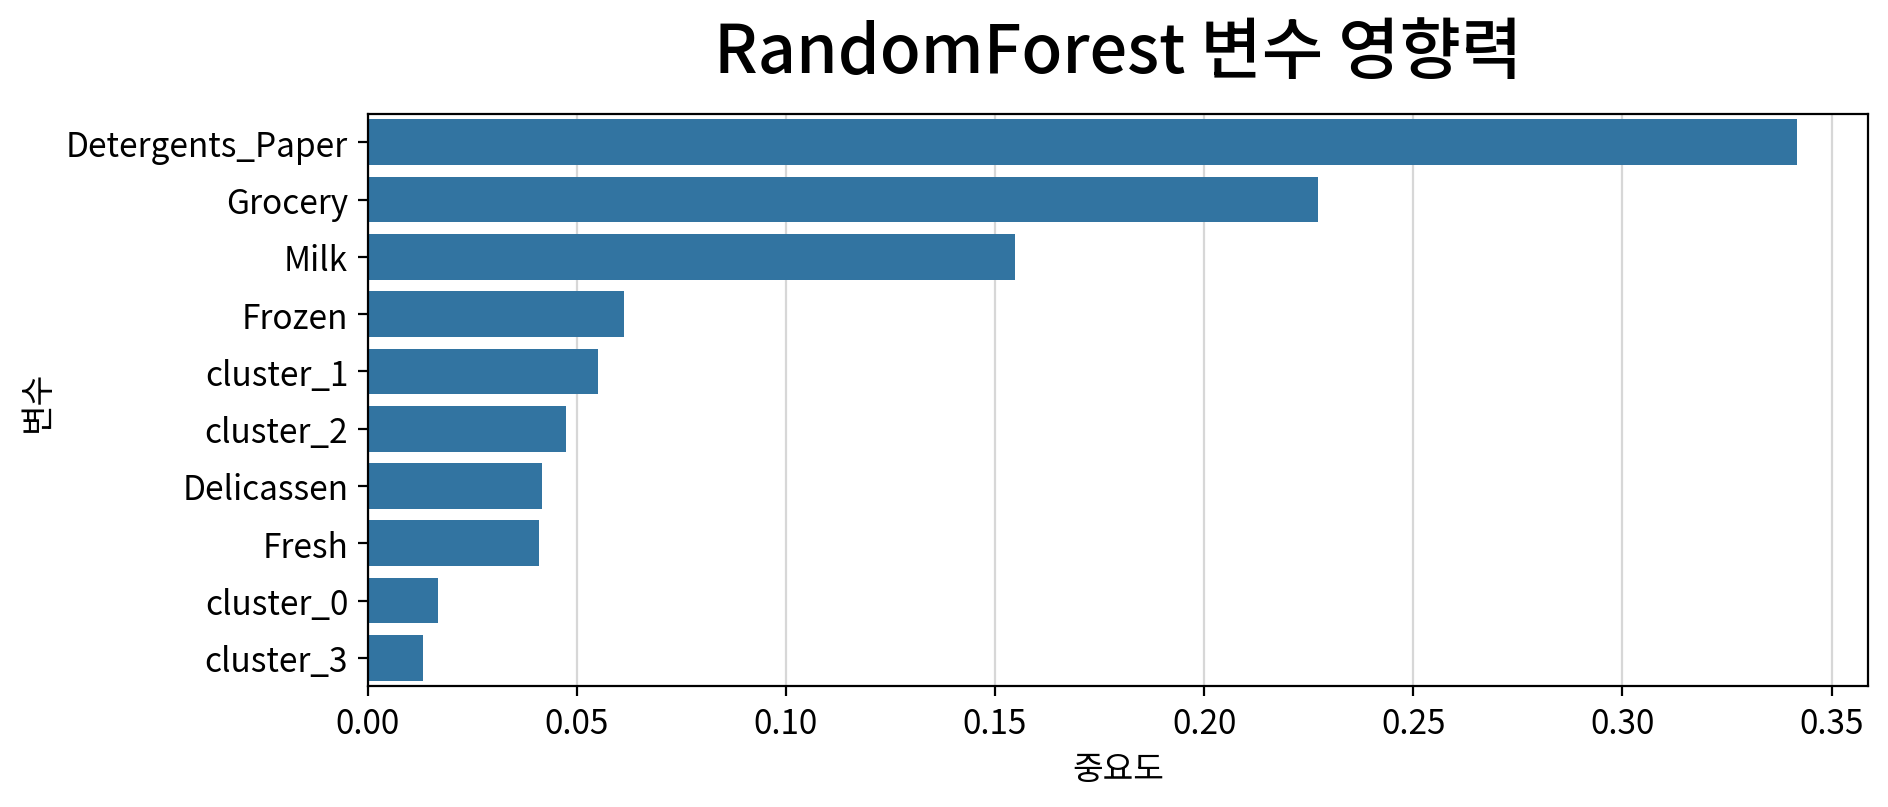

In [46]:
# 3) 최종 모델의 변수 영향력
# 전처리 후 컬럼명은 파이프라인 전처리기의 출력에서 꺼낸다 (VIF로 제거된 변수는 빠진다)
estimator = best_model.named_steps['model']
feature_names = best_model.named_steps['preprocessor'].transform(X_train.head()).columns

if hasattr(estimator, 'feature_importances_'):
    importance_df = pd.DataFrame({'변수': feature_names, '중요도': estimator.feature_importances_})
elif hasattr(estimator, 'coef_'):
    # 선형 모델은 표준화된 계수의 절대값으로 영향력을 비교한다 (양수 = Retail 방향)
    importance_df = pd.DataFrame({'변수': feature_names, '계수': estimator.coef_[0]})
    importance_df['중요도'] = importance_df['계수'].abs()
else:
    importance_df = None
    print(f'{best_name}은 변수 중요도·계수를 제공하지 않는다.')

if importance_df is not None:
    importance_df = importance_df.sort_values('중요도', ascending=False).reset_index(drop=True)
    display(Markdown(f'#### ▶ 변수 영향력 ({best_name})'))
    display(importance_df.round(4))
    my_plot.barplot(importance_df, x='중요도', y='변수',
                    title=f'{best_name} 변수 영향력', width=960, height=420)

## #5. 오분류 고객 추출

In [47]:
# Train 군집번호 -> #3 페르소나 매칭
# 같은 Train 고객이 #3(전체 데이터 군집)에서 어느 페르소나였는지 교차표로 보고, 다수결로 짝을 맞춘다
train_map_ct = pd.crosstab(X_train['cluster'].astype(int), persona_df.loc[X_train.index, '페르소나'])
train_map_ct.index.name = 'Train 군집번호'
display(Markdown('#### ▶ Train 군집번호 × #3 페르소나 (Train 고객 기준)'))
display(train_map_ct)
cluster_to_persona = train_map_ct.idxmax(axis=1).to_dict()

proba = best_model.predict_proba(X_test)

pred_df = pd.DataFrame({
    '실제채널': y_test,
    '예측채널': y_pred,
    '예측신뢰도': proba.max(axis=1).round(4),
    '군집번호': X_test['cluster'].astype(int),
    '페르소나': X_test['cluster'].astype(int).map(cluster_to_persona),
}, index=X_test.index).join(X_test_raw)

misclassified_df = pred_df[pred_df['실제채널'] != pred_df['예측채널']].sort_values('예측신뢰도')
misclassified_df.insert(2, '오분류유형', '채널 ' + misclassified_df['실제채널'].astype(str)
                        + ' → 채널 ' + misclassified_df['예측채널'].astype(str))

print(f'Test 고객 {len(pred_df)}명 중 오분류 {len(misclassified_df)}명 ({len(misclassified_df) / len(pred_df):.1%})')
display(misclassified_df)

#### ▶ Train 군집번호 × #3 페르소나 (Train 고객 기준)

페르소나,대량 식료품·유제품·세제/종이류 구매형,대량 신선·냉동·즉석/가공식품 구매형,소량 신선식품 중심형,중간 규모 식료품·유제품·세제/종이류 중심형
Train 군집번호,,,,
0,0,0,1,67
1,0,0,132,0
2,80,0,0,0
3,0,64,8,0


Test 고객 88명 중 오분류 4명 (4.5%)


,실제채널,예측채널,오분류유형,예측신뢰도,군집번호,페르소나,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
181,1,2,채널 1 → 채널 2,0.5233,3,대량 신선·냉동·즉석/가공식품 구매형,112151,29627,18148,16745,4948,8550
342,1,2,채널 1 → 채널 2,0.6067,0,중간 규모 식료품·유제품·세제/종이류 중심형,255,5758,5923,349,4595,1328
223,2,1,채널 2 → 채널 1,0.9800,3,대량 신선·냉동·즉석/가공식품 구매형,2790,2527,5265,5612,788,1360
11,2,1,채널 2 → 채널 1,0.9967,1,소량 신선식품 중심형,13146,1124,4523,1420,549,497


<div style="background-color:#FFF8E1; border-left:6px solid #F9A825; border-radius:4px; padding:20px 15px 5px 30px; margin:8px 10px 8px 0; color:#5D4037; box-sizing:border-box; max-width:calc(100% - 10px); overflow-wrap:anywhere; white-space:normal;">

#### ✏️ Feedback Note

- idx `223`은 총구매액 `18,342`(하위 28.6%), `Fresh` 비중 15%로 `대량 신선·냉동·즉석/가공식품 구매형`(C2, 중앙값 `43,394`, `Fresh` 53%)과 맞지 않습니다. Train 군집 3에는 `소량 신선식품 중심형` 고객 8명이 섞여 있어 다수결 매칭이 틀릴 수 있습니다.
  - ► Test 고객도 #3 군집(440명 전체)에 들어 있으니 `persona_df.loc[misclassified_df.index, '페르소나']`로 #3 소속을 직접 출력해 표와 대조하세요.

</div>

In [48]:
# 오분류 고객의 총구매액 위치(전체 440명 기준 백분위)와 품목 비중, 채널별 총구매액 중앙값
total_spend = drop_df[num_cols].sum(axis=1)

mis_profile = pd.DataFrame({
    '총구매액': total_spend.loc[misclassified_df.index],
    '하위 백분위(%)': [round((total_spend < total_spend[i]).mean() * 100, 1) for i in misclassified_df.index],
})
mis_share = drop_df.loc[misclassified_df.index, num_cols].div(mis_profile['총구매액'], axis=0).round(3)

display(Markdown('#### ▶ 오분류 고객의 총구매액 백분위와 품목 비중'))
display(mis_profile.join(mis_share))

display(Markdown('#### ▶ 채널별 총구매액 중앙값 (전체 440명)'))
display(total_spend.groupby(drop_df[target]).median().rename('총구매액 중앙값').to_frame())

#### ▶ 오분류 고객의 총구매액 백분위와 품목 비중

,총구매액,하위 백분위(%),Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
181,190169,99.3,0.590,0.156,0.095,0.088,0.026,0.045
342,18208,28.2,0.014,0.316,0.325,0.019,0.252,0.073
223,18342,28.6,0.152,0.138,0.287,0.306,0.043,0.074
11,21259,35.0,0.618,0.053,0.213,0.067,0.026,0.023


#### ▶ 채널별 총구매액 중앙값 (전체 440명)

,총구매액 중앙값
Channel,
1,21254.5
2,37139.0


### 🔍 채널예측 해석 및 인사이트

**1) 모델 선택 — 교차검증 (Train 내부, StratifiedKFold 5)**

| 모델 | Accuracy | Macro Recall | Macro F1 (mean ± std) |
|---|---|---|---|
| **RandomForest** | 0.918 | 0.911 | **0.906 ± 0.031** |
| GradientBoosting | 0.912 | 0.902 | 0.899 ± 0.049 |
| SVM | 0.895 | 0.904 | 0.885 ± 0.031 |
| KNN | 0.895 | 0.892 | 0.883 ± 0.034 |
| LogisticRegression | 0.892 | 0.901 | 0.882 ± 0.027 |

- 교차검증 Macro F1 기준으로 `RandomForest`를 최종 모델로 선택했다.
- 다만 5개 모델이 0.88~0.91 구간에 몰려 있고 표준편차(0.03~0.05)를 감안하면 모델 간 우열은 크지 않다. **"어떤 모델을 쓰든 구매 패턴만으로 채널이 약 90% 구분된다"** 가 핵심이다.

**2) 최종 평가 — Test 1회 (88명)**

- `RandomForest` Test 성능: **Accuracy 0.955, Macro F1 0.948**. 교차검증(0.906 ± 0.031)보다 높고 1 표준편차 범위(최대 0.937)도 넘지만, Test가 88명이라 1~2명 차이로도 F1이 크게 흔들린다. 과적합이라면 Test 성능이 오히려 낮아야 하므로 과적합 신호로 보지 않는다.
- Test 88명에서 전원 Horeca로 찍은 기준선 **68.2%(60/88)** 대비 **약 27%p 향상**.
- Test에서는 `LogisticRegression`(0.935)이 2위였지만, Test 결과는 모델 선택에 쓰지 않는다는 원칙에 따라 교차검증 1위 모델을 유지한다.

| 채널 | Precision | Recall | F1 | Support |
|---|---|---|---|---|
| 채널 1 (Horeca) | 0.967 | 0.967 | 0.967 | 60 |
| 채널 2 (Retail) | 0.929 | 0.929 | 0.929 | 28 |

|  | 예측 Horeca | 예측 Retail |
|---|---|---|
| 실제 Horeca | 58 | 2 |
| 실제 Retail | 2 | 26 |

- 오분류는 양방향 2건씩이지만, 채널별 오류율은 Horeca 3.3%(2/60), Retail 7.1%(2/28)로 소수 채널인 Retail에서 약 2배 높다.
- 채널 불균형(67.7% : 32.3%)을 고려해 `class_weight='balanced'`를 적용했고, 소수 채널(Retail) Recall 0.93을 확보했다.

**3) 변수 영향력 (RandomForest)**

| 변수 | 중요도 |
|---|---|
| Detergents_Paper | 0.342 |
| Grocery | 0.227 |
| Milk | 0.155 |
| Frozen / Delicassen / Fresh | 0.04 ~ 0.06 |
| cluster 더미 합계 | 0.132 |

- **Retail 품목 3개(Det_Paper·Grocery·Milk)가 전체 중요도의 약 72%** 를 차지한다. PC1의 구성 변수(Milk·Grocery·Detergents_Paper)와 같은 묶음이다.
- 반면 `Fresh` 중요도는 0.041로 가장 낮은 편이다. 두 채널 모두 신선식품을 사기 때문에 채널을 가르지 못한다.
- 군집 더미는 합계 0.13으로 **보조 신호**다. 채널 구분의 핵심은 원본 구매액(특히 Detergents_Paper)이다.

**4) 오분류 고객 (Test 88명 중 4명, 4.5%)**

| idx | 실제 → 예측 | 예측신뢰도 | 페르소나 (Train 군집번호) | 구매 특징 | 유형 |
|---|---|---|---|---|---|
| 181 | Horeca → Retail | **0.52** | C2 대량 신선·냉동·즉석/가공식품 구매형 (C3) | Fresh 112,151(전체 최대값), 전 품목 극단적으로 큼 | 규모 이상치형 |
| 342 | Horeca → Retail | 0.61 | C1 중간 규모 식료품·유제품·세제/종이류 중심형 (C0) | Fresh 255로 매우 낮고 Det_Paper 4,595 → 소매 패턴 | 카테고리 이탈형 |
| 223 | Retail → Horeca | **0.98** | C2 대량 신선·냉동·즉석/가공식품 구매형 (C3) | Det_Paper 788로 낮고 Frozen 5,612로 높음 | 라벨-행동 불일치형 |
| 11 | Retail → Horeca | **0.997** | C0 소량 신선식품 중심형 (C1) | Fresh 13,146, Det_Paper 549 → 식자재 패턴 | 라벨-행동 불일치형 |

- 오분류는 예측신뢰도에 따라 **두 유형으로 뚜렷하게 나뉜다.**
  - **저신뢰 오분류 (0.52~0.61, 모두 Horeca → Retail)**: 모델도 확신하지 못한 경계 고객이다. 특히 idx 181은 사실상 50:50으로, 모델 오류라기보다 구매 규모가 극단값이라 판단 불가능한 케이스다.
  - **고신뢰 오분류 (0.98 이상, 모두 Retail → Horeca)**: 모델은 확신하는데 라벨과 다르다. 등록 채널(Retail)과 실제 구매 행동(Horeca형)이 어긋난 고객으로 해석한다.
- 오분류가 무작위가 아니라 **특정 구매 패턴(신선·냉동 중심 Retail, 식료품·세제/종이류 중심 Horeca)에서 발생**한다.
- **페르소나 매칭**: 표의 `군집번호`는 Train에만 fit한 KMeans 결과라 #3의 번호와 다르다. Train 고객이 #3에서 속한 페르소나와 교차표로 대조해 다수결로 짝을 맞췄다(0→C1, 1→C0, 2→C3, 3→C2). 각 Train 군집의 89~100%가 짝지은 페르소나와 같다.
- 페르소나로 보면 **고신뢰 오분류 223(C2)·11(C0)은 Horeca 비율 91~98%인 페르소나에 속한 Retail 고객**이다. 구매 패턴은 Horeca 페르소나와 같은데 등록만 Retail이라, 라벨-행동 불일치 해석을 뒷받침한다.
- **342는 채널이 섞인 C1**(Horeca 42% : Retail 58%)에 속해, #3에서 예상한 '오분류가 나올 자리'와 일치한다.
- **181은 Horeca 페르소나 C2**에 속하지만 구매 규모가 극단적이라(Milk·Grocery 절대액도 큼) 모델이 Retail로 판단했다.

**5) 인사이트 및 액션**

| 유형 | 고객 | 예측신뢰도 | 액션 |
|---|---|---|---|
| 라벨-행동 불일치형 | 223, 11 | 0.98 이상 | 등록 채널은 유지하되 내부 서비스를 Horeca 기준으로 전환 (신선·냉동 카탈로그, 정기배송), 영업 실사로 업태 변화 확인 |
| 카테고리 이탈형 | 342 | 0.61 | 최근 발주 이력으로 먼저 검증 → Fresh를 다른 곳에서 조달 중이면 Fresh 시범가·소량 납품 제안 |
| 규모 이상치형 | 181 | 0.52 | 마케팅 대상이 아닌 Key Account(핵심 거래처) 관리로 분리 |

- **예측신뢰도를 액션 강도로 쓴다**: 신뢰도가 높을수록 즉시 대응, 낮을수록 검증 우선.
- **채널 라벨 검증 도구로 활용**: 운영 근거는 1인 Test(95.5%)가 아니라 교차검증 Accuracy `0.918`(약 92%)을 쓴다. 이 정도면 "예측 ≠ 등록 채널 & 신뢰도 0.9 이상" 고객을 정기적으로 추출해 채널 정보 점검 리스트로 쓸 만하다.
- **Retail 고객의 Det_Paper 감소는 이탈/업태 변화 신호**: 가장 강력한 판별 변수이므로 모니터링 지표로 쓸 수 있다.

<div style="background-color:#FFF8E1; border-left:6px solid #F9A825; border-radius:4px; padding:20px 15px 5px 30px; margin:8px 10px 8px 0; color:#5D4037; box-sizing:border-box; max-width:calc(100% - 10px); overflow-wrap:anywhere; white-space:normal;">

#### ✏️ Feedback Note

- '구매 데이터만으로 채널을 약 95% 맞히므로'는 Test 88명으로 한 번 잰 결과입니다. 같은 셀 1)·2)에서 'Test는 1~2명 차이로도 크게 흔들린다'며 핵심을 '약 90%'로 정리했습니다.
  - ► 운영 근거로는 교차검증 정확도 `0.918`(약 92%)을 쓰세요.

</div>

## #6. 결론 및 오분류 고객 마케팅 전략

### 1) 가설 검증 결과

| 단계 | 가설 | 결과 | 근거 |
|---|---|---|---|
| 1단계(군집) | 가설1. 최소 2개 이상의 뚜렷한 소비 패턴 그룹이 존재한다 | 지지 | 품목 구성(신선·냉동 계열 vs 식료품·유제품·세제/종이류 계열)과 구매 규모로 구분되는 4개 페르소나 도출. 단, 실루엣 0.28로 군집 경계는 뚜렷하지 않고, 시드를 바꾸면 C0·C2 경계 고객의 소속이 바뀐다(ARI 0.84~0.91) |
| 1단계(군집) | 가설2. Horeca는 Fresh·Frozen, Retail은 Grocery·Milk·Det_Paper 비중이 높다 | 부분 지지 | 구매 비중은 가설대로 나타남(Horeca가 몰린 C0·C2는 Fresh 50% 이상, Retail 비율이 높은 C3(87%)·C1(58%)는 Grocery·Milk·Det_Paper 중심). 그러나 채널 판별력은 Retail 품목 3개가 중요도의 72%이고 Fresh는 0.04로 낮다. Horeca는 "신선식품을 많이 사서"가 아니라 "Retail 품목을 적게 사서" 구분된다 |
| 2단계(분류) | 가설3. 오분류는 무작위가 아니라 특정 소비 패턴에 집중된다 | 지지 | 오분류 4명 모두 자기 채널의 전형 패턴에서 벗어난 고객(식료품·세제/종이류 중심 Horeca, 신선·냉동 중심 Retail, 초고액 고객)이다. |
| 3단계(연결) | 가설4. 오분류 고객은 단순 오류가 아닌 채널 전환/혼합형 고객이다 | 부분 지지 | idx 223·11은 예측신뢰도 0.98 이상으로, 등록 채널과 실제 구매 행동이 어긋난 고객. 두 고객은 Horeca 비율 91~98%인 페르소나(C2·C0)에 속한다. 단, 모델 신뢰도만으로 라벨 오류를 확정할 수 없어 실제 업태 확인이 필요하다. |
| 3단계(연결) | 가설5. 오분류 고객의 구매액은 정분류 고객과 다르다 | 검정 불가 (기술적 비교만 수행) | 3명(342·223·11)은 총구매액 하위 28~35% 수준의 소액 고객, 1명(181)은 상위 0.7%의 초고액 고객으로 양 극단에 위치한다(#5 백분위 출력). 오분류 4명으로는 유의성 검정을 할 수 없어 기술적 비교만 수행했다. |

### 2) 분석 질문에 대한 답

**Q1. 이 도매업체 고객은 몇 종류인가?**
- **4종류**(C0~C3)다. 단, 실루엣 0.28로 군집 경계는 약하고, C0·C2 경계 고객은 시드에 따라 소속이 바뀐다.

**Q2. 채널 정보 없이도 채널을 구분할 수 있는가?**
- 구매 변수 6개만으로 채널을 Test 기준 **95.5%** 맞힌다(Test 기준선 68.2%). 채널 구분은 대부분 가능하며, 오분류는 88명 중 4명(4.5%)뿐이다.

**Q3. 각 페르소나는 어느 채널에 몰려 있고, 페르소나와 실제 채널이 어긋나는 이유는 무엇인가?**
- C0(Horeca 98%)·C2(Horeca 91%)는 Horeca에, C3(Retail 87%)는 Retail에 몰려 있고, C1은 Horeca 42% : Retail 58%로 채널이 섞여 있다.
- 오분류는 모델의 실수보다 **고객의 구매 행동이 등록 채널과 다르기 때문**에 발생한다. 원인은 세 가지로 나뉜다.
  - **카테고리 이탈**: 특정 품목을 다른 공급처에서 조달하고 있을 가능성이 있다. (idx 342)
  - **규모 이상치**: 구매 규모가 극단적이라 모델이 판단하기 어렵다. (idx 181)
  - **라벨-행동 불일치**: 등록은 Retail이지만 실제로는 Horeca처럼 구매한다. (idx 223, 11)

### 3) 오분류 고객 마케팅 전략

> **원칙:** 등록 채널은 그대로 두고, 우리 쪽의 서비스·제안을 실제 구매 행동에 맞춘다.
> 예측신뢰도는 액션 강도로 쓴다. 높을수록 바로 실행, 낮을수록 검증부터 한다.

- **운영 방안**: 신규 구매 데이터가 쌓일 때마다 채널예측 모델로 "예측 채널 ≠ 등록 채널" 고객을 정기적으로 추출한다. 이 리스트를 예측신뢰도 순으로 정렬해 영업·마케팅 우선순위 리스트로 쓴다.

#### 유형 A. 라벨-행동 불일치형 — idx 223(C2), 11(C0) (Retail → Horeca)

- **진단**: Retail로 등록되어 있지만 Fresh 또는 Frozen 비중이 높고(idx 11: Fresh 62%, idx 223: Frozen 31%) Det_Paper가 매우 낮다(788, 549). 신선·조리 코너를 운영하는 매장이거나 업태가 Horeca 쪽으로 바뀐 고객으로 추정된다. 총구매액(약 1.8만~2.1만)은 Retail 중앙값(약 3.7만)의 절반 수준으로, **성장 여지가 큰 고객**이다.
- **액션**
  1. **서비스 전환**: Retail 카탈로그 대신 **신선·냉동 식자재 카탈로그를 우선 노출**하고, Horeca 채널의 전문 영업사원을 배정한다.
  2. **정기배송 제안**: 신선·냉동 품목의 주/월 단위 정기배송으로 구매 주기를 고정한다.
  3. **교차판매**: Retail 핵심 품목(Grocery·Det_Paper)의 구매가 Retail 평균보다 크게 낮으므로, 신선 정기배송에 세제·종이류를 묶은 번들 할인을 제공한다.
  4. **등록 정보 확인**: 실제 업태를 업데이트 배너를 통해 확인하고, 변화가 확인되면 채널 정보를 갱신한다.


#### 유형 B. 카테고리 이탈형 — idx 342(C1) (Horeca → Retail, 신뢰도 0.61)

- **진단**: Horeca인데 Fresh 구매가 255로 거의 없고 Milk·Grocery·Det_Paper 위주로 산다. 신선식품을 **다른 공급처나 현지 시장에서 조달**하고 있을 가능성이 있다. 채널이 섞인 페르소나 C1에 속해 구매 패턴만으로는 Retail과 구분이 어렵다.
- **액션**
  1. **검증**: 신뢰도가 낮으므로 최근 주문 이력을 확인해 일시적 변동인지 구조적 이탈인지 판단한다.
  2. **이탈 원인 파악**: 영업사원 컨택으로 가격·신선도·납품 주기 중 어떤 점이 경쟁 열위인지 확인한다.
  3. **재유입 오퍼**: 원인에 맞춰 **Fresh 첫 구매 체험 및 할인가, 소량·고빈도 납품 허용** 등의 조건을 제시한다.

#### 유형 C. 규모 이상치형 — idx 181(C2) (Horeca → Retail, 신뢰도 0.52)

- **진단**: 총구매액 190,169로 전체 상위 0.7%의 초대형 고객이다. 전 품목을 대량으로 사서 Milk·Grocery 절대액도 커졌고, 그래서 모델이 Retail로 봤다. 이는 패턴 문제가 아니라 **규모 문제**다.
- **액션**
  1. **Key Account(핵심 거래처)로 관리**하여 전담 계정관리자 배정, 개별 계약가·납품 조건(SLA) 협상, 대량구매할인 프로모션 등을 진행한다.
  2. 이탈 시 매출 손실이 크므로 **이탈 방지(리텐션)** 를 최우선 목표로 둔다.
  3. 분석 측면에서는 향후 채널예측 시 초고액 고객을 별도 그룹으로 플래그 처리한다.


<div style="background-color:#FDECEA; border-left:6px solid #D32F2F; border-radius:4px; padding:20px 15px 5px 30px; margin:8px 10px 8px 0; color:#7F1D1D; box-sizing:border-box; max-width:calc(100% - 10px); overflow-wrap:anywhere; white-space:normal;">

#### 🚨 Feedback Note (중요)

- 가설1은 '**뚜렷한** 소비 패턴 그룹'인데 근거 칸에 '실루엣 0.28로 군집 경계는 뚜렷하지 않다'고 적고 결과는 '지지'입니다.
  - ► 근거가 가설의 핵심 단어를 부정하므로 '부분 지지'로 수정하세요.

- 가설3 '지지'는 오분류 4명으로 내린 결론입니다. 게다가 분류 모델은 원래 다른 채널처럼 사는 고객을 틀리게 마련이라서 오분류 고객이 '전형 패턴에서 벗어난 고객'으로 나오는 것은 당연한 결과입니다.
  - ► 가설5처럼 '경향 확인(4명, 검정 불가)'으로 낮추세요.

</div>

<div style="background-color:#FDECEA; border-left:6px solid #D32F2F; border-radius:4px; padding:20px 15px 5px 30px; margin:8px 10px 8px 0; color:#7F1D1D; box-sizing:border-box; max-width:calc(100% - 10px); overflow-wrap:anywhere; white-space:normal;">

#### 🚨 Feedback Note (중요)

- 유형 A 진단의 '총구매액(약 1.8만~2.1만)은 Retail 중앙값(약 3.7만)의 절반 수준으로 **성장 여지가 큰 고객**'은 앞의 논리와 어긋납니다. 두 고객이 Horeca처럼 산다고 진단했다면 Horeca 중앙값 `21,254.5`와 비교해야 하고, 그러면 `18,342`·`21,259`는 평범한 규모입니다.
  - ► 비교 기준을 Horeca 중앙값으로 바꾸고 '성장 여지' 표현을 수정하세요.

</div>

<div style="background-color:#FFF8E1; border-left:6px solid #F9A825; border-radius:4px; padding:20px 15px 5px 30px; margin:8px 10px 8px 0; color:#5D4037; box-sizing:border-box; max-width:calc(100% - 10px); overflow-wrap:anywhere; white-space:normal;">

#### ✏️ Feedback Note

- 가설5는 오분류 고객과 **정분류** 고객의 비교인데, 백분위는 전체 440명 기준이라 정분류 고객과 직접 비교한 값이 없습니다.
  - ► #5에 Test 정분류 84명의 총구매액 중앙값을 출력해 근거 칸에 함께 적으세요.

</div>

## #7. 한계 및 향후 과제

- **표본 한계**: 오분류 전략은 Test(88명) 중 4명에 근거한다. Train 352명은 RandomForest가 학습에 쓴 고객이라 그대로 예측하면 거의 다 맞혀 오분류가 나오지 않는다. 따라서 `cross_val_predict`로 각 고객을 자신이 학습에 쓰이지 않은 폴드의 모델로 예측해 440명 전원의 검증 예측을 만들면, 오분류 표본을 늘려 유형 분류를 검증하고 유형별 마케팅 전략을 더 유연하게 설계할 수 있다.
- **군집 안정성**: k=4의 실루엣은 0.281로 약하고, 시드에 따라 C0·C2 경계 고객의 소속이 바뀐다(ARI 0.84~0.91). 경계 고객의 페르소나 해석에는 주의가 필요하다.
- **데이터 한계**: 누적 구매액만 있어 시점별 변화(업태 전환 시기 등)를 확인할 수 없고, 어느 연도의 데이터인지 구분할 수 없어 현재 시장에 그대로 적용하기 어렵다.
- **실행 검증**: 위 전략은 데이터 기반 가설이다. 실제 적용 시 일부 고객 대상 **파일럿(A/B 테스트)** 으로 효과를 확인한 뒤 확대해야 한다.